<a href="https://colab.research.google.com/github/Raveekphd/Breast-Cancer-Detection/blob/master/Anthelmintic_and_Antiparasitic_Agents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# STEP 1 — INSTALL REQUIRED PACKAGES
# Topology-Only QSPR Study
# Anthelmintic and Antiparasitic Agents
# ============================================================

!pip -q install rdkit networkx scikit-learn scipy statsmodels openpyxl xlsxwriter

print("STEP 1 COMPLETED: Required packages installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 11.2 MB/s eta 0:00:00
STEP 1 COMPLETED: Required packages installed.


In [ ]:
# ============================================================
# STEP 2 — IMPORTS AND GLOBAL SETTINGS
# ============================================================

import os
import json
import math
import time
import warnings
from pathlib import Path
from collections import defaultdict, Counter
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from scipy import stats
from statsmodels.stats.multitest import multipletests

from rdkit import Chem
import networkx as nx

warnings.filterwarnings("ignore")

BASE_SEED = 20260910
np.random.seed(BASE_SEED)

OUTPUT_DIR = Path("/content/topology_qspr_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("STEP 2 COMPLETED")
print("Output directory:", OUTPUT_DIR)

STEP 2 COMPLETED
Output directory: /content/topology_qspr_results


In [ ]:
# ============================================================
# STEP 3 — FROZEN STUDY DATASET
# ============================================================

study_df = pd.DataFrame([
    {
        "Compound": "Albendazole",
        "CID": 2082,
        "Experimental_MP_C": 209.00,
        "SMILES": "CCCSC1=CC2=C(C=C1)N=C(N2)NC(=O)OC",
        "Expected_InChIKey": "HXHWSAZORRCQMX-UHFFFAOYSA-N",
        "Expected_V": 18,
        "Expected_E": 19,
    },
    {
        "Compound": "Bithionol",
        "CID": 2406,
        "Experimental_MP_C": 188.00,
        "SMILES": "C1=C(C=C(C(=C1SC2=C(C(=CC(=C2)Cl)Cl)O)O)Cl)Cl",
        "Expected_InChIKey": "JFIOVJDNOJYLKP-UHFFFAOYSA-N",
        "Expected_V": 19,
        "Expected_E": 20,
    },
    {
        "Compound": "Diethylcarbamazine",
        "CID": 3052,
        "Experimental_MP_C": 48.00,
        "SMILES": "CCN(CC)C(=O)N1CCN(CC1)C",
        "Expected_InChIKey": "RCKMWOKWVGPNJF-UHFFFAOYSA-N",
        "Expected_V": 14,
        "Expected_E": 14,
    },
    {
        "Compound": "Levamisole",
        "CID": 26879,
        "Experimental_MP_C": 61.00,
        "SMILES": "C1CSC2=N[C@H](CN21)C3=CC=CC=C3",
        "Expected_InChIKey": "HLFSDGLLUJUHTE-SNVBAGLBSA-N",
        "Expected_V": 14,
        "Expected_E": 16,
    },
    {
        "Compound": "Mebendazole",
        "CID": 4030,
        "Experimental_MP_C": 288.50,
        "SMILES": "COC(=O)NC1=NC2=C(N1)C=C(C=C2)C(=O)C3=CC=CC=C3",
        "Expected_InChIKey": "OPXLLQIJSORQAM-UHFFFAOYSA-N",
        "Expected_V": 22,
        "Expected_E": 24,
    },
    {
        "Compound": "Metrifonate",
        "CID": 5853,
        "Experimental_MP_C": 83.33,
        "SMILES": "COP(=O)(C(C(Cl)(Cl)Cl)O)OC",
        "Expected_InChIKey": "NFACJZMKEDPNKN-UHFFFAOYSA-N",
        "Expected_V": 12,
        "Expected_E": 11,
    },
    {
        "Compound": "Moxidectin",
        "CID": 9832912,
        "Experimental_MP_C": 149.50,
        "SMILES": r"C[C@@H]1C/C(=C/C[C@@H]2C[C@@H](C[C@@]3(O2)C/C(=N\OC)/[C@@H]([C@H](O3)/C(=C/C(C)C)/C)C)OC(=O)[C@@H]4C=C([C@H]([C@@H]5[C@]4(/C(=C/C=C1)/CO5)O)O)C)/C",
        "Expected_InChIKey": "YZBLFMPOMVTDJY-LSGXYNIPSA-N",
        "Expected_V": 46,
        "Expected_E": 50,
    },
    {
        "Compound": "Niclosamide",
        "CID": 4477,
        "Experimental_MP_C": 228.75,
        "SMILES": "C1=CC(=C(C=C1[N+](=O)[O-])Cl)NC(=O)C2=C(C=CC(=C2)Cl)O",
        "Expected_InChIKey": "RJMUSRYZPJIFPJ-UHFFFAOYSA-N",
        "Expected_V": 21,
        "Expected_E": 22,
    },
    {
        "Compound": "Nitazoxanide",
        "CID": 41684,
        "Experimental_MP_C": 202.00,
        "SMILES": "CC(=O)OC1=CC=CC=C1C(=O)NC2=NC=C(S2)[N+](=O)[O-]",
        "Expected_InChIKey": "YQNQNVDNTFHQSW-UHFFFAOYSA-N",
        "Expected_V": 21,
        "Expected_E": 22,
    },
    {
        "Compound": "Oxamniquine",
        "CID": 4612,
        "Experimental_MP_C": 148.00,
        "SMILES": "CC(C)NCC1CCC2=CC(=C(C=C2N1)[N+](=O)[O-])CO",
        "Expected_InChIKey": "XCGYUJZMCCFSRP-UHFFFAOYSA-N",
        "Expected_V": 20,
        "Expected_E": 21,
    },
    {
        "Compound": "Piperazine",
        "CID": 4837,
        "Experimental_MP_C": 106.00,
        "SMILES": "C1CNCCN1",
        "Expected_InChIKey": "GLUUGHFHXGJENI-UHFFFAOYSA-N",
        "Expected_V": 6,
        "Expected_E": 6,
    },
    {
        "Compound": "Praziquantel",
        "CID": 4891,
        "Experimental_MP_C": 136.50,
        "SMILES": "C1CCC(CC1)C(=O)N2CC3C4=CC=CC=C4CCN3C(=O)C2",
        "Expected_InChIKey": "FSVJFNAIGNNGKK-UHFFFAOYSA-N",
        "Expected_V": 23,
        "Expected_E": 26,
    },
    {
        "Compound": "Pyrantel",
        "CID": 708857,
        "Experimental_MP_C": 178.50,
        "SMILES": "CN1CCCN=C1/C=C/C2=CC=CS2",
        "Expected_InChIKey": "YSAUAVHXTIETRK-AATRIKPKSA-N",
        "Expected_V": 14,
        "Expected_E": 15,
    },
    {
        "Compound": "Thiabendazole",
        "CID": 5430,
        "Experimental_MP_C": 302.22,
        "SMILES": "C1=CC=C2C(=C1)NC(=N2)C3=CSC=N3",
        "Expected_InChIKey": "WJCNZQLZVWNLKY-UHFFFAOYSA-N",
        "Expected_V": 14,
        "Expected_E": 16,
    },
    {
        "Compound": "Triclabendazole",
        "CID": 50248,
        "Experimental_MP_C": 190.00,
        "SMILES": "CSC1=NC2=CC(=C(C=C2N1)Cl)OC3=C(C(=CC=C3)Cl)Cl",
        "Expected_InChIKey": "NQPDXQQQCQDHHW-UHFFFAOYSA-N",
        "Expected_V": 21,
        "Expected_E": 23,
    },
])

print("Number of compounds:", len(study_df))
display(study_df)

Number of compounds: 15


,Compound,CID,Experimental_MP_C,SMILES,Expected_InChIKey,Expected_V,Expected_E
0,Albendazole,2082,209.00,CCCSC1=CC2=C(C=C1)N=C(N2)NC(=O)OC,HXHWSAZORRCQMX-UHFFFAOYSA-N,18,19
1,Bithionol,2406,188.00,C1=C(C=C(C(=C1SC2=C(C(=CC(=C2)Cl)Cl)O)O)Cl)Cl,JFIOVJDNOJYLKP-UHFFFAOYSA-N,19,20
2,Diethylcarbamazine,3052,48.00,CCN(CC)C(=O)N1CCN(CC1)C,RCKMWOKWVGPNJF-UHFFFAOYSA-N,14,14
3,Levamisole,26879,61.00,C1CSC2=N[C@H](CN21)C3=CC=CC=C3,HLFSDGLLUJUHTE-SNVBAGLBSA-N,14,16
4,Mebendazole,4030,288.50,COC(=O)NC1=NC2=C(N1)C=C(C=C2)C(=O)C3=CC=CC=C3,OPXLLQIJSORQAM-UHFFFAOYSA-N,22,24
5,Metrifonate,5853,83.33,COP(=O)(C(C(Cl)(Cl)Cl)O)OC,NFACJZMKEDPNKN-UHFFFAOYSA-N,12,11
6,Moxidectin,9832912,149.50,C[C@@H]1C/C(=C/C[C@@H]2C[C@@H](C[C@@]3(O2)C/C(...,YZBLFMPOMVTDJY-LSGXYNIPSA-N,46,50
7,Niclosamide,4477,228.75,C1=CC(=C(C=C1[N+](=O)[O-])Cl)NC(=O)C2=C(C=CC(=...,RJMUSRYZPJIFPJ-UHFFFAOYSA-N,21,22
8,Nitazoxanide,41684,202.00,CC(=O)OC1=CC=CC=C1C(=O)NC2=NC=C(S2)[N+](=O)[O-],YQNQNVDNTFHQSW-UHFFFAOYSA-N,21,22
9,Oxamniquine,4612,148.00,CC(C)NCC1CCC2=CC(=C(C=C2N1)[N+](=O)[O-])CO,XCGYUJZMCCFSRP-UHFFFAOYSA-N,20,21


In [ ]:
# ============================================================
# STEP 3 — FROZEN STUDY DATASET
# ============================================================

study_df = pd.DataFrame([
    {
        "Compound": "Albendazole",
        "CID": 2082,
        "Experimental_MP_C": 209.00,
        "SMILES": "CCCSC1=CC2=C(C=C1)N=C(N2)NC(=O)OC",
        "Expected_InChIKey": "HXHWSAZORRCQMX-UHFFFAOYSA-N",
        "Expected_V": 18,
        "Expected_E": 19,
    },
    {
        "Compound": "Bithionol",
        "CID": 2406,
        "Experimental_MP_C": 188.00,
        "SMILES": "C1=C(C=C(C(=C1SC2=C(C(=CC(=C2)Cl)Cl)O)O)Cl)Cl",
        "Expected_InChIKey": "JFIOVJDNOJYLKP-UHFFFAOYSA-N",
        "Expected_V": 19,
        "Expected_E": 20,
    },
    {
        "Compound": "Diethylcarbamazine",
        "CID": 3052,
        "Experimental_MP_C": 48.00,
        "SMILES": "CCN(CC)C(=O)N1CCN(CC1)C",
        "Expected_InChIKey": "RCKMWOKWVGPNJF-UHFFFAOYSA-N",
        "Expected_V": 14,
        "Expected_E": 14,
    },
    {
        "Compound": "Levamisole",
        "CID": 26879,
        "Experimental_MP_C": 61.00,
        "SMILES": "C1CSC2=N[C@H](CN21)C3=CC=CC=C3",
        "Expected_InChIKey": "HLFSDGLLUJUHTE-SNVBAGLBSA-N",
        "Expected_V": 14,
        "Expected_E": 16,
    },
    {
        "Compound": "Mebendazole",
        "CID": 4030,
        "Experimental_MP_C": 288.50,
        "SMILES": "COC(=O)NC1=NC2=C(N1)C=C(C=C2)C(=O)C3=CC=CC=C3",
        "Expected_InChIKey": "OPXLLQIJSORQAM-UHFFFAOYSA-N",
        "Expected_V": 22,
        "Expected_E": 24,
    },
    {
        "Compound": "Metrifonate",
        "CID": 5853,
        "Experimental_MP_C": 83.33,
        "SMILES": "COP(=O)(C(C(Cl)(Cl)Cl)O)OC",
        "Expected_InChIKey": "NFACJZMKEDPNKN-UHFFFAOYSA-N",
        "Expected_V": 12,
        "Expected_E": 11,
    },
    {
        "Compound": "Moxidectin",
        "CID": 9832912,
        "Experimental_MP_C": 149.50,
        "SMILES": r"C[C@@H]1C/C(=C/C[C@@H]2C[C@@H](C[C@@]3(O2)C/C(=N\OC)/[C@@H]([C@H](O3)/C(=C/C(C)C)/C)C)OC(=O)[C@@H]4C=C([C@H]([C@@H]5[C@]4(/C(=C/C=C1)/CO5)O)O)C)/C",
        "Expected_InChIKey": "YZBLFMPOMVTDJY-LSGXYNIPSA-N",
        "Expected_V": 46,
        "Expected_E": 50,
    },
    {
        "Compound": "Niclosamide",
        "CID": 4477,
        "Experimental_MP_C": 228.75,
        "SMILES": "C1=CC(=C(C=C1[N+](=O)[O-])Cl)NC(=O)C2=C(C=CC(=C2)Cl)O",
        "Expected_InChIKey": "RJMUSRYZPJIFPJ-UHFFFAOYSA-N",
        "Expected_V": 21,
        "Expected_E": 22,
    },
    {
        "Compound": "Nitazoxanide",
        "CID": 41684,
        "Experimental_MP_C": 202.00,
        "SMILES": "CC(=O)OC1=CC=CC=C1C(=O)NC2=NC=C(S2)[N+](=O)[O-]",
        "Expected_InChIKey": "YQNQNVDNTFHQSW-UHFFFAOYSA-N",
        "Expected_V": 21,
        "Expected_E": 22,
    },
    {
        "Compound": "Oxamniquine",
        "CID": 4612,
        "Experimental_MP_C": 148.00,
        "SMILES": "CC(C)NCC1CCC2=CC(=C(C=C2N1)[N+](=O)[O-])CO",
        "Expected_InChIKey": "XCGYUJZMCCFSRP-UHFFFAOYSA-N",
        "Expected_V": 20,
        "Expected_E": 21,
    },
    {
        "Compound": "Piperazine",
        "CID": 4837,
        "Experimental_MP_C": 106.00,
        "SMILES": "C1CNCCN1",
        "Expected_InChIKey": "GLUUGHFHXGJENI-UHFFFAOYSA-N",
        "Expected_V": 6,
        "Expected_E": 6,
    },
    {
        "Compound": "Praziquantel",
        "CID": 4891,
        "Experimental_MP_C": 136.50,
        "SMILES": "C1CCC(CC1)C(=O)N2CC3C4=CC=CC=C4CCN3C(=O)C2",
        "Expected_InChIKey": "FSVJFNAIGNNGKK-UHFFFAOYSA-N",
        "Expected_V": 23,
        "Expected_E": 26,
    },
    {
        "Compound": "Pyrantel",
        "CID": 708857,
        "Experimental_MP_C": 178.50,
        "SMILES": "CN1CCCN=C1/C=C/C2=CC=CS2",
        "Expected_InChIKey": "YSAUAVHXTIETRK-AATRIKPKSA-N",
        "Expected_V": 14,
        "Expected_E": 15,
    },
    {
        "Compound": "Thiabendazole",
        "CID": 5430,
        "Experimental_MP_C": 302.22,
        "SMILES": "C1=CC=C2C(=C1)NC(=N2)C3=CSC=N3",
        "Expected_InChIKey": "WJCNZQLZVWNLKY-UHFFFAOYSA-N",
        "Expected_V": 14,
        "Expected_E": 16,
    },
    {
        "Compound": "Triclabendazole",
        "CID": 50248,
        "Experimental_MP_C": 190.00,
        "SMILES": "CSC1=NC2=CC(=C(C=C2N1)Cl)OC3=C(C(=CC=C3)Cl)Cl",
        "Expected_InChIKey": "NQPDXQQQCQDHHW-UHFFFAOYSA-N",
        "Expected_V": 21,
        "Expected_E": 23,
    },
])

print("Number of compounds:", len(study_df))
display(study_df)

Number of compounds: 15


,Compound,CID,Experimental_MP_C,SMILES,Expected_InChIKey,Expected_V,Expected_E
0,Albendazole,2082,209.00,CCCSC1=CC2=C(C=C1)N=C(N2)NC(=O)OC,HXHWSAZORRCQMX-UHFFFAOYSA-N,18,19
1,Bithionol,2406,188.00,C1=C(C=C(C(=C1SC2=C(C(=CC(=C2)Cl)Cl)O)O)Cl)Cl,JFIOVJDNOJYLKP-UHFFFAOYSA-N,19,20
2,Diethylcarbamazine,3052,48.00,CCN(CC)C(=O)N1CCN(CC1)C,RCKMWOKWVGPNJF-UHFFFAOYSA-N,14,14
3,Levamisole,26879,61.00,C1CSC2=N[C@H](CN21)C3=CC=CC=C3,HLFSDGLLUJUHTE-SNVBAGLBSA-N,14,16
4,Mebendazole,4030,288.50,COC(=O)NC1=NC2=C(N1)C=C(C=C2)C(=O)C3=CC=CC=C3,OPXLLQIJSORQAM-UHFFFAOYSA-N,22,24
5,Metrifonate,5853,83.33,COP(=O)(C(C(Cl)(Cl)Cl)O)OC,NFACJZMKEDPNKN-UHFFFAOYSA-N,12,11
6,Moxidectin,9832912,149.50,C[C@@H]1C/C(=C/C[C@@H]2C[C@@H](C[C@@]3(O2)C/C(...,YZBLFMPOMVTDJY-LSGXYNIPSA-N,46,50
7,Niclosamide,4477,228.75,C1=CC(=C(C=C1[N+](=O)[O-])Cl)NC(=O)C2=C(C=CC(=...,RJMUSRYZPJIFPJ-UHFFFAOYSA-N,21,22
8,Nitazoxanide,41684,202.00,CC(=O)OC1=CC=CC=C1C(=O)NC2=NC=C(S2)[N+](=O)[O-],YQNQNVDNTFHQSW-UHFFFAOYSA-N,21,22
9,Oxamniquine,4612,148.00,CC(C)NCC1CCC2=CC(=C(C=C2N1)[N+](=O)[O-])CO,XCGYUJZMCCFSRP-UHFFFAOYSA-N,20,21


In [ ]:
# ============================================================
# STEP 4 — MOLECULAR GRAPH CONSTRUCTION
# ============================================================

def smiles_to_simple_graph(smiles):

    mol = Chem.MolFromSmiles(str(smiles))

    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")

    mol = Chem.RemoveHs(mol)

    fragments = Chem.GetMolFrags(
        mol,
        asMols=False,
        sanitizeFrags=False
    )

    if len(fragments) != 1:
        raise ValueError(
            "Disconnected molecular structure encountered."
        )

    G = nx.Graph()

    G.add_nodes_from(
        range(mol.GetNumAtoms())
    )

    for bond in mol.GetBonds():

        u = bond.GetBeginAtomIdx()
        v = bond.GetEndAtomIdx()

        G.add_edge(u, v)

    if not nx.is_connected(G):
        raise ValueError(
            "Generated graph is disconnected."
        )

    return mol, G


MOLECULES = {}
GRAPHS = {}

structure_rows = []

for _, row in study_df.iterrows():

    mol, G = smiles_to_simple_graph(
        row["SMILES"]
    )

    canonical_smiles = Chem.MolToSmiles(
        mol,
        canonical=True,
        isomericSmiles=True
    )

    computed_inchikey = Chem.MolToInchiKey(
        mol
    )

    expected_connectivity_key = (
        row["Expected_InChIKey"].split("-")[0]
    )

    computed_connectivity_key = (
        computed_inchikey.split("-")[0]
    )

    connectivity_ok = (
        expected_connectivity_key
        ==
        computed_connectivity_key
    )

    graph_size_ok = (
        G.number_of_nodes()
        ==
        row["Expected_V"]
        and
        G.number_of_edges()
        ==
        row["Expected_E"]
    )

    if not connectivity_ok:
        raise AssertionError(
            f"Connectivity mismatch for {row['Compound']}"
        )

    if not graph_size_ok:
        raise AssertionError(
            f"Graph size mismatch for {row['Compound']}"
        )

    structure_rows.append({
        "Compound": row["Compound"],
        "Canonical_SMILES": canonical_smiles,
        "Computed_InChIKey": computed_inchikey,
        "V": G.number_of_nodes(),
        "E": G.number_of_edges(),
        "Connectivity_OK": connectivity_ok,
        "Graph_Size_OK": graph_size_ok
    })

    MOLECULES[row["Compound"]] = mol
    GRAPHS[row["Compound"]] = G


structure_audit_df = pd.DataFrame(
    structure_rows
)

display(structure_audit_df)

print(
    "All molecular structures passed:",
    structure_audit_df[
        ["Connectivity_OK","Graph_Size_OK"]
    ].all().all()
)

,Compound,Canonical_SMILES,Computed_InChIKey,V,E,Connectivity_OK,Graph_Size_OK
0,Albendazole,CCCSc1ccc2nc(NC(=O)OC)[nH]c2c1,HXHWSAZORRCQMX-UHFFFAOYSA-N,18,19,True,True
1,Bithionol,Oc1c(Cl)cc(Cl)cc1Sc1cc(Cl)cc(Cl)c1O,JFIOVJDNOJYLKP-UHFFFAOYSA-N,19,20,True,True
2,Diethylcarbamazine,CCN(CC)C(=O)N1CCN(C)CC1,RCKMWOKWVGPNJF-UHFFFAOYSA-N,14,14,True,True
3,Levamisole,c1ccc([C@H]2CN3CCSC3=N2)cc1,HLFSDGLLUJUHTE-SNVBAGLBSA-N,14,16,True,True
4,Mebendazole,COC(=O)Nc1nc2ccc(C(=O)c3ccccc3)cc2[nH]1,OPXLLQIJSORQAM-UHFFFAOYSA-N,22,24,True,True
5,Metrifonate,COP(=O)(OC)C(O)C(Cl)(Cl)Cl,NFACJZMKEDPNKN-UHFFFAOYSA-N,12,11,True,True
6,Moxidectin,CO/N=C1\C[C@]2(C[C@@H]3C[C@@H](C/C=C(\C)C[C@@H...,YZBLFMPOMVTDJY-HFVHDGGLSA-N,46,50,True,True
7,Niclosamide,O=C(Nc1ccc([N+](=O)[O-])cc1Cl)c1cc(Cl)ccc1O,RJMUSRYZPJIFPJ-UHFFFAOYSA-N,21,22,True,True
8,Nitazoxanide,CC(=O)Oc1ccccc1C(=O)Nc1ncc([N+](=O)[O-])s1,YQNQNVDNTFHQSW-UHFFFAOYSA-N,21,22,True,True
9,Oxamniquine,CC(C)NCC1CCc2cc(CO)c([N+](=O)[O-])cc2N1,XCGYUJZMCCFSRP-UHFFFAOYSA-N,20,21,True,True


All molecular structures passed: True


In [ ]:
# ============================================================
# STEP 5 — TOPOLOGICAL DESCRIPTOR ENGINE
# 35 UNIQUE TOPOLOGICAL INDICES
# ============================================================

def graph_core_quantities(G):

    nodes = list(G.nodes())

    edges = list(G.edges())

    degree = dict(G.degree())

    # Neighborhood degree sum:
    # theta(v) = sum of the degrees of all neighbors of v
    theta = {
        u: sum(
            degree[v]
            for v in G.neighbors(u)
        )
        for u in nodes
    }

    return nodes, edges, degree, theta


def compute_topological_indices_from_graph(G):

    if not nx.is_connected(G):
        raise ValueError(
            "Descriptors require a connected graph."
        )

    nodes, edges, degree, theta = (
        graph_core_quantities(G)
    )

    out = {}

    # ========================================================
    # A. ORDINARY DEGREE-BASED INDICES
    # ========================================================

    # First Zagreb
    out["M1"] = sum(
        degree[u] + degree[v]
        for u, v in edges
    )

    # Second Zagreb
    out["M2"] = sum(
        degree[u] * degree[v]
        for u, v in edges
    )

    # Randic
    out["Randic"] = sum(
        1.0 /
        math.sqrt(
            degree[u] * degree[v]
        )
        for u, v in edges
    )

    # Harmonic
    out["Harmonic"] = sum(
        2.0 /
        (
            degree[u] + degree[v]
        )
        for u, v in edges
    )

    # Atom-Bond Connectivity
    out["ABC"] = sum(
        math.sqrt(
            (
                degree[u]
                +
                degree[v]
                -
                2.0
            )
            /
            (
                degree[u]
                *
                degree[v]
            )
        )
        for u, v in edges
    )

    # Geometric-Arithmetic
    out["GA"] = sum(
        (
            2.0
            *
            math.sqrt(
                degree[u] * degree[v]
            )
        )
        /
        (
            degree[u] + degree[v]
        )
        for u, v in edges
    )

    # Sombor
    out["Sombor"] = sum(
        math.sqrt(
            degree[u]**2
            +
            degree[v]**2
        )
        for u, v in edges
    )

    # Reduced Sombor
    out["Reduced_Sombor"] = sum(
        math.sqrt(
            (degree[u]-1)**2
            +
            (degree[v]-1)**2
        )
        for u, v in edges
    )

    # Inverse Sum Indeg
    out["ISI"] = sum(
        (
            degree[u]
            *
            degree[v]
        )
        /
        (
            degree[u]
            +
            degree[v]
        )
        for u, v in edges
    )

    # Augmented Zagreb
    AZI = 0.0

    for u, v in edges:

        denominator = (
            degree[u]
            +
            degree[v]
            -
            2.0
        )

        if denominator <= 0:
            raise ZeroDivisionError(
                "AZI denominator <= 0"
            )

        AZI += (
            (
                degree[u]
                *
                degree[v]
            )
            /
            denominator
        ) ** 3

    out["AZI"] = AZI

    # ========================================================
    # B. LOKESHA / NIRMALA FAMILY
    # ========================================================

    # Veerabhadraiah-Lokesha
    out["VL"] = 0.5 * sum(
        degree[u]
        +
        degree[v]
        +
        degree[u] * degree[v]
        for u, v in edges
    )

    # Nirmala
    out["Nirmala"] = sum(
        math.sqrt(
            degree[u] + degree[v]
        )
        for u, v in edges
    )

    # First inverse Nirmala
    out["IN1"] = sum(
        math.sqrt(
            1.0/degree[u]
            +
            1.0/degree[v]
        )
        for u, v in edges
    )

    # Second inverse Nirmala
    out["IN2"] = sum(
        1.0 /
        math.sqrt(
            1.0/degree[u]
            +
            1.0/degree[v]
        )
        for u, v in edges
    )

    # ========================================================
    # C. NEIGHBORHOOD DEGREE-SUM INDICES
    # theta(v) = Σ d(w), w in N(v)
    # ========================================================

    # Neighborhood First Zagreb
    out["NM1"] = sum(
        theta[u] + theta[v]
        for u, v in edges
    )

    # Neighborhood Second Zagreb
    out["NM2"] = sum(
        theta[u] * theta[v]
        for u, v in edges
    )

    # Neighborhood GA
    out["NGA"] = sum(
        (
            2.0
            *
            math.sqrt(
                theta[u] * theta[v]
            )
        )
        /
        (
            theta[u] + theta[v]
        )
        for u, v in edges
    )

    # Neighborhood Randic
    out["NR"] = sum(
        1.0 /
        math.sqrt(
            theta[u] * theta[v]
        )
        for u, v in edges
    )

    # Neighborhood Reciprocal Randic
    out["NRR"] = sum(
        math.sqrt(
            theta[u] * theta[v]
        )
        for u, v in edges
    )

    # Neighborhood ABC
    out["NABC"] = sum(
        math.sqrt(
            (
                theta[u]
                +
                theta[v]
                -
                2.0
            )
            /
            (
                theta[u]
                *
                theta[v]
            )
        )
        for u, v in edges
    )

    # Neighborhood Sum Degree Division
    # Same expression as ND5 used in the reference study
    out["NSDD"] = sum(
        theta[u]/theta[v]
        +
        theta[v]/theta[u]
        for u, v in edges
    )

    # Neighborhood Sum Connectivity
    out["NSC"] = sum(
        1.0 /
        math.sqrt(
            theta[u]
            +
            theta[v]
        )
        for u, v in edges
    )

    # Neighborhood Forgotten
    out["NF"] = sum(
        theta[u]**2
        +
        theta[v]**2
        for u, v in edges
    )

    # Neighborhood Redefined Third Zagreb
    # Same expression as ND3 in the reference study
    out["ND6"] = sum(
        theta[u]
        *
        theta[v]
        *
        (
            theta[u]
            +
            theta[v]
        )
        for u, v in edges
    )

    # Neighborhood Second Modified Zagreb
    out["NM2_Modified"] = sum(
        1.0 /
        (
            theta[u]
            *
            theta[v]
        )
        for u, v in edges
    )

    # Neighborhood Harmonic
    out["NH"] = sum(
        2.0 /
        (
            theta[u]
            +
            theta[v]
        )
        for u, v in edges
    )

    # Neighborhood Inverse Sum
    out["NI"] = sum(
        (
            theta[u]
            *
            theta[v]
        )
        /
        (
            theta[u]
            +
            theta[v]
        )
        for u, v in edges
    )

    # ========================================================
    # D. DISTANCE-BASED INDICES
    # ========================================================

    distances = dict(
        nx.all_pairs_shortest_path_length(G)
    )

    Wiener = 0.0
    Harary = 0.0
    HyperWiener = 0.0

    for i, u in enumerate(nodes):

        for v in nodes[i+1:]:

            d_uv = float(
                distances[u][v]
            )

            Wiener += d_uv

            Harary += (
                1.0 / d_uv
            )

            HyperWiener += (
                0.5
                *
                (
                    d_uv
                    +
                    d_uv**2
                )
            )

    out["Wiener"] = Wiener
    out["Harary"] = Harary
    out["HyperWiener"] = HyperWiener

    eccentricity = nx.eccentricity(G)

    out["ECI"] = sum(
        degree[v]
        *
        eccentricity[v]
        for v in nodes
    )

    # ========================================================
    # E. SPECTRAL INDICES
    # ========================================================

    adjacency_matrix = nx.to_numpy_array(
        G,
        nodelist=nodes,
        dtype=float
    )

    adjacency_eigenvalues = (
        np.linalg.eigvalsh(
            adjacency_matrix
        )
    )

    # Spectral radius
    out["SpectralRadius"] = float(
        np.max(
            np.abs(
                adjacency_eigenvalues
            )
        )
    )

    # Graph energy
    out["GraphEnergy"] = float(
        np.sum(
            np.abs(
                adjacency_eigenvalues
            )
        )
    )

    # Estrada index
    out["Estrada"] = float(
        np.sum(
            np.exp(
                adjacency_eigenvalues
            )
        )
    )

    # Algebraic connectivity
    laplacian_matrix = (
        nx.laplacian_matrix(
            G,
            nodelist=nodes
        )
        .toarray()
        .astype(float)
    )

    laplacian_eigenvalues = np.sort(
        np.linalg.eigvalsh(
            laplacian_matrix
        )
    )

    out["AlgebraicConnectivity"] = float(
        laplacian_eigenvalues[1]
    )

    return pd.Series(
        out,
        dtype=float
    )


print(
    "Topological descriptor engine defined."
)

Topological descriptor engine defined.


In [ ]:
# ============================================================
# STEP 6 — DESCRIPTOR REGISTRY
# ============================================================

registry_rows = [

    ("M1","First Zagreb","Degree",
     "Σ(d_u+d_v)"),

    ("M2","Second Zagreb","Degree",
     "Σ d_u d_v"),

    ("Randic","Randic","Degree",
     "Σ 1/sqrt(d_u d_v)"),

    ("Harmonic","Harmonic","Degree",
     "Σ 2/(d_u+d_v)"),

    ("ABC","Atom-Bond Connectivity","Degree",
     "Σ sqrt[(d_u+d_v-2)/(d_u d_v)]"),

    ("GA","Geometric-Arithmetic","Degree",
     "Σ 2sqrt(d_u d_v)/(d_u+d_v)"),

    ("Sombor","Sombor","Degree",
     "Σ sqrt(d_u²+d_v²)"),

    ("Reduced_Sombor","Reduced Sombor","Degree",
     "Σ sqrt[(d_u-1)²+(d_v-1)²]"),

    ("ISI","Inverse Sum Indeg","Degree",
     "Σ d_u d_v/(d_u+d_v)"),

    ("AZI","Augmented Zagreb","Degree",
     "Σ[d_u d_v/(d_u+d_v-2)]³"),

    ("VL","Veerabhadraiah-Lokesha","Lokesha",
     "1/2 Σ(d_u+d_v+d_u d_v)"),

    ("Nirmala","Nirmala","Nirmala",
     "Σ sqrt(d_u+d_v)"),

    ("IN1","First Inverse Nirmala","Nirmala",
     "Σ sqrt(1/d_u+1/d_v)"),

    ("IN2","Second Inverse Nirmala","Nirmala",
     "Σ 1/sqrt(1/d_u+1/d_v)"),

    ("NM1","Neighborhood First Zagreb","Neighborhood",
     "Σ(theta_u+theta_v)"),

    ("NM2","Neighborhood Second Zagreb","Neighborhood",
     "Σ theta_u theta_v"),

    ("NGA","Neighborhood GA","Neighborhood",
     "Σ 2sqrt(theta_u theta_v)/(theta_u+theta_v)"),

    ("NR","Neighborhood Randic","Neighborhood",
     "Σ1/sqrt(theta_u theta_v)"),

    ("NRR","Neighborhood Reciprocal Randic","Neighborhood",
     "Σsqrt(theta_u theta_v)"),

    ("NABC","Neighborhood ABC","Neighborhood",
     "Σsqrt[(theta_u+theta_v-2)/(theta_u theta_v)]"),

    ("NSDD","Neighborhood Sum Degree Division","Neighborhood",
     "Σ(theta_u/theta_v + theta_v/theta_u)"),

    ("NSC","Neighborhood Sum Connectivity","Neighborhood",
     "Σ1/sqrt(theta_u+theta_v)"),

    ("NF","Neighborhood Forgotten","Neighborhood",
     "Σ(theta_u²+theta_v²)"),

    ("ND6","Neighborhood Redefined Third Zagreb","Neighborhood",
     "Σ theta_u theta_v(theta_u+theta_v)"),

    ("NM2_Modified","Neighborhood Second Modified Zagreb","Neighborhood",
     "Σ1/(theta_u theta_v)"),

    ("NH","Neighborhood Harmonic","Neighborhood",
     "Σ2/(theta_u+theta_v)"),

    ("NI","Neighborhood Inverse Sum","Neighborhood",
     "Σtheta_u theta_v/(theta_u+theta_v)"),

    ("Wiener","Wiener","Distance",
     "Σ d(u,v)"),

    ("Harary","Harary","Distance",
     "Σ1/d(u,v)"),

    ("HyperWiener","Hyper-Wiener","Distance",
     "1/2 Σ[d+d²]"),

    ("ECI","Eccentric Connectivity","Distance",
     "Σ degree(v)*ecc(v)"),

    ("SpectralRadius","Adjacency Spectral Radius","Spectral",
     "max |lambda_i(A)|"),

    ("GraphEnergy","Graph Energy","Spectral",
     "Σ|lambda_i(A)|"),

    ("Estrada","Estrada Index","Spectral",
     "Σ exp(lambda_i(A))"),

    ("AlgebraicConnectivity","Algebraic Connectivity","Spectral",
     "lambda_2(L)")
]

DESCRIPTOR_REGISTRY = pd.DataFrame(
    registry_rows,
    columns=[
        "Code",
        "Descriptor",
        "Family",
        "Formula"
    ]
)

assert len(DESCRIPTOR_REGISTRY) == 35

assert not DESCRIPTOR_REGISTRY[
    "Code"
].duplicated().any()

print(
    "Number of registered descriptors:",
    len(DESCRIPTOR_REGISTRY)
)

display(DESCRIPTOR_REGISTRY)

Number of registered descriptors: 35


,Code,Descriptor,Family,Formula
0,M1,First Zagreb,Degree,Σ(d_u+d_v)
1,M2,Second Zagreb,Degree,Σ d_u d_v
2,Randic,Randic,Degree,Σ 1/sqrt(d_u d_v)
3,Harmonic,Harmonic,Degree,Σ 2/(d_u+d_v)
4,ABC,Atom-Bond Connectivity,Degree,Σ sqrt[(d_u+d_v-2)/(d_u d_v)]
5,GA,Geometric-Arithmetic,Degree,Σ 2sqrt(d_u d_v)/(d_u+d_v)
6,Sombor,Sombor,Degree,Σ sqrt(d_u²+d_v²)
7,Reduced_Sombor,Reduced Sombor,Degree,Σ sqrt[(d_u-1)²+(d_v-1)²]
8,ISI,Inverse Sum Indeg,Degree,Σ d_u d_v/(d_u+d_v)
9,AZI,Augmented Zagreb,Degree,Σ[d_u d_v/(d_u+d_v-2)]³


In [ ]:
# ============================================================
# STEP 7 — ANALYTICAL UNIT TESTS
# ============================================================

def assert_close(
    actual,
    expected,
    name,
    rtol=1e-8,
    atol=1e-9
):

    if not np.isclose(
        actual,
        expected,
        rtol=rtol,
        atol=atol
    ):

        raise AssertionError(
            f"{name}: expected {expected}, "
            f"obtained {actual}"
        )


def spectral_identity_audit(
    G,
    label
):

    nodes = list(G.nodes())

    A = nx.to_numpy_array(
        G,
        nodelist=nodes,
        dtype=float
    )

    adjacency_eigenvalues = (
        np.linalg.eigvalsh(A)
    )

    L = (
        nx.laplacian_matrix(
            G,
            nodelist=nodes
        )
        .toarray()
        .astype(float)
    )

    laplacian_eigenvalues = np.sort(
        np.linalg.eigvalsh(L)
    )

    m = G.number_of_edges()

    checks = {

        "Adjacency_trace_zero":
            abs(
                adjacency_eigenvalues.sum()
            ) <= 1e-8,

        "Adjacency_square_trace_2E":
            np.isclose(
                np.sum(
                    adjacency_eigenvalues**2
                ),
                2*m,
                atol=1e-8
            ),

        "Laplacian_trace_2E":
            np.isclose(
                laplacian_eigenvalues.sum(),
                2*m,
                atol=1e-8
            ),

        "Zero_Laplacian_eigenvalue":
            abs(
                laplacian_eigenvalues[0]
            ) <= 1e-8,

        "Positive_algebraic_connectivity":
            laplacian_eigenvalues[1]
            > 1e-10
    }

    if not all(
        checks.values()
    ):

        raise AssertionError(
            f"Spectral identity failure "
            f"for {label}: {checks}"
        )

    return checks


def run_exact_graph_tests():

    P3 = nx.path_graph(3)
    C4 = nx.cycle_graph(4)

    p = (
        compute_topological_indices_from_graph(
            P3
        )
    )

    c = (
        compute_topological_indices_from_graph(
            C4
        )
    )

    p_expected = {

        "M1":6,
        "M2":4,
        "Randic":math.sqrt(2),
        "Harmonic":4/3,
        "ABC":math.sqrt(2),
        "GA":4*math.sqrt(2)/3,
        "Sombor":2*math.sqrt(5),
        "Reduced_Sombor":2,
        "ISI":4/3,
        "AZI":16,

        "VL":5,
        "Nirmala":2*math.sqrt(3),
        "IN1":2*math.sqrt(1.5),
        "IN2":2/math.sqrt(1.5),

        "NM1":8,
        "NM2":8,
        "NGA":2,
        "NR":1,
        "NRR":4,
        "NABC":math.sqrt(2),
        "NSDD":4,
        "NSC":1,
        "NF":16,
        "ND6":32,
        "NM2_Modified":0.5,
        "NH":1.0,
        "NI":2.0,

        "Wiener":4,
        "Harary":2.5,
        "HyperWiener":5,
        "ECI":6,

        "SpectralRadius":math.sqrt(2),
        "GraphEnergy":2*math.sqrt(2),
        "Estrada":
            1
            +
            2*math.cosh(
                math.sqrt(2)
            ),
        "AlgebraicConnectivity":1
    }

    c_expected = {

        "M1":16,
        "M2":16,
        "Randic":2,
        "Harmonic":2,
        "ABC":2*math.sqrt(2),
        "GA":4,
        "Sombor":8*math.sqrt(2),
        "Reduced_Sombor":
            4*math.sqrt(2),
        "ISI":4,
        "AZI":32,

        "VL":16,
        "Nirmala":8,
        "IN1":4,
        "IN2":4,

        "NM1":32,
        "NM2":64,
        "NGA":4,
        "NR":1,
        "NRR":16,
        "NABC":math.sqrt(6),
        "NSDD":8,
        "NSC":math.sqrt(2),
        "NF":128,
        "ND6":512,
        "NM2_Modified":0.25,
        "NH":1.0,
        "NI":8.0,

        "Wiener":8,
        "Harary":5,
        "HyperWiener":10,
        "ECI":16,

        "SpectralRadius":2,
        "GraphEnergy":4,
        "Estrada":
            2
            +
            2*math.cosh(2),
        "AlgebraicConnectivity":2
    }

    assert set(
        p_expected.keys()
    ) == set(
        DESCRIPTOR_REGISTRY["Code"]
    )

    assert set(
        c_expected.keys()
    ) == set(
        DESCRIPTOR_REGISTRY["Code"]
    )

    for name, expected in (
        p_expected.items()
    ):

        assert_close(
            p[name],
            expected,
            "P3 " + name
        )

    for name, expected in (
        c_expected.items()
    ):

        assert_close(
            c[name],
            expected,
            "C4 " + name
        )

    spectral_identity_audit(
        P3,
        "P3"
    )

    spectral_identity_audit(
        C4,
        "C4"
    )

    return pd.DataFrame([
        {
            "Graph":"P3",
            "Descriptor_tests":35,
            "Spectral_tests":5,
            "Status":"PASS"
        },
        {
            "Graph":"C4",
            "Descriptor_tests":35,
            "Spectral_tests":5,
            "Status":"PASS"
        }
    ])


unit_test_summary = (
    run_exact_graph_tests()
)

display(unit_test_summary)

print(
    "TOTAL DESCRIPTOR TESTS PASSED:",
    70,
    "/ 70"
)

print(
    "All analytical and spectral tests passed."
)

,Graph,Descriptor_tests,Spectral_tests,Status
0,P3,35,5,PASS
1,C4,35,5,PASS


TOTAL DESCRIPTOR TESTS PASSED: 70 / 70
All analytical and spectral tests passed.


In [ ]:
# ============================================================
# STEP 8 — CALCULATE ALL TOPOLOGICAL INDICES
# ============================================================

start_time = time.time()

topology_df = pd.DataFrame([
    compute_topological_indices_from_graph(
        GRAPHS[name]
    )
    for name in study_df["Compound"]
])


print(
    "Descriptor matrix shape:",
    topology_df.shape
)

if topology_df.shape != (15,35):

    raise AssertionError(
        "Expected descriptor matrix "
        "shape = (15, 35)"
    )


if topology_df.isna().any().any():

    raise AssertionError(
        "Missing descriptor values detected."
    )


if np.isinf(
    topology_df.to_numpy(dtype=float)
).any():

    raise AssertionError(
        "Infinite descriptor value detected."
    )


analysis_df = pd.concat(
    [
        study_df.reset_index(drop=True),
        topology_df.reset_index(drop=True)
    ],
    axis=1
)


print(
    "Calculation time:",
    round(
        time.time()-start_time,
        3
    ),
    "seconds"
)

display(
    analysis_df[
        [
            "Compound",
            "Experimental_MP_C",
            "M1",
            "M2",
            "NM1",
            "NM2",
            "Wiener",
            "SpectralRadius",
            "GraphEnergy",
            "AlgebraicConnectivity"
        ]
    ]
)

Descriptor matrix shape: (15, 35)
Calculation time: 0.124 seconds


,Compound,Experimental_MP_C,M1,M2,NM1,NM2,Wiener,SpectralRadius,GraphEnergy,AlgebraicConnectivity
0,Albendazole,209.00,88.0,100.0,200.0,550.0,676.0,2.412371,23.024209,0.068795
1,Bithionol,188.00,98.0,114.0,228.0,650.0,688.0,2.394170,23.064699,0.067756
2,Diethylcarbamazine,48.00,64.0,72.0,144.0,376.0,314.0,2.299619,17.139200,0.109111
3,Levamisole,61.00,76.0,90.0,180.0,518.0,298.0,2.430511,18.854771,0.125456
4,Mebendazole,288.50,114.0,133.0,266.0,754.0,1138.0,2.435504,28.898564,0.049680
5,Metrifonate,83.33,56.0,63.0,126.0,357.0,185.0,2.379550,13.086919,0.161695
6,Moxidectin,149.50,250.0,301.0,602.0,1880.0,7008.0,2.593415,57.257173,0.025599
7,Niclosamide,228.75,106.0,122.0,244.0,681.0,980.0,2.369674,26.046686,0.049365
8,Nitazoxanide,202.00,104.0,118.0,236.0,648.0,993.0,2.362260,25.735043,0.046872
9,Oxamniquine,148.00,100.0,115.0,230.0,652.0,847.0,2.428999,24.993901,0.067839


In [ ]:
# ============================================================
# STEP 9 — NEIGHBORHOOD M-POLYNOMIAL VERIFICATION
# ============================================================

ARTICLE_CORE_MAPPING = {

    "Article_NM1":
        "NM1",

    "Article_NM2":
        "NM2",

    "Article_FN":
        "NF",

    "Article_M2mm":
        "NM2_Modified",

    "Article_ND3":
        "ND6",

    "Article_ND5":
        "NSDD",

    "Article_NH":
        "NH",

    "Article_NI":
        "NI"
}


def neighborhood_edge_partition(G):

    nodes, edges, degree, theta = (
        graph_core_quantities(G)
    )

    counts = Counter()

    for u, v in edges:

        i, j = sorted(
            (
                int(theta[u]),
                int(theta[v])
            )
        )

        counts[(i,j)] += 1

    return dict(
        sorted(
            counts.items()
        )
    )


def article_core_from_partition(
    partition
):

    values = defaultdict(float)

    for (i,j), multiplicity in (
        partition.items()
    ):

        values["Article_NM1"] += (
            multiplicity
            *
            (i+j)
        )

        values["Article_NM2"] += (
            multiplicity
            *
            i*j
        )

        values["Article_FN"] += (
            multiplicity
            *
            (
                i**2
                +
                j**2
            )
        )

        values["Article_M2mm"] += (
            multiplicity
            *
            (
                1.0/(i*j)
            )
        )

        values["Article_ND3"] += (
            multiplicity
            *
            i*j*(i+j)
        )

        values["Article_ND5"] += (
            multiplicity
            *
            (
                i/j
                +
                j/i
            )
        )

        values["Article_NH"] += (
            multiplicity
            *
            (
                2.0/(i+j)
            )
        )

        values["Article_NI"] += (
            multiplicity
            *
            (
                i*j/(i+j)
            )
        )

    return values


verification_rows = []


for _, row in analysis_df.iterrows():

    compound = row["Compound"]

    partition = (
        neighborhood_edge_partition(
            GRAPHS[compound]
        )
    )

    independent_values = (
        article_core_from_partition(
            partition
        )
    )

    for (
        article_index,
        direct_column
    ) in ARTICLE_CORE_MAPPING.items():

        direct_value = float(
            row[direct_column]
        )

        independent_value = float(
            independent_values[
                article_index
            ]
        )

        passed = np.isclose(
            direct_value,
            independent_value,
            rtol=1e-10,
            atol=1e-10
        )

        verification_rows.append({

            "Compound":
                compound,

            "Article_Index":
                article_index,

            "Direct_Value":
                direct_value,

            "Independent_Value":
                independent_value,

            "Absolute_Error":
                abs(
                    direct_value
                    -
                    independent_value
                ),

            "PASS":
                passed
        })


m_polynomial_verification_df = (
    pd.DataFrame(
        verification_rows
    )
)


print(
    "Checks passed:",
    m_polynomial_verification_df[
        "PASS"
    ].sum(),
    "/",
    len(
        m_polynomial_verification_df
    )
)


if not (
    m_polynomial_verification_df[
        "PASS"
    ].all()
):

    display(
        m_polynomial_verification_df[
            ~m_polynomial_verification_df[
                "PASS"
            ]
        ]
    )

    raise AssertionError(
        "M-polynomial verification failed."
    )


print(
    "All independent neighborhood "
    "formula checks passed."
)

Checks passed: 120 / 120
All independent neighborhood formula checks passed.


In [ ]:
# ============================================================
# STEP 10 — FINAL CHECKPOINT-1 VALIDATION
# ============================================================

project_checks = {

    "Moxidectin": {
        "M1":250,
        "NM1":602,
        "Wiener":7008,
        "HyperWiener":33259
    },

    "Levamisole": {
        "M1":76,
        "M2":90,
        "VL":83,
        "NM1":180,
        "NM2":518,
        "NF":1060,
        "ND6":6212,
        "Wiener":298,
        "HyperWiener":785
    },

    "Thiabendazole": {
        "M1":76,
        "M2":90,
        "VL":83,
        "NM1":180,
        "NM2":518,
        "NF":1060,
        "ND6":6212,
        "Wiener":293,
        "HyperWiener":754
    }
}


check_rows = []


for compound, checks in (
    project_checks.items()
):

    row = analysis_df[
        analysis_df["Compound"]
        ==
        compound
    ].iloc[0]

    for feature, expected in (
        checks.items()
    ):

        actual = float(
            row[feature]
        )

        passed = np.isclose(
            actual,
            expected,
            atol=1e-9
        )

        check_rows.append({

            "Compound":
                compound,

            "Descriptor":
                feature,

            "Expected":
                expected,

            "Actual":
                actual,

            "PASS":
                passed
        })


project_check_df = pd.DataFrame(
    check_rows
)


display(project_check_df)


if not project_check_df[
    "PASS"
].all():

    raise AssertionError(
        "Frozen descriptor checks failed."
    )


# ------------------------------------------------------------
# Exact algebraic identities
# ------------------------------------------------------------

identity_1 = (
    analysis_df["VL"]
    -
    0.5
    *
    (
        analysis_df["M1"]
        +
        analysis_df["M2"]
    )
)


identity_2 = (
    analysis_df["NM1"]
    -
    2.0
    *
    analysis_df["M2"]
)


max_error_identity_1 = (
    identity_1.abs().max()
)

max_error_identity_2 = (
    identity_2.abs().max()
)


print(
    "VL = (M1 + M2)/2 "
    "maximum error:",
    max_error_identity_1
)

print(
    "NM1 = 2*M2 "
    "maximum error:",
    max_error_identity_2
)


if (
    max_error_identity_1 > 1e-10
    or
    max_error_identity_2 > 1e-10
):

    raise AssertionError(
        "Algebraic identity check failed."
    )


print()
print("====================================")
print("CHECKPOINT 1 SUCCESSFULLY COMPLETED")
print("====================================")
print("15 molecular structures verified.")
print("35 descriptors calculated.")
print("70/70 analytical descriptor tests passed.")
print("120/120 independent neighborhood checks passed.")
print("Frozen reference values verified.")
print("Exact algebraic identities verified.")

,Compound,Descriptor,Expected,Actual,PASS
0,Moxidectin,M1,250,250.0,True
1,Moxidectin,NM1,602,602.0,True
2,Moxidectin,Wiener,7008,7008.0,True
3,Moxidectin,HyperWiener,33259,33259.0,True
4,Levamisole,M1,76,76.0,True
5,Levamisole,M2,90,90.0,True
6,Levamisole,VL,83,83.0,True
7,Levamisole,NM1,180,180.0,True
8,Levamisole,NM2,518,518.0,True
9,Levamisole,NF,1060,1060.0,True


VL = (M1 + M2)/2 maximum error: 0.0
NM1 = 2*M2 maximum error: 0.0

CHECKPOINT 1 SUCCESSFULLY COMPLETED
15 molecular structures verified.
35 descriptors calculated.
70/70 analytical descriptor tests passed.
120/120 independent neighborhood checks passed.
Frozen reference values verified.
Exact algebraic identities verified.


In [ ]:
# ============================================================
# STEP 11 — DEFINE TOPOLOGICAL DESCRIPTOR FAMILIES
# ============================================================

DEGREE_14 = [
    "M1",
    "M2",
    "Randic",
    "Harmonic",
    "ABC",
    "GA",
    "Sombor",
    "Reduced_Sombor",
    "ISI",
    "AZI",
    "VL",
    "Nirmala",
    "IN1",
    "IN2"
]

ARTICLE_CORE_8 = [
    "NM1",
    "NM2",
    "NF",
    "NM2_Modified",
    "ND6",      # same mathematical expression as Article ND3
    "NSDD",     # same mathematical expression as Article ND5
    "NH",
    "NI"
]

NEIGHBORHOOD_13 = [
    "NM1",
    "NM2",
    "NGA",
    "NR",
    "NRR",
    "NABC",
    "NSDD",
    "NSC",
    "NF",
    "ND6",
    "NM2_Modified",
    "NH",
    "NI"
]

DISTANCE_4 = [
    "Wiener",
    "Harary",
    "HyperWiener",
    "ECI"
]

SPECTRAL_4 = [
    "SpectralRadius",
    "GraphEnergy",
    "Estrada",
    "AlgebraicConnectivity"
]

ALL_35 = (
    DEGREE_14
    +
    NEIGHBORHOOD_13
    +
    DISTANCE_4
    +
    SPECTRAL_4
)

assert len(ALL_35) == 35
assert len(set(ALL_35)) == 35


# ------------------------------------------------------------
# Legacy 28 descriptor set from our previous study
# ------------------------------------------------------------

LEGACY_28 = [
    "M1",
    "M2",
    "Randic",
    "Harmonic",
    "ABC",
    "GA",
    "Sombor",
    "Reduced_Sombor",
    "ISI",
    "AZI",
    "VL",
    "Nirmala",
    "IN1",
    "IN2",

    "NM1",
    "NM2",
    "NGA",
    "NR",
    "NRR",
    "NABC",
    "NSDD",
    "NSC",
    "NF",
    "ND6",

    "Wiener",
    "Harary",
    "HyperWiener",
    "ECI"
]

assert len(LEGACY_28) == 28


# ------------------------------------------------------------
# Algebraically pruned version
#
# VL = (M1 + M2)/2
# NM1 = 2*M2
#
# We keep M1 and M2 and remove VL and NM1.
# ------------------------------------------------------------

ALGEBRAIC_PRUNED_33 = [
    x for x in ALL_35
    if x not in [
        "VL",
        "NM1"
    ]
]

assert len(ALGEBRAIC_PRUNED_33) == 33


FEATURE_SETS = {

    "Degree_14":
        DEGREE_14,

    "Article_Core_Neighborhood_8":
        ARTICLE_CORE_8,

    "Expanded_Neighborhood_13":
        NEIGHBORHOOD_13,

    "Distance_4":
        DISTANCE_4,

    "Spectral_4":
        SPECTRAL_4,

    "Legacy_28":
        LEGACY_28,

    "Extended_35":
        ALL_35,

    "Algebraic_Pruned_33":
        ALGEBRAIC_PRUNED_33
}


family_summary = pd.DataFrame([
    {
        "Feature_Set": name,
        "Number_of_Descriptors": len(cols)
    }
    for name, cols in FEATURE_SETS.items()
])

display(family_summary)

print("STEP 11 COMPLETED")

,Feature_Set,Number_of_Descriptors
0,Degree_14,14
1,Article_Core_Neighborhood_8,8
2,Expanded_Neighborhood_13,13
3,Distance_4,4
4,Spectral_4,4
5,Legacy_28,28
6,Extended_35,35
7,Algebraic_Pruned_33,33


STEP 11 COMPLETED


Total unique descriptor pairs: 595
Pairs with |Pearson r| >= 0.95: 469 (78.8%)
Pairs with |Spearman rho| >= 0.95: 461 (77.5%)

20 strongest Pearson-correlated descriptor pairs:


,Descriptor_1,Descriptor_2,Pearson_r,Abs_Pearson_r,Spearman_rho,Abs_Spearman_rho
46,M2,NM1,1.000000,1.000000,1.000000,1.000000
466,NRR,NI,0.999949,0.999949,1.000000,1.000000
50,M2,NRR,0.999942,0.999942,0.999105,0.999105
388,NM1,NRR,0.999942,0.999942,0.999105,0.999105
158,ABC,Estrada,0.999928,0.999928,0.999107,0.999107
362,IN1,Estrada,0.999915,0.999915,0.995532,0.995532
42,M2,VL,0.999891,0.999891,0.999105,0.999105
298,VL,NM1,0.999891,0.999891,0.999105,0.999105
137,ABC,IN1,0.999848,0.999848,0.996422,0.996422
9,M1,VL,0.999836,0.999836,1.000000,1.000000



Raw descriptor-matrix rank: 15 out of 35
Centered descriptor-matrix rank: 14 out of 35


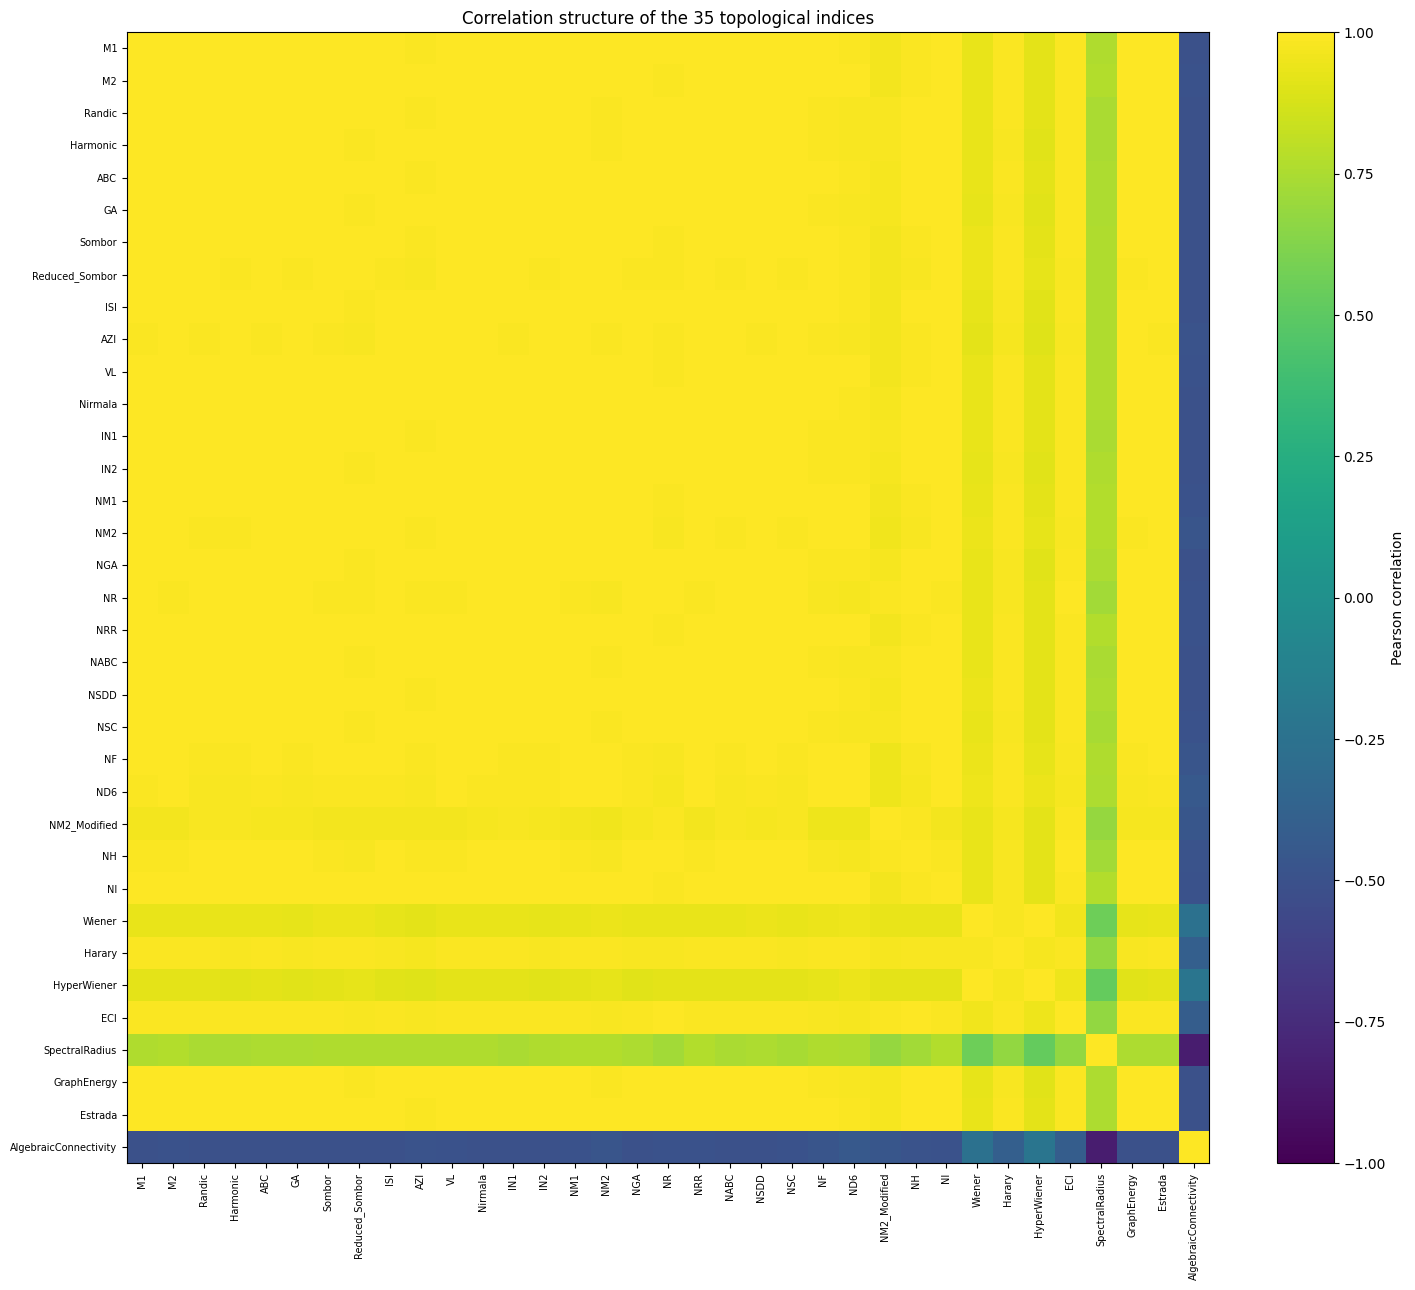

STEP 12 COMPLETED


In [ ]:
# ============================================================
# STEP 12 — TOPOLOGICAL REDUNDANCY AUDIT
# ============================================================

descriptor_matrix = analysis_df[
    ALL_35
].astype(float)

pearson_descriptor_corr = (
    descriptor_matrix.corr(
        method="pearson"
    )
)

spearman_descriptor_corr = (
    descriptor_matrix.corr(
        method="spearman"
    )
)


# ------------------------------------------------------------
# Extract unique descriptor pairs
# ------------------------------------------------------------

pair_rows = []

for i in range(len(ALL_35)):

    for j in range(i + 1, len(ALL_35)):

        a = ALL_35[i]
        b = ALL_35[j]

        pearson_r = (
            pearson_descriptor_corr.loc[
                a, b
            ]
        )

        spearman_rho = (
            spearman_descriptor_corr.loc[
                a, b
            ]
        )

        pair_rows.append({
            "Descriptor_1": a,
            "Descriptor_2": b,
            "Pearson_r": pearson_r,
            "Abs_Pearson_r": abs(pearson_r),
            "Spearman_rho": spearman_rho,
            "Abs_Spearman_rho":
                abs(spearman_rho)
        })


descriptor_pair_df = pd.DataFrame(
    pair_rows
)


total_pairs = len(
    descriptor_pair_df
)

high_pearson = int(
    (
        descriptor_pair_df[
            "Abs_Pearson_r"
        ]
        >= 0.95
    ).sum()
)

high_spearman = int(
    (
        descriptor_pair_df[
            "Abs_Spearman_rho"
        ]
        >= 0.95
    ).sum()
)


print(
    "Total unique descriptor pairs:",
    total_pairs
)

print(
    "Pairs with |Pearson r| >= 0.95:",
    high_pearson,
    f"({100*high_pearson/total_pairs:.1f}%)"
)

print(
    "Pairs with |Spearman rho| >= 0.95:",
    high_spearman,
    f"({100*high_spearman/total_pairs:.1f}%)"
)


print(
    "\n20 strongest Pearson-correlated "
    "descriptor pairs:"
)

display(
    descriptor_pair_df
    .sort_values(
        "Abs_Pearson_r",
        ascending=False
    )
    .head(20)
)


# ------------------------------------------------------------
# Numerical matrix rank
# ------------------------------------------------------------

raw_rank = np.linalg.matrix_rank(
    descriptor_matrix.to_numpy(
        dtype=float
    )
)

centered = (
    descriptor_matrix
    -
    descriptor_matrix.mean()
)

centered_rank = np.linalg.matrix_rank(
    centered.to_numpy(
        dtype=float
    )
)


print(
    "\nRaw descriptor-matrix rank:",
    raw_rank,
    "out of 35"
)

print(
    "Centered descriptor-matrix rank:",
    centered_rank,
    "out of 35"
)


# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

pearson_descriptor_corr.to_csv(
    OUTPUT_DIR
    /
    "descriptor_pearson_correlation_matrix.csv"
)

spearman_descriptor_corr.to_csv(
    OUTPUT_DIR
    /
    "descriptor_spearman_correlation_matrix.csv"
)

descriptor_pair_df.to_csv(
    OUTPUT_DIR
    /
    "descriptor_pairwise_redundancy.csv",
    index=False
)


# ------------------------------------------------------------
# Correlation heatmap
# ------------------------------------------------------------

plt.figure(
    figsize=(15, 13)
)

plt.imshow(
    pearson_descriptor_corr,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(
    label="Pearson correlation"
)

plt.xticks(
    range(len(ALL_35)),
    ALL_35,
    rotation=90,
    fontsize=7
)

plt.yticks(
    range(len(ALL_35)),
    ALL_35,
    fontsize=7
)

plt.title(
    "Correlation structure of the 35 "
    "topological indices"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR
    /
    "Figure_Topological_Correlation_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("STEP 12 COMPLETED")

In [ ]:
# ============================================================
# STEP 13 — INDIVIDUAL TOPOLOGICAL INDEX VS MELTING POINT
# ============================================================

y = analysis_df[
    "Experimental_MP_C"
].astype(float).to_numpy()

association_rows = []


for feature in ALL_35:

    x = analysis_df[
        feature
    ].astype(float).to_numpy()

    pearson_r, pearson_p = (
        stats.pearsonr(
            x,
            y
        )
    )

    spearman_rho, spearman_p = (
        stats.spearmanr(
            x,
            y
        )
    )

    association_rows.append({

        "Descriptor":
            feature,

        "Pearson_r":
            pearson_r,

        "Pearson_p":
            pearson_p,

        "Spearman_rho":
            spearman_rho,

        "Spearman_p":
            spearman_p
    })


association_df = pd.DataFrame(
    association_rows
)


# ------------------------------------------------------------
# Benjamini-Hochberg FDR correction
# ------------------------------------------------------------

association_df[
    "Pearson_FDR_q"
] = multipletests(
    association_df[
        "Pearson_p"
    ],
    method="fdr_bh"
)[1]


association_df[
    "Spearman_FDR_q"
] = multipletests(
    association_df[
        "Spearman_p"
    ],
    method="fdr_bh"
)[1]


association_df[
    "Pearson_FDR_Significant"
] = (
    association_df[
        "Pearson_FDR_q"
    ] < 0.05
)


association_df[
    "Spearman_FDR_Significant"
] = (
    association_df[
        "Spearman_FDR_q"
    ] < 0.05
)


association_df[
    "Abs_Pearson_r"
] = association_df[
    "Pearson_r"
].abs()


association_df[
    "Abs_Spearman_rho"
] = association_df[
    "Spearman_rho"
].abs()


print(
    "Top descriptors by absolute "
    "Pearson correlation:"
)

display(
    association_df
    .sort_values(
        "Abs_Pearson_r",
        ascending=False
    )
    .head(15)
)


print(
    "Number significant after "
    "Pearson FDR correction:",
    int(
        association_df[
            "Pearson_FDR_Significant"
        ].sum()
    ),
    "/ 35"
)

print(
    "Number significant after "
    "Spearman FDR correction:",
    int(
        association_df[
            "Spearman_FDR_Significant"
        ].sum()
    ),
    "/ 35"
)


association_df.to_csv(
    OUTPUT_DIR
    /
    "topological_index_melting_point_associations.csv",
    index=False
)

print("STEP 13 COMPLETED")

Top descriptors by absolute Pearson correlation:


,Descriptor,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,Pearson_FDR_q,Spearman_FDR_q,Pearson_FDR_Significant,Spearman_FDR_Significant,Abs_Pearson_r,Abs_Spearman_rho
34,AlgebraicConnectivity,-0.282226,0.308136,-0.446429,0.095293,0.654529,0.164993,False,False,0.282226,0.446429
31,SpectralRadius,0.235650,0.397835,0.139286,0.620546,0.654529,0.620546,False,False,0.235650,0.139286
5,GA,0.216213,0.438951,0.416443,0.122567,0.654529,0.164993,False,False,0.216213,0.416443
32,GraphEnergy,0.214583,0.442494,0.446429,0.095293,0.654529,0.164993,False,False,0.214583,0.446429
16,NGA,0.212372,0.447321,0.416443,0.122567,0.654529,0.164993,False,False,0.212372,0.416443
9,AZI,0.211325,0.449617,0.427167,0.112263,0.654529,0.164993,False,False,0.211325,0.427167
21,NSC,0.211235,0.449815,0.427167,0.112263,0.654529,0.164993,False,False,0.211235,0.427167
25,NH,0.210849,0.450661,0.427167,0.112263,0.654529,0.164993,False,False,0.210849,0.427167
3,Harmonic,0.210249,0.451982,0.427167,0.112263,0.654529,0.164993,False,False,0.210249,0.427167
13,IN2,0.210153,0.452194,0.423593,0.115629,0.654529,0.164993,False,False,0.210153,0.423593


Number significant after Pearson FDR correction: 0 / 35
Number significant after Spearman FDR correction: 0 / 35
STEP 13 COMPLETED


In [ ]:
# ============================================================
# STEP 14 — MOLECULAR GRAPH DISCRIMINATION ANALYSIS
# ============================================================

def vectors_equal(
    vector_a,
    vector_b,
    rtol=1e-10,
    atol=1e-10
):

    return np.allclose(
        np.asarray(
            vector_a,
            dtype=float
        ),
        np.asarray(
            vector_b,
            dtype=float
        ),
        rtol=rtol,
        atol=atol
    )


def discrimination_analysis(
    df,
    feature_columns,
    label
):

    indistinguishable_pairs = []

    all_pairs = list(
        combinations(
            range(len(df)),
            2
        )
    )

    for i, j in all_pairs:

        a = df.iloc[i]
        b = df.iloc[j]

        a_vector = a[
            feature_columns
        ].to_numpy(dtype=float)

        b_vector = b[
            feature_columns
        ].to_numpy(dtype=float)

        if vectors_equal(
            a_vector,
            b_vector
        ):

            indistinguishable_pairs.append(
                (
                    a["Compound"],
                    b["Compound"]
                )
            )

    total = len(
        all_pairs
    )

    collisions = len(
        indistinguishable_pairs
    )

    discrimination = (
        1.0
        -
        collisions / total
    )

    return {

        "Feature_Set":
            label,

        "Number_of_Descriptors":
            len(feature_columns),

        "Total_Molecule_Pairs":
            total,

        "Indistinguishable_Pairs":
            collisions,

        "Distinguished_Pairs":
            total - collisions,

        "Discrimination_Efficiency":
            discrimination,

        "Discrimination_Percent":
            100 * discrimination,

        "Indistinguishable_Pair_Names":
            str(
                indistinguishable_pairs
            )
    }


discrimination_rows = []


for name, features in (
    FEATURE_SETS.items()
):

    discrimination_rows.append(
        discrimination_analysis(
            analysis_df,
            features,
            name
        )
    )


family_discrimination_df = (
    pd.DataFrame(
        discrimination_rows
    )
)


display(
    family_discrimination_df[
        [
            "Feature_Set",
            "Number_of_Descriptors",
            "Indistinguishable_Pairs",
            "Distinguished_Pairs",
            "Discrimination_Percent"
        ]
    ]
)


family_discrimination_df.to_csv(
    OUTPUT_DIR
    /
    "family_discrimination_summary.csv",
    index=False
)


# ------------------------------------------------------------
# Show any unresolved molecule pairs
# ------------------------------------------------------------

print(
    "\nIndistinguishable pairs by family:"
)

for _, row in (
    family_discrimination_df.iterrows()
):

    print(
        "\n",
        row["Feature_Set"],
        ":",
        row[
            "Indistinguishable_Pair_Names"
        ]
    )


print("STEP 14 COMPLETED")

,Feature_Set,Number_of_Descriptors,Indistinguishable_Pairs,Distinguished_Pairs,Discrimination_Percent
0,Degree_14,14,1,104,99.047619
1,Article_Core_Neighborhood_8,8,1,104,99.047619
2,Expanded_Neighborhood_13,13,1,104,99.047619
3,Distance_4,4,0,105,100.000000
4,Spectral_4,4,0,105,100.000000
5,Legacy_28,28,0,105,100.000000
6,Extended_35,35,0,105,100.000000
7,Algebraic_Pruned_33,33,0,105,100.000000



Indistinguishable pairs by family:

 Degree_14 : [('Levamisole', 'Thiabendazole')]

 Article_Core_Neighborhood_8 : [('Levamisole', 'Thiabendazole')]

 Expanded_Neighborhood_13 : [('Levamisole', 'Thiabendazole')]

 Distance_4 : []

 Spectral_4 : []

 Legacy_28 : []

 Extended_35 : []

 Algebraic_Pruned_33 : []
STEP 14 COMPLETED


,Principal_Component,Explained_Variance_Ratio,Explained_Variance_Percent,Cumulative_Variance_Percent
0,PC1,0.949510,94.950976,94.950976
1,PC2,0.038559,3.855871,98.806847
2,PC3,0.005653,0.565314,99.372161
3,PC4,0.003912,0.391206,99.763367
4,PC5,0.001465,0.146538,99.909905
5,PC6,0.000670,0.066978,99.976883
6,PC7,0.000129,0.012878,99.989761
7,PC8,0.000086,0.008599,99.998361
8,PC9,0.000009,0.000926,99.999287
9,PC10,0.000004,0.000381,99.999668


PC1 explained variance: 94.95%
PC1 + PC2 explained variance: 98.81%
PC1 + PC2 + PC3 explained variance: 99.37%

Largest absolute PC1 loadings:


,Descriptor,PC1_Loading,PC2_Loading,PC3_Loading,Abs_PC1
10,Nirmala,0.178557,-0.005138,-0.009026,0.178557
31,Estrada,0.178553,-0.002072,-0.045137,0.178553
0,M1,0.178534,-0.004975,0.033315,0.178534
4,ABC,0.178507,-0.002329,-0.047954,0.178507
11,IN1,0.178502,-0.000813,-0.074173,0.178502
18,NSDD,0.178480,-0.005196,-0.007848,0.178480
6,Sombor,0.178450,-0.003341,0.043841,0.178450
17,NABC,0.178445,-0.000376,-0.100321,0.178445
14,NGA,0.178430,-0.003968,-0.059143,0.178430
2,Randic,0.178406,0.001327,-0.112663,0.178406


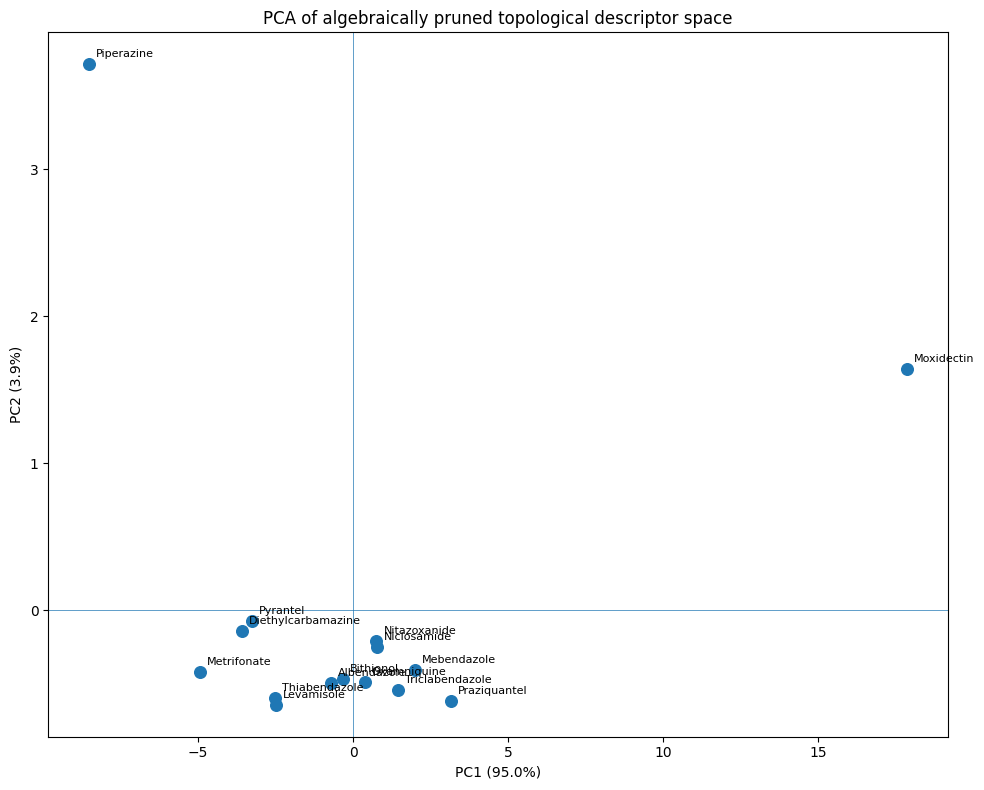

STEP 15 COMPLETED


In [ ]:
# ============================================================
# STEP 15 — PCA OF PURE TOPOLOGICAL DESCRIPTOR SPACE
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


X_pca_raw = analysis_df[
    ALGEBRAIC_PRUNED_33
].astype(float)


scaler_pca = StandardScaler()

X_pca_scaled = (
    scaler_pca.fit_transform(
        X_pca_raw
    )
)


pca = PCA()

X_scores = pca.fit_transform(
    X_pca_scaled
)


explained_variance = (
    pca.explained_variance_ratio_
)


cumulative_variance = (
    np.cumsum(
        explained_variance
    )
)


pca_variance_df = pd.DataFrame({

    "Principal_Component":
        [
            f"PC{i+1}"
            for i in range(
                len(
                    explained_variance
                )
            )
        ],

    "Explained_Variance_Ratio":
        explained_variance,

    "Explained_Variance_Percent":
        100 * explained_variance,

    "Cumulative_Variance_Percent":
        100 * cumulative_variance
})


display(
    pca_variance_df.head(10)
)


print(
    "PC1 explained variance:",
    f"{100*explained_variance[0]:.2f}%"
)

print(
    "PC1 + PC2 explained variance:",
    f"{100*cumulative_variance[1]:.2f}%"
)

print(
    "PC1 + PC2 + PC3 explained variance:",
    f"{100*cumulative_variance[2]:.2f}%"
)


# ------------------------------------------------------------
# PCA scores
# ------------------------------------------------------------

pca_scores_df = pd.DataFrame({

    "Compound":
        analysis_df[
            "Compound"
        ],

    "Experimental_MP_C":
        analysis_df[
            "Experimental_MP_C"
        ],

    "PC1":
        X_scores[:,0],

    "PC2":
        X_scores[:,1],

    "PC3":
        X_scores[:,2]
})


# ------------------------------------------------------------
# PCA loadings
# ------------------------------------------------------------

pca_loadings_df = pd.DataFrame(

    pca.components_[:3].T,

    index=ALGEBRAIC_PRUNED_33,

    columns=[
        "PC1_Loading",
        "PC2_Loading",
        "PC3_Loading"
    ]
).reset_index(
    names="Descriptor"
)


print(
    "\nLargest absolute PC1 loadings:"
)

display(
    pca_loadings_df.assign(
        Abs_PC1=lambda x:
            x[
                "PC1_Loading"
            ].abs()
    )
    .sort_values(
        "Abs_PC1",
        ascending=False
    )
    .head(15)
)


# ------------------------------------------------------------
# PCA plot
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 8)
)

plt.scatter(
    pca_scores_df["PC1"],
    pca_scores_df["PC2"],
    s=70
)

for _, row in (
    pca_scores_df.iterrows()
):

    plt.annotate(
        row["Compound"],
        (
            row["PC1"],
            row["PC2"]
        ),
        xytext=(5,5),
        textcoords="offset points",
        fontsize=8
    )


plt.xlabel(
    f"PC1 "
    f"({100*explained_variance[0]:.1f}%)"
)

plt.ylabel(
    f"PC2 "
    f"({100*explained_variance[1]:.1f}%)"
)

plt.title(
    "PCA of algebraically pruned "
    "topological descriptor space"
)

plt.axhline(
    0,
    linewidth=0.5
)

plt.axvline(
    0,
    linewidth=0.5
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR
    /
    "Figure_Topological_PCA_PC1_PC2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


pca_variance_df.to_csv(
    OUTPUT_DIR
    /
    "pca_explained_variance.csv",
    index=False
)

pca_scores_df.to_csv(
    OUTPUT_DIR
    /
    "pca_compound_scores.csv",
    index=False
)

pca_loadings_df.to_csv(
    OUTPUT_DIR
    /
    "pca_descriptor_loadings.csv",
    index=False
)

print("STEP 15 COMPLETED")

In [ ]:
# ============================================================
# STEP 16 — FULL GRAPH SPECTRA AND COSPECTRALITY
# ============================================================

def graph_spectra(G):

    nodes = list(
        G.nodes()
    )

    A = nx.to_numpy_array(
        G,
        nodelist=nodes,
        dtype=float
    )

    adjacency_spectrum = np.sort(
        np.linalg.eigvalsh(A)
    )


    L = (
        nx.laplacian_matrix(
            G,
            nodelist=nodes
        )
        .toarray()
        .astype(float)
    )

    laplacian_spectrum = np.sort(
        np.linalg.eigvalsh(L)
    )

    return (
        adjacency_spectrum,
        laplacian_spectrum
    )


FULL_SPECTRA = {}


for compound in (
    analysis_df["Compound"]
):

    adj_spec, lap_spec = (
        graph_spectra(
            GRAPHS[compound]
        )
    )

    FULL_SPECTRA[
        compound
    ] = {

        "Adjacency":
            adj_spec,

        "Laplacian":
            lap_spec
    }


# ------------------------------------------------------------
# Pairwise cospectrality check
# ------------------------------------------------------------

cospectral_rows = []


for compound_a, compound_b in (
    combinations(
        analysis_df[
            "Compound"
        ],
        2
    )
):

    G_a = GRAPHS[
        compound_a
    ]

    G_b = GRAPHS[
        compound_b
    ]


    same_order = (
        G_a.number_of_nodes()
        ==
        G_b.number_of_nodes()
    )


    adjacency_cospectral = False
    laplacian_cospectral = False


    if same_order:

        spec_a = FULL_SPECTRA[
            compound_a
        ]

        spec_b = FULL_SPECTRA[
            compound_b
        ]


        adjacency_cospectral = (
            np.allclose(
                spec_a["Adjacency"],
                spec_b["Adjacency"],
                rtol=1e-9,
                atol=1e-9
            )
        )


        laplacian_cospectral = (
            np.allclose(
                spec_a["Laplacian"],
                spec_b["Laplacian"],
                rtol=1e-9,
                atol=1e-9
            )
        )


    cospectral_rows.append({

        "Compound_A":
            compound_a,

        "Compound_B":
            compound_b,

        "Same_Number_of_Vertices":
            same_order,

        "Adjacency_Cospectral":
            adjacency_cospectral,

        "Laplacian_Cospectral":
            laplacian_cospectral
    })


cospectrality_df = pd.DataFrame(
    cospectral_rows
)


print(
    "Adjacency-cospectral molecule pairs:",
    int(
        cospectrality_df[
            "Adjacency_Cospectral"
        ].sum()
    )
)

print(
    "Laplacian-cospectral molecule pairs:",
    int(
        cospectrality_df[
            "Laplacian_Cospectral"
        ].sum()
    )
)


# ------------------------------------------------------------
# Special Levamisole–Thiabendazole comparison
# ------------------------------------------------------------

comparison_features = [

    "Experimental_MP_C",

    "M1",
    "M2",
    "VL",

    "NM1",
    "NM2",
    "NF",
    "ND6",

    "Wiener",
    "Harary",
    "HyperWiener",
    "ECI",

    "SpectralRadius",
    "GraphEnergy",
    "Estrada",
    "AlgebraicConnectivity"
]


lev_thia_comparison = (

    analysis_df[
        analysis_df[
            "Compound"
        ].isin(
            [
                "Levamisole",
                "Thiabendazole"
            ]
        )
    ][
        ["Compound"]
        +
        comparison_features
    ]

    .set_index(
        "Compound"
    )

    .T
)


print(
    "\nLevamisole versus Thiabendazole:"
)

display(
    lev_thia_comparison
)


cospectrality_df.to_csv(
    OUTPUT_DIR
    /
    "full_graph_cospectrality_analysis.csv",
    index=False
)

lev_thia_comparison.to_csv(
    OUTPUT_DIR
    /
    "Levamisole_Thiabendazole_topology_comparison.csv"
)


# ------------------------------------------------------------
# CHECKPOINT SUMMARY
# ------------------------------------------------------------

print()
print("========================================")
print("CHECKPOINT 2 SUCCESSFULLY COMPLETED")
print("========================================")

print(
    "High Pearson redundancy pairs:",
    high_pearson,
    "/",
    total_pairs
)

print(
    "Pearson FDR-significant TIs:",
    int(
        association_df[
            "Pearson_FDR_Significant"
        ].sum()
    ),
    "/ 35"
)

print(
    "Spearman FDR-significant TIs:",
    int(
        association_df[
            "Spearman_FDR_Significant"
        ].sum()
    ),
    "/ 35"
)

print(
    "PC1 explained variance:",
    f"{100*explained_variance[0]:.2f}%"
)

print(
    "PC1+PC2 explained variance:",
    f"{100*cumulative_variance[1]:.2f}%"
)

print(
    "Adjacency-cospectral pairs:",
    int(
        cospectrality_df[
            "Adjacency_Cospectral"
        ].sum()
    )
)

print(
    "Laplacian-cospectral pairs:",
    int(
        cospectrality_df[
            "Laplacian_Cospectral"
        ].sum()
    )
)

print()
print(
    "Family discrimination summary:"
)

display(
    family_discrimination_df[
        [
            "Feature_Set",
            "Indistinguishable_Pairs",
            "Discrimination_Percent"
        ]
    ]
)

print(
    "\nCheckpoint 2 outputs saved in:",
    OUTPUT_DIR
)

Adjacency-cospectral molecule pairs: 0
Laplacian-cospectral molecule pairs: 0

Levamisole versus Thiabendazole:


Compound,Levamisole,Thiabendazole
Experimental_MP_C,61.000000,302.220000
M1,76.000000,76.000000
M2,90.000000,90.000000
VL,83.000000,83.000000
NM1,180.000000,180.000000
NM2,518.000000,518.000000
NF,1060.000000,1060.000000
ND6,6212.000000,6212.000000
Wiener,298.000000,293.000000
Harary,39.896429,40.071429



CHECKPOINT 2 SUCCESSFULLY COMPLETED
High Pearson redundancy pairs: 469 / 595
Pearson FDR-significant TIs: 0 / 35
Spearman FDR-significant TIs: 0 / 35
PC1 explained variance: 94.95%
PC1+PC2 explained variance: 98.81%
Adjacency-cospectral pairs: 0
Laplacian-cospectral pairs: 0

Family discrimination summary:


,Feature_Set,Indistinguishable_Pairs,Discrimination_Percent
0,Degree_14,1,99.047619
1,Article_Core_Neighborhood_8,1,99.047619
2,Expanded_Neighborhood_13,1,99.047619
3,Distance_4,0,100.000000
4,Spectral_4,0,100.000000
5,Legacy_28,0,100.000000
6,Extended_35,0,100.000000
7,Algebraic_Pruned_33,0,100.000000



Checkpoint 2 outputs saved in: /content/topology_qspr_results


In [ ]:
# ============================================================
# STEP 17 — POLYNOMIAL QSPR + LOOCV FUNCTIONS
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score


def rmse_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    return float(
        np.sqrt(
            np.mean(
                (y_true - y_pred) ** 2
            )
        )
    )


def mae_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    return float(
        np.mean(
            np.abs(
                y_true - y_pred
            )
        )
    )


def q2_score(y_true, y_pred):
    """
    Cross-validated Q²:
    Q² = 1 - PRESS / TSS
    """

    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    press = np.sum(
        (y_true - y_pred) ** 2
    )

    tss = np.sum(
        (y_true - np.mean(y_true)) ** 2
    )

    if tss <= 0:
        return np.nan

    return float(
        1.0 - press / tss
    )


def safe_prediction_correlation(
    y_true,
    y_pred
):
    y_true = np.asarray(
        y_true,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )

    if (
        np.std(y_true) <= 1e-12
        or
        np.std(y_pred) <= 1e-12
    ):
        return np.nan

    return float(
        stats.pearsonr(
            y_true,
            y_pred
        )[0]
    )


def build_polynomial_pipeline(
    degree
):
    """
    Scaling is performed inside the CV pipeline.
    PolynomialFeatures then creates x, x², x³ as required.
    """

    return Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "poly",
            PolynomialFeatures(
                degree=degree,
                include_bias=False
            )
        ),
        (
            "regression",
            LinearRegression()
        )
    ])


print("STEP 17 COMPLETED")
print("Polynomial QSPR functions are ready.")

STEP 17 COMPLETED
Polynomial QSPR functions are ready.


In [ ]:
# ============================================================
# STEP 18 — ARTICLE-CORE POLYNOMIAL QSPR
# ============================================================

ARTICLE_LABELS = {

    "NM1":
        "Neighborhood First Zagreb (NM1)",

    "NM2":
        "Neighborhood Second Zagreb (NM2)",

    "NF":
        "Neighborhood Forgotten (FN)",

    "NM2_Modified":
        "Neighborhood Second Modified Zagreb (M2mm)",

    "ND6":
        "Article ND3 / Neighborhood Redefined Third Zagreb",

    "NSDD":
        "Article ND5 / Neighborhood Sum Degree Division",

    "NH":
        "Neighborhood Harmonic (NH)",

    "NI":
        "Neighborhood Inverse Sum (NI)"
}


y_mp = analysis_df[
    "Experimental_MP_C"
].astype(float).to_numpy()


loo = LeaveOneOut()

polynomial_results = []
polynomial_prediction_rows = []


for feature in ARTICLE_CORE_8:

    X = analysis_df[
        [feature]
    ].astype(float).to_numpy()

    for degree in [1, 2, 3]:

        model = (
            build_polynomial_pipeline(
                degree
            )
        )

        # ----------------------------------------------------
        # In-sample fitted model
        # ----------------------------------------------------

        model.fit(
            X,
            y_mp
        )

        fitted_predictions = (
            model.predict(X)
        )

        fitted_r2 = float(
            r2_score(
                y_mp,
                fitted_predictions
            )
        )

        fitted_rmse = rmse_score(
            y_mp,
            fitted_predictions
        )


        # ----------------------------------------------------
        # Genuine Leave-One-Out predictions
        # ----------------------------------------------------

        loo_predictions = (
            cross_val_predict(
                model,
                X,
                y_mp,
                cv=loo,
                method="predict"
            )
        )


        loo_q2 = q2_score(
            y_mp,
            loo_predictions
        )

        loo_rmse = rmse_score(
            y_mp,
            loo_predictions
        )

        loo_mae = mae_score(
            y_mp,
            loo_predictions
        )

        prediction_r = (
            safe_prediction_correlation(
                y_mp,
                loo_predictions
            )
        )


        polynomial_results.append({

            "Descriptor":
                feature,

            "Descriptor_Name":
                ARTICLE_LABELS[
                    feature
                ],

            "Polynomial_Degree":
                degree,

            "Model_Type":
                {
                    1: "Linear",
                    2: "Quadratic",
                    3: "Cubic"
                }[degree],

            "Fit_R2":
                fitted_r2,

            "Fit_RMSE":
                fitted_rmse,

            "LOOCV_Q2":
                loo_q2,

            "LOOCV_RMSE":
                loo_rmse,

            "LOOCV_MAE":
                loo_mae,

            "LOOCV_Prediction_r":
                prediction_r,

            "Optimism_Gap_R2_minus_Q2":
                fitted_r2
                -
                loo_q2
        })


        # ----------------------------------------------------
        # Save compound-level predictions
        # ----------------------------------------------------

        for compound, actual, predicted in zip(
            analysis_df["Compound"],
            y_mp,
            loo_predictions
        ):

            polynomial_prediction_rows.append({

                "Descriptor":
                    feature,

                "Descriptor_Name":
                    ARTICLE_LABELS[
                        feature
                    ],

                "Polynomial_Degree":
                    degree,

                "Model_Type":
                    {
                        1: "Linear",
                        2: "Quadratic",
                        3: "Cubic"
                    }[degree],

                "Compound":
                    compound,

                "Experimental_MP_C":
                    actual,

                "LOOCV_Predicted_MP_C":
                    predicted,

                "Residual":
                    actual
                    -
                    predicted,

                "Absolute_Error":
                    abs(
                        actual
                        -
                        predicted
                    )
            })


polynomial_results_df = pd.DataFrame(
    polynomial_results
)


polynomial_predictions_df = pd.DataFrame(
    polynomial_prediction_rows
)


polynomial_results_df.to_csv(
    OUTPUT_DIR
    /
    "article_core_polynomial_qspr_results.csv",
    index=False
)


polynomial_predictions_df.to_csv(
    OUTPUT_DIR
    /
    "article_core_polynomial_loocv_predictions.csv",
    index=False
)


print(
    "Models evaluated:",
    len(polynomial_results_df)
)

print(
    "Expected:",
    8 * 3
)

assert len(
    polynomial_results_df
) == 24


print("STEP 18 COMPLETED")

Models evaluated: 24
Expected: 24
STEP 18 COMPLETED


In [ ]:
# ============================================================
# STEP 19 — FIT QUALITY VS PREDICTIVE QUALITY
# ============================================================

print(
    "All polynomial models ranked by LOOCV Q²:"
)

display(
    polynomial_results_df[
        [
            "Descriptor",
            "Model_Type",
            "Fit_R2",
            "LOOCV_Q2",
            "LOOCV_RMSE",
            "LOOCV_MAE",
            "LOOCV_Prediction_r",
            "Optimism_Gap_R2_minus_Q2"
        ]
    ]
    .sort_values(
        "LOOCV_Q2",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Summary by polynomial degree
# ------------------------------------------------------------

degree_summary_df = (

    polynomial_results_df

    .groupby(
        [
            "Polynomial_Degree",
            "Model_Type"
        ],
        as_index=False
    )

    .agg(

        Mean_Fit_R2=(
            "Fit_R2",
            "mean"
        ),

        Mean_LOOCV_Q2=(
            "LOOCV_Q2",
            "mean"
        ),

        Median_LOOCV_Q2=(
            "LOOCV_Q2",
            "median"
        ),

        Best_LOOCV_Q2=(
            "LOOCV_Q2",
            "max"
        ),

        Mean_LOOCV_RMSE=(
            "LOOCV_RMSE",
            "mean"
        ),

        Mean_LOOCV_MAE=(
            "LOOCV_MAE",
            "mean"
        ),

        Mean_Optimism_Gap=(
            "Optimism_Gap_R2_minus_Q2",
            "mean"
        )
    )
)


positive_q2_counts = (

    polynomial_results_df

    .assign(
        Positive_Q2=lambda x:
            x[
                "LOOCV_Q2"
            ] > 0
    )

    .groupby(
        [
            "Polynomial_Degree",
            "Model_Type"
        ]
    )[
        "Positive_Q2"
    ]

    .sum()

    .reset_index(
        name="Models_With_Positive_Q2"
    )
)


degree_summary_df = (
    degree_summary_df.merge(
        positive_q2_counts,
        on=[
            "Polynomial_Degree",
            "Model_Type"
        ],
        how="left"
    )
)


print(
    "\nSummary by polynomial degree:"
)

display(
    degree_summary_df
)


degree_summary_df.to_csv(
    OUTPUT_DIR
    /
    "polynomial_degree_summary.csv",
    index=False
)


# ------------------------------------------------------------
# Best model according to genuine prediction
# ------------------------------------------------------------

best_polynomial_row = (

    polynomial_results_df

    .sort_values(
        "LOOCV_Q2",
        ascending=False
    )

    .iloc[0]
)


print()
print(
    "BEST POLYNOMIAL MODEL BY LOOCV Q²"
)

print(
    "Descriptor:",
    best_polynomial_row[
        "Descriptor"
    ]
)

print(
    "Descriptor name:",
    best_polynomial_row[
        "Descriptor_Name"
    ]
)

print(
    "Model:",
    best_polynomial_row[
        "Model_Type"
    ]
)

print(
    "Fit R²:",
    round(
        best_polynomial_row[
            "Fit_R2"
        ],
        4
    )
)

print(
    "LOOCV Q²:",
    round(
        best_polynomial_row[
            "LOOCV_Q2"
        ],
        4
    )
)

print(
    "LOOCV RMSE:",
    round(
        best_polynomial_row[
            "LOOCV_RMSE"
        ],
        2
    ),
    "°C"
)

print(
    "LOOCV MAE:",
    round(
        best_polynomial_row[
            "LOOCV_MAE"
        ],
        2
    ),
    "°C"
)

print("STEP 19 COMPLETED")

All polynomial models ranked by LOOCV Q²:


,Descriptor,Model_Type,Fit_R2,LOOCV_Q2,LOOCV_RMSE,LOOCV_MAE,LOOCV_Prediction_r,Optimism_Gap_R2_minus_Q2
0,NM1,Quadratic,0.227726,-0.065527,74.747343,61.800336,0.285112,0.293253
1,NI,Quadratic,0.240867,-0.082453,75.338700,62.854098,0.295314,0.323320
2,NH,Quadratic,0.246501,-0.265140,81.448441,64.061130,0.194488,0.511641
3,NSDD,Quadratic,0.207028,-0.357425,84.366767,68.894417,0.159556,0.564453
4,NF,Quadratic,0.194115,-0.360036,84.447861,70.568448,0.210637,0.554150
5,NM2,Quadratic,0.215367,-0.487660,88.321285,72.253377,0.218816,0.703027
6,NM2_Modified,Linear,0.030794,-0.749821,95.787829,76.263941,-0.151456,0.780615
7,NSDD,Linear,0.033210,-0.780156,96.614553,76.556254,-0.136476,0.813365
8,NF,Linear,0.021931,-0.785453,96.758204,77.248983,-0.150412,0.807385
9,NM1,Linear,0.034687,-0.787355,96.809725,76.746865,-0.131206,0.822042



Summary by polynomial degree:


,Polynomial_Degree,Model_Type,Mean_Fit_R2,Mean_LOOCV_Q2,Median_LOOCV_Q2,Best_LOOCV_Q2,Mean_LOOCV_RMSE,Mean_LOOCV_MAE,Mean_Optimism_Gap,Models_With_Positive_Q2
0,1,Linear,0.030715,-0.793763,-0.788940,-0.749821,96.980938,76.927814,0.824477,0
1,2,Quadratic,0.213128,-0.601963,-0.358730,-0.065527,90.262133,70.137865,0.815090,0
2,3,Cubic,0.216784,-394.056306,-369.834101,-153.973659,1417.976533,443.885063,394.273090,0



BEST POLYNOMIAL MODEL BY LOOCV Q²
Descriptor: NM1
Descriptor name: Neighborhood First Zagreb (NM1)
Model: Quadratic
Fit R²: 0.2277
LOOCV Q²: -0.0655
LOOCV RMSE: 74.75 °C
LOOCV MAE: 61.8 °C
STEP 19 COMPLETED


,Descriptor,Quadratic_Fit_R2,Cubic_Fit_R2,Quadratic_LOOCV_Q2,Cubic_LOOCV_Q2,Quadratic_LOOCV_RMSE,Cubic_LOOCV_RMSE,Cubic_minus_Quadratic_Fit_R2,Cubic_minus_Quadratic_Q2,Cubic_minus_Quadratic_RMSE
0,NM1,0.227726,0.230105,-0.065527,-380.872566,74.747343,1415.053165,2.379017e-03,-380.807039,1340.305821
1,NM2,0.215367,0.215367,-0.487660,-446.265405,88.321285,1531.426581,1.941262e-07,-445.777745,1443.105296
2,NF,0.194115,0.194220,-0.360036,-500.470099,84.447861,1621.571298,1.051375e-04,-500.110064,1537.123437
3,NM2_Modified,0.187257,0.193319,-1.503009,-341.519095,114.563088,1340.157747,6.061805e-03,-340.016086,1225.594659
4,ND6,0.186160,0.189186,-1.694453,-623.335894,118.863583,1809.350393,3.025586e-03,-621.641441,1690.486810
5,NSDD,0.207028,0.217406,-0.357425,-358.795637,84.366767,1373.540512,1.037838e-02,-358.438212,1289.173745
6,NH,0.246501,0.252260,-0.265140,-153.973659,81.448441,901.451718,5.758740e-03,-153.708519,820.003277
7,NI,0.240867,0.242413,-0.082453,-347.218093,75.338700,1351.260847,1.545706e-03,-347.135639,1275.922147


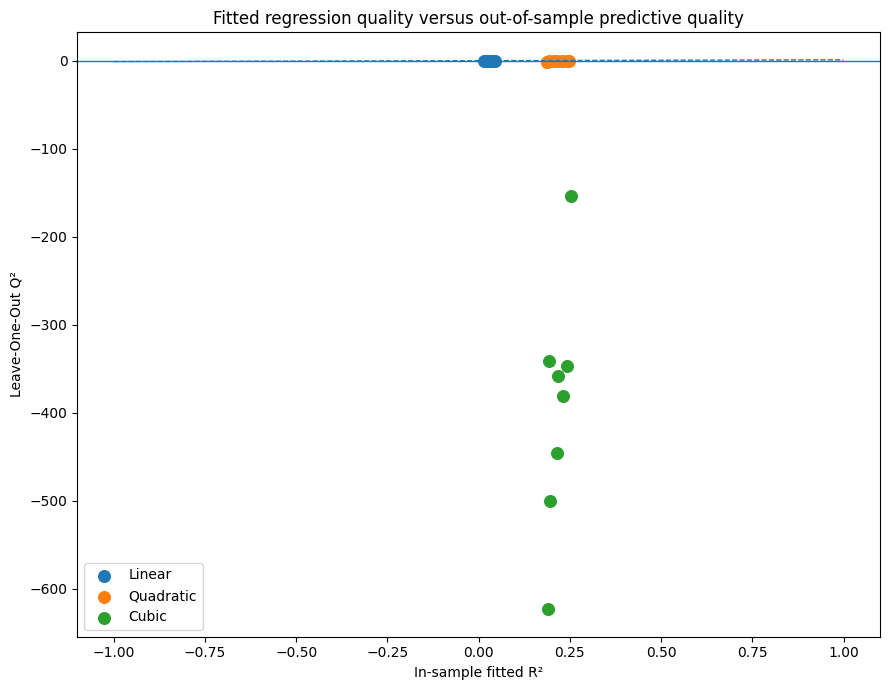


CHECKPOINT 3 SUCCESSFULLY COMPLETED
Polynomial models evaluated: 24
Models with positive LOOCV Q²: 0 / 24
Best descriptor: NM1
Best polynomial form: Quadratic
Best fitted R²: 0.2277
Best LOOCV Q²: -0.0655
Best LOOCV RMSE: 74.75 °C
Best LOOCV MAE: 61.80 °C

Polynomial-degree summary:


,Model_Type,Mean_Fit_R2,Mean_LOOCV_Q2,Best_LOOCV_Q2,Mean_LOOCV_RMSE,Models_With_Positive_Q2
0,Linear,0.030715,-0.793763,-0.749821,96.980938,0
1,Quadratic,0.213128,-0.601963,-0.065527,90.262133,0
2,Cubic,0.216784,-394.056306,-153.973659,1417.976533,0



Results saved in: /content/topology_qspr_results


In [ ]:
# ============================================================
# STEP 20 — QUADRATIC VS CUBIC COMPARISON
# ============================================================

quadratic_df = (

    polynomial_results_df[
        polynomial_results_df[
            "Polynomial_Degree"
        ] == 2
    ]

    .set_index(
        "Descriptor"
    )
)


cubic_df = (

    polynomial_results_df[
        polynomial_results_df[
            "Polynomial_Degree"
        ] == 3
    ]

    .set_index(
        "Descriptor"
    )
)


comparison_rows = []


for descriptor in ARTICLE_CORE_8:

    q = quadratic_df.loc[
        descriptor
    ]

    c = cubic_df.loc[
        descriptor
    ]

    comparison_rows.append({

        "Descriptor":
            descriptor,

        "Quadratic_Fit_R2":
            q["Fit_R2"],

        "Cubic_Fit_R2":
            c["Fit_R2"],

        "Quadratic_LOOCV_Q2":
            q["LOOCV_Q2"],

        "Cubic_LOOCV_Q2":
            c["LOOCV_Q2"],

        "Quadratic_LOOCV_RMSE":
            q["LOOCV_RMSE"],

        "Cubic_LOOCV_RMSE":
            c["LOOCV_RMSE"],

        "Cubic_minus_Quadratic_Fit_R2":
            c["Fit_R2"]
            -
            q["Fit_R2"],

        "Cubic_minus_Quadratic_Q2":
            c["LOOCV_Q2"]
            -
            q["LOOCV_Q2"],

        "Cubic_minus_Quadratic_RMSE":
            c["LOOCV_RMSE"]
            -
            q["LOOCV_RMSE"]
    })


quad_cubic_comparison_df = (
    pd.DataFrame(
        comparison_rows
    )
)


display(
    quad_cubic_comparison_df
)


quad_cubic_comparison_df.to_csv(
    OUTPUT_DIR
    /
    "quadratic_vs_cubic_comparison.csv",
    index=False
)


# ------------------------------------------------------------
# Plot fitted R² versus predictive Q²
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 7)
)


for degree, label in [
    (1, "Linear"),
    (2, "Quadratic"),
    (3, "Cubic")
]:

    subset = (
        polynomial_results_df[
            polynomial_results_df[
                "Polynomial_Degree"
            ] == degree
        ]
    )

    plt.scatter(
        subset["Fit_R2"],
        subset["LOOCV_Q2"],
        label=label,
        s=70
    )


plt.axhline(
    0,
    linewidth=1
)

plt.plot(
    [-1, 1],
    [-1, 1],
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "In-sample fitted R²"
)

plt.ylabel(
    "Leave-One-Out Q²"
)

plt.title(
    "Fitted regression quality versus "
    "out-of-sample predictive quality"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR
    /
    "Figure_Fit_R2_vs_LOOCV_Q2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# CHECKPOINT 3 SUMMARY
# ------------------------------------------------------------

best_row = (

    polynomial_results_df

    .sort_values(
        "LOOCV_Q2",
        ascending=False
    )

    .iloc[0]
)


positive_total = int(
    (
        polynomial_results_df[
            "LOOCV_Q2"
        ] > 0
    ).sum()
)


print()
print("========================================")
print("CHECKPOINT 3 SUCCESSFULLY COMPLETED")
print("========================================")

print(
    "Polynomial models evaluated:",
    len(
        polynomial_results_df
    )
)

print(
    "Models with positive LOOCV Q²:",
    positive_total,
    "/",
    len(
        polynomial_results_df
    )
)

print(
    "Best descriptor:",
    best_row[
        "Descriptor"
    ]
)

print(
    "Best polynomial form:",
    best_row[
        "Model_Type"
    ]
)

print(
    "Best fitted R²:",
    f"{best_row['Fit_R2']:.4f}"
)

print(
    "Best LOOCV Q²:",
    f"{best_row['LOOCV_Q2']:.4f}"
)

print(
    "Best LOOCV RMSE:",
    f"{best_row['LOOCV_RMSE']:.2f} °C"
)

print(
    "Best LOOCV MAE:",
    f"{best_row['LOOCV_MAE']:.2f} °C"
)


print(
    "\nPolynomial-degree summary:"
)

display(
    degree_summary_df[
        [
            "Model_Type",
            "Mean_Fit_R2",
            "Mean_LOOCV_Q2",
            "Best_LOOCV_Q2",
            "Mean_LOOCV_RMSE",
            "Models_With_Positive_Q2"
        ]
    ]
)


print(
    "\nResults saved in:",
    OUTPUT_DIR
)

In [ ]:
# ============================================================
# STEP 21 — MACHINE-LEARNING IMPORTS AND ROBUST METRICS
# ============================================================

from sklearn.model_selection import (
    KFold,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import Ridge
from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer


# ------------------------------------------------------------
# Redefine metrics defensively so both (n,) and (n,1)
# prediction arrays are handled correctly.
# ------------------------------------------------------------

def _as_1d(x):
    return np.asarray(
        x,
        dtype=float
    ).reshape(-1)


def rmse_score(y_true, y_pred):

    y_true = _as_1d(y_true)
    y_pred = _as_1d(y_pred)

    return float(
        np.sqrt(
            np.mean(
                (y_true - y_pred) ** 2
            )
        )
    )


def mae_score(y_true, y_pred):

    y_true = _as_1d(y_true)
    y_pred = _as_1d(y_pred)

    return float(
        np.mean(
            np.abs(
                y_true - y_pred
            )
        )
    )


def q2_score(y_true, y_pred):

    y_true = _as_1d(y_true)
    y_pred = _as_1d(y_pred)

    press = np.sum(
        (y_true - y_pred) ** 2
    )

    tss = np.sum(
        (
            y_true
            -
            np.mean(y_true)
        ) ** 2
    )

    if tss <= 0:
        return np.nan

    return float(
        1.0
        -
        press / tss
    )


def safe_prediction_correlation(
    y_true,
    y_pred
):

    y_true = _as_1d(y_true)
    y_pred = _as_1d(y_pred)

    if (
        np.std(y_true) <= 1e-12
        or
        np.std(y_pred) <= 1e-12
    ):
        return np.nan

    return float(
        stats.pearsonr(
            y_true,
            y_pred
        )[0]
    )


# GridSearchCV maximizes scores.
# Hence RMSE receives greater_is_better=False.

NEG_RMSE_SCORER = make_scorer(
    rmse_score,
    greater_is_better=False
)


print("STEP 21 COMPLETED")
print("ML imports and robust metrics ready.")

STEP 21 COMPLETED
ML imports and robust metrics ready.


In [ ]:
# ============================================================
# STEP 22 — LEAKAGE-SAFE MODEL SEARCH PIPELINES
# ============================================================

def get_k_options(n_features):
    """
    Candidate numbers of descriptors retained by SelectKBest.

    'all' means no univariate feature reduction.
    """

    candidates = [
        2,
        3,
        5,
        7,
        9,
        "all"
    ]

    valid = []

    for k in candidates:

        if k == "all":

            valid.append(k)

        elif k <= n_features:

            valid.append(k)

    # Remove duplicates while preserving order
    final = []

    for value in valid:

        if value not in final:
            final.append(value)

    return final


def build_model_search(
    model_name,
    n_features,
    inner_cv,
    seed,
    pilot=True
):

    k_options = get_k_options(
        n_features
    )

    # ========================================================
    # RIDGE
    # ========================================================

    if model_name == "Ridge":

        pipe = Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "select",
                SelectKBest(
                    score_func=f_regression
                )
            ),
            (
                "model",
                Ridge()
            )
        ])

        if pilot:

            alpha_values = [
                0.1,
                1.0,
                10.0,
                100.0
            ]

        else:

            alpha_values = [
                0.001,
                0.01,
                0.1,
                1.0,
                10.0,
                100.0,
                1000.0
            ]

        param_grid = {
            "select__k":
                k_options,

            "model__alpha":
                alpha_values
        }

        return GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            scoring=NEG_RMSE_SCORER,
            cv=inner_cv,
            n_jobs=-1,
            refit=True,
            error_score="raise"
        )


    # ========================================================
    # PLS REGRESSION
    # ========================================================

    elif model_name == "PLSR":

        pipe = Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "select",
                SelectKBest(
                    score_func=f_regression
                )
            ),
            (
                "model",
                PLSRegression(
                    scale=False,
                    max_iter=1000
                )
            )
        ])

        # List-of-dictionaries prevents impossible combinations
        # such as selecting 2 variables and requesting 4 PLS
        # components.

        param_grid = []

        for k in k_options:

            selected_count = (
                n_features
                if k == "all"
                else int(k)
            )

            component_options = [
                component
                for component in [
                    1, 2, 3, 4
                ]
                if component <= selected_count
            ]

            param_grid.append({
                "select__k":
                    [k],

                "model__n_components":
                    component_options
            })

        return GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            scoring=NEG_RMSE_SCORER,
            cv=inner_cv,
            n_jobs=-1,
            refit=True,
            error_score="raise"
        )


    # ========================================================
    # RBF SUPPORT VECTOR REGRESSION
    # ========================================================

    elif model_name == "SVR":

        pipe = Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "select",
                SelectKBest(
                    score_func=f_regression
                )
            ),
            (
                "model",
                SVR(
                    kernel="rbf"
                )
            )
        ])

        param_distributions = {

            "select__k":
                k_options,

            "model__C":
                [
                    0.3,
                    1,
                    3,
                    10,
                    30,
                    100,
                    300
                ],

            "model__gamma":
                [
                    "scale",
                    0.003,
                    0.01,
                    0.03,
                    0.1,
                    0.3,
                    1.0
                ],

            "model__epsilon":
                [
                    0.1,
                    1,
                    5,
                    10,
                    20
                ]
        }

        n_iter = (
            10
            if pilot
            else 30
        )

        return RandomizedSearchCV(
            estimator=pipe,
            param_distributions=
                param_distributions,
            n_iter=n_iter,
            scoring=NEG_RMSE_SCORER,
            cv=inner_cv,
            random_state=seed,
            n_jobs=-1,
            refit=True,
            error_score="raise"
        )


    # ========================================================
    # RANDOM FOREST
    # ========================================================

    elif model_name == "RandomForest":

        pipe = Pipeline([
            (
                "select",
                SelectKBest(
                    score_func=f_regression
                )
            ),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=200,
                    bootstrap=True,
                    random_state=seed,
                    n_jobs=1
                )
            )
        ])

        param_distributions = {

            "select__k":
                k_options,

            "model__max_depth":
                [
                    None,
                    2,
                    3,
                    4,
                    6
                ],

            "model__min_samples_leaf":
                [
                    1,
                    2,
                    3
                ],

            "model__min_samples_split":
                [
                    2,
                    3,
                    4
                ],

            "model__max_features":
                [
                    "sqrt",
                    0.5,
                    0.75,
                    1.0
                ]
        }

        n_iter = (
            8
            if pilot
            else 20
        )

        return RandomizedSearchCV(
            estimator=pipe,
            param_distributions=
                param_distributions,
            n_iter=n_iter,
            scoring=NEG_RMSE_SCORER,
            cv=inner_cv,
            random_state=seed,
            n_jobs=-1,
            refit=True,
            error_score="raise"
        )


    else:

        raise ValueError(
            f"Unknown model: {model_name}"
        )


MODEL_NAMES = [
    "Ridge",
    "PLSR",
    "SVR",
    "RandomForest"
]


print("Models:", MODEL_NAMES)

print(
    "Example k options for 4 variables:",
    get_k_options(4)
)

print(
    "Example k options for 14 variables:",
    get_k_options(14)
)

print(
    "Example k options for 35 variables:",
    get_k_options(35)
)

print("STEP 22 COMPLETED")

Models: ['Ridge', 'PLSR', 'SVR', 'RandomForest']
Example k options for 4 variables: [2, 3, 'all']
Example k options for 14 variables: [2, 3, 5, 7, 9, 'all']
Example k options for 35 variables: [2, 3, 5, 7, 9, 'all']
STEP 22 COMPLETED


In [ ]:
# ============================================================
# STEP 23 — REPEATED NESTED CROSS-VALIDATION ENGINE
# ============================================================

def run_nested_cv(
    df,
    feature_sets,
    model_names,
    n_repeats,
    outer_folds=5,
    inner_folds=3,
    base_seed=BASE_SEED,
    pilot=True
):

    y_all = (
        df[
            "Experimental_MP_C"
        ]
        .astype(float)
        .to_numpy()
    )

    compounds = (
        df[
            "Compound"
        ]
        .astype(str)
        .to_numpy()
    )

    metric_rows = []
    prediction_rows = []
    parameter_rows = []


    # --------------------------------------------------------
    # Repeat loop
    # --------------------------------------------------------

    for repeat in range(
        n_repeats
    ):

        repeat_seed = (
            base_seed
            +
            repeat * 1000
        )

        outer_cv = KFold(
            n_splits=outer_folds,
            shuffle=True,
            random_state=repeat_seed
        )

        # Freeze these partitions and reuse them
        # for every representation/model.

        outer_splits = list(
            outer_cv.split(
                np.arange(
                    len(df)
                )
            )
        )


        for feature_set_name, features in (
            feature_sets.items()
        ):

            X_all = (
                df[
                    features
                ]
                .astype(float)
                .to_numpy()
            )


            for model_name in (
                model_names
            ):

                oof_predictions = np.full(
                    len(df),
                    np.nan,
                    dtype=float
                )


                # --------------------------------------------
                # Outer folds
                # --------------------------------------------

                for outer_fold, (
                    train_idx,
                    test_idx
                ) in enumerate(
                    outer_splits,
                    start=1
                ):

                    X_train = X_all[
                        train_idx
                    ]

                    X_test = X_all[
                        test_idx
                    ]

                    y_train = y_all[
                        train_idx
                    ]


                    inner_seed = (
                        repeat_seed
                        +
                        outer_fold * 37
                    )


                    inner_cv = KFold(
                        n_splits=inner_folds,
                        shuffle=True,
                        random_state=inner_seed
                    )


                    search = build_model_search(
                        model_name=
                            model_name,

                        n_features=
                            len(features),

                        inner_cv=
                            inner_cv,

                        seed=
                            inner_seed,

                        pilot=
                            pilot
                    )


                    search.fit(
                        X_train,
                        y_train
                    )


                    fold_prediction = (
                        search
                        .best_estimator_
                        .predict(
                            X_test
                        )
                    )


                    fold_prediction = (
                        _as_1d(
                            fold_prediction
                        )
                    )


                    oof_predictions[
                        test_idx
                    ] = fold_prediction


                    # Save selected hyperparameters
                    parameter_rows.append({

                        "Repeat":
                            repeat + 1,

                        "Outer_Fold":
                            outer_fold,

                        "Feature_Set":
                            feature_set_name,

                        "Model":
                            model_name,

                        "Best_Inner_RMSE":
                            -float(
                                search.best_score_
                            ),

                        "Best_Params":
                            json.dumps(
                                search.best_params_,
                                default=str,
                                sort_keys=True
                            )
                    })


                # --------------------------------------------
                # Safety checks
                # --------------------------------------------

                if np.isnan(
                    oof_predictions
                ).any():

                    raise RuntimeError(
                        "Missing OOF predictions "
                        f"for {feature_set_name}, "
                        f"{model_name}, repeat "
                        f"{repeat+1}"
                    )


                # --------------------------------------------
                # Metrics are calculated ONCE from the 15
                # genuine OOF predictions of this repetition.
                # --------------------------------------------

                rep_q2 = q2_score(
                    y_all,
                    oof_predictions
                )

                rep_rmse = rmse_score(
                    y_all,
                    oof_predictions
                )

                rep_mae = mae_score(
                    y_all,
                    oof_predictions
                )

                rep_r = (
                    safe_prediction_correlation(
                        y_all,
                        oof_predictions
                    )
                )


                metric_rows.append({

                    "Repeat":
                        repeat + 1,

                    "Feature_Set":
                        feature_set_name,

                    "Model":
                        model_name,

                    "Q2":
                        rep_q2,

                    "RMSE":
                        rep_rmse,

                    "MAE":
                        rep_mae,

                    "Prediction_r":
                        rep_r
                })


                for idx in range(
                    len(df)
                ):

                    prediction_rows.append({

                        "Repeat":
                            repeat + 1,

                        "Feature_Set":
                            feature_set_name,

                        "Model":
                            model_name,

                        "Compound":
                            compounds[idx],

                        "Experimental_MP_C":
                            y_all[idx],

                        "OOF_Predicted_MP_C":
                            oof_predictions[idx],

                        "Residual":
                            y_all[idx]
                            -
                            oof_predictions[idx],

                        "Absolute_Error":
                            abs(
                                y_all[idx]
                                -
                                oof_predictions[idx]
                            )
                    })


                print(
                    f"Repeat {repeat+1}/{n_repeats} | "
                    f"{feature_set_name:22s} | "
                    f"{model_name:12s} | "
                    f"Q²={rep_q2: .3f} | "
                    f"RMSE={rep_rmse:6.2f}"
                )


    return (
        pd.DataFrame(
            metric_rows
        ),
        pd.DataFrame(
            prediction_rows
        ),
        pd.DataFrame(
            parameter_rows
        )
    )


print("STEP 23 COMPLETED")
print(
    "Repeated nested-CV engine is ready."
)

STEP 23 COMPLETED
Repeated nested-CV engine is ready.


In [ ]:
# ============================================================
# RECOVERY CHECK BEFORE ENHANCED TUNING
# ============================================================

required_objects = [
    "analysis_df",
    "DEGREE_14",
    "ARTICLE_CORE_8",
    "NEIGHBORHOOD_13",
    "DISTANCE_4",
    "SPECTRAL_4",
    "LEGACY_28",
    "ALL_35",
    "ALGEBRAIC_PRUNED_33",
    "NEG_RMSE_SCORER",
    "run_nested_cv",
    "build_model_search"
]

missing = [
    name
    for name in required_objects
    if name not in globals()
]

print("=" * 70)

if len(missing) == 0:

    print("RECOVERY SUCCESSFUL")
    print("All required objects are available.")

    print(
        "Compounds:",
        len(analysis_df)
    )

    print(
        "Topological descriptors:",
        len(ALL_35)
    )

    print(
        "Feature families ready: 8"
    )

else:

    print("RECOVERY INCOMPLETE")
    print("Missing:", missing)

print("=" * 70)

RECOVERY SUCCESSFUL
All required objects are available.
Compounds: 15
Topological descriptors: 35
Feature families ready: 8


In [ ]:
# ============================================================
# STEP 24 — NESTED-CV PILOT / ENGINE VALIDATION
# ============================================================

PILOT_FEATURE_SETS = {

    "Degree_14":
        DEGREE_14,

    "Spectral_4":
        SPECTRAL_4
}


PILOT_REPEATS = 2


pilot_start = time.time()


(
    pilot_metrics_df,
    pilot_predictions_df,
    pilot_parameters_df
) = run_nested_cv(

    df=analysis_df,

    feature_sets=
        PILOT_FEATURE_SETS,

    model_names=
        MODEL_NAMES,

    n_repeats=
        PILOT_REPEATS,

    outer_folds=5,

    inner_folds=3,

    base_seed=
        BASE_SEED,

    pilot=True
)


pilot_elapsed = (
    time.time()
    -
    pilot_start
)


# ------------------------------------------------------------
# Validate dimensions
# ------------------------------------------------------------

expected_metric_rows = (
    PILOT_REPEATS
    *
    len(
        PILOT_FEATURE_SETS
    )
    *
    len(
        MODEL_NAMES
    )
)


expected_prediction_rows = (
    expected_metric_rows
    *
    len(
        analysis_df
    )
)


assert (
    len(
        pilot_metrics_df
    )
    ==
    expected_metric_rows
)


assert (
    len(
        pilot_predictions_df
    )
    ==
    expected_prediction_rows
)


if (
    pilot_metrics_df[
        [
            "Q2",
            "RMSE",
            "MAE"
        ]
    ]
    .isna()
    .any()
    .any()
):

    raise AssertionError(
        "Pilot produced missing metrics."
    )


if (
    ~np.isfinite(
        pilot_metrics_df[
            [
                "Q2",
                "RMSE",
                "MAE"
            ]
        ].to_numpy(
            dtype=float
        )
    )
).any():

    raise AssertionError(
        "Pilot produced non-finite metrics."
    )


# ------------------------------------------------------------
# Summary across the two pilot repetitions
# ------------------------------------------------------------

pilot_summary_df = (

    pilot_metrics_df

    .groupby(
        [
            "Feature_Set",
            "Model"
        ],
        as_index=False
    )

    .agg(

        Mean_Q2=(
            "Q2",
            "mean"
        ),

        SD_Q2=(
            "Q2",
            "std"
        ),

        Mean_RMSE=(
            "RMSE",
            "mean"
        ),

        Mean_MAE=(
            "MAE",
            "mean"
        ),

        Mean_Prediction_r=(
            "Prediction_r",
            "mean"
        )
    )

    .sort_values(
        "Mean_Q2",
        ascending=False
    )
)


print()
print(
    "PILOT PERFORMANCE SUMMARY"
)

display(
    pilot_summary_df
)


print(
    "\nPilot runtime:",
    round(
        pilot_elapsed,
        1
    ),
    "seconds"
)


# ------------------------------------------------------------
# Save pilot outputs
# ------------------------------------------------------------

pilot_metrics_df.to_csv(
    OUTPUT_DIR
    /
    "pilot_nested_cv_metrics.csv",
    index=False
)

pilot_predictions_df.to_csv(
    OUTPUT_DIR
    /
    "pilot_nested_cv_predictions.csv",
    index=False
)

pilot_parameters_df.to_csv(
    OUTPUT_DIR
    /
    "pilot_nested_cv_best_parameters.csv",
    index=False
)


# ------------------------------------------------------------
# CHECKPOINT 4
# ------------------------------------------------------------

print()
print("========================================")
print("CHECKPOINT 4 SUCCESSFULLY COMPLETED")
print("========================================")

print(
    "Pilot repetitions:",
    PILOT_REPEATS
)

print(
    "Feature sets tested:",
    len(
        PILOT_FEATURE_SETS
    )
)

print(
    "Models tested:",
    len(
        MODEL_NAMES
    )
)

print(
    "Repetition-level metric rows:",
    len(
        pilot_metrics_df
    ),
    "/",
    expected_metric_rows
)

print(
    "Compound-level OOF rows:",
    len(
        pilot_predictions_df
    ),
    "/",
    expected_prediction_rows
)

print(
    "All nested-CV predictions are finite."
)

print()
print(
    "Pilot summary:"
)

display(
    pilot_summary_df[
        [
            "Feature_Set",
            "Model",
            "Mean_Q2",
            "Mean_RMSE",
            "Mean_MAE"
        ]
    ]
)

Repeat 1/2 | Degree_14              | Ridge        | Q²=-1.360 | RMSE=111.24
Repeat 1/2 | Degree_14              | PLSR         | Q²=-1.438 | RMSE=113.06
Repeat 1/2 | Degree_14              | SVR          | Q²=-0.103 | RMSE= 76.05
Repeat 1/2 | Degree_14              | RandomForest | Q²=-0.023 | RMSE= 73.23
Repeat 1/2 | Spectral_4             | Ridge        | Q²=-0.086 | RMSE= 75.45
Repeat 1/2 | Spectral_4             | PLSR         | Q²=-12.054 | RMSE=261.63
Repeat 1/2 | Spectral_4             | SVR          | Q²=-0.078 | RMSE= 75.17
Repeat 1/2 | Spectral_4             | RandomForest | Q²=-0.134 | RMSE= 77.11
Repeat 2/2 | Degree_14              | Ridge        | Q²=-0.369 | RMSE= 84.71
Repeat 2/2 | Degree_14              | PLSR         | Q²=-0.470 | RMSE= 87.79
Repeat 2/2 | Degree_14              | SVR          | Q²=-0.659 | RMSE= 93.28
Repeat 2/2 | Degree_14              | RandomForest | Q²=-0.475 | RMSE= 87.94
Repeat 2/2 | Spectral_4             | Ridge        | Q²=-0.193 | RMSE= 79.0

,Feature_Set,Model,Mean_Q2,SD_Q2,Mean_RMSE,Mean_MAE,Mean_Prediction_r
7,Spectral_4,SVR,-0.123803,0.065201,76.748026,62.788703,-0.140515
6,Spectral_4,Ridge,-0.139120,0.075743,77.264167,62.991717,0.013954
1,Degree_14,RandomForest,-0.248639,0.319703,80.580555,62.734674,0.069043
5,Spectral_4,RandomForest,-0.343383,0.296333,83.672049,64.605731,-0.037478
3,Degree_14,SVR,-0.381221,0.393279,84.666241,67.665727,-0.067537
2,Degree_14,Ridge,-0.864276,0.701002,97.977167,77.466257,-0.100580
0,Degree_14,PLSR,-0.953688,0.684492,100.422209,78.981749,-0.056177
4,Spectral_4,PLSR,-6.266347,8.185193,174.840186,105.738018,0.167009



Pilot runtime: 162.7 seconds

CHECKPOINT 4 SUCCESSFULLY COMPLETED
Pilot repetitions: 2
Feature sets tested: 2
Models tested: 4
Repetition-level metric rows: 16 / 16
Compound-level OOF rows: 240 / 240
All nested-CV predictions are finite.

Pilot summary:


,Feature_Set,Model,Mean_Q2,Mean_RMSE,Mean_MAE
7,Spectral_4,SVR,-0.123803,76.748026,62.788703
6,Spectral_4,Ridge,-0.139120,77.264167,62.991717
1,Degree_14,RandomForest,-0.248639,80.580555,62.734674
5,Spectral_4,RandomForest,-0.343383,83.672049,64.605731
3,Degree_14,SVR,-0.381221,84.666241,67.665727
2,Degree_14,Ridge,-0.864276,97.977167,77.466257
0,Degree_14,PLSR,-0.953688,100.422209,78.981749
4,Spectral_4,PLSR,-6.266347,174.840186,105.738018


In [ ]:
# ============================================================
# STEP 22 — FINAL LEAKAGE-SAFE MODEL SEARCH PIPELINES
# ============================================================

def get_k_options(n_features):
    """
    Candidate numbers of descriptors retained by SelectKBest.

    Includes k=1 because small descriptor families such as
    Distance-4 and Spectral-4 may contain useful signal in
    only one topological index.

    'all' means that all descriptors in that representation
    are retained.
    """

    candidates = [
        1,
        2,
        3,
        5,
        7,
        9,
        "all"
    ]

    valid = []

    for k in candidates:

        if k == "all":
            valid.append(k)

        elif k <= n_features:
            valid.append(k)

    return valid


def build_model_search(
    model_name,
    n_features,
    inner_cv,
    seed,
    pilot=True
):

    k_options = get_k_options(
        n_features
    )

    # ========================================================
    # 1. RIDGE REGRESSION
    # ========================================================

    if model_name == "Ridge":

        pipe = Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "select",
                SelectKBest(
                    score_func=f_regression
                )
            ),
            (
                "model",
                Ridge()
            )
        ])

        alpha_values = (
            [
                0.1,
                1.0,
                10.0,
                100.0
            ]
            if pilot
            else
            [
                0.001,
                0.01,
                0.1,
                1.0,
                10.0,
                100.0,
                1000.0
            ]
        )

        param_grid = {

            "select__k":
                k_options,

            "model__alpha":
                alpha_values
        }

        return GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            scoring=NEG_RMSE_SCORER,
            cv=inner_cv,
            n_jobs=-1,
            refit=True,
            error_score="raise"
        )


    # ========================================================
    # 2. PARTIAL LEAST SQUARES REGRESSION
    # ========================================================

    elif model_name == "PLSR":

        pipe = Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "select",
                SelectKBest(
                    score_func=f_regression
                )
            ),
            (
                "model",
                PLSRegression(
                    scale=False,
                    max_iter=1000,
                    tol=1e-06
                )
            )
        ])

        # ----------------------------------------------------
        # IMPORTANT:
        #
        # Checkpoint 2 showed that PC1 + PC2 explains 98.81%
        # of the standardized topology variance.
        #
        # With N=15, we therefore restrict PLSR to at most
        # two latent components to avoid unnecessarily complex
        # latent models in very small inner-training folds.
        # ----------------------------------------------------

        param_grid = []

        for k in k_options:

            selected_count = (
                n_features
                if k == "all"
                else int(k)
            )

            maximum_components = min(
                2,
                selected_count
            )

            component_options = list(
                range(
                    1,
                    maximum_components + 1
                )
            )

            param_grid.append({

                "select__k":
                    [k],

                "model__n_components":
                    component_options
            })


        return GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            scoring=NEG_RMSE_SCORER,
            cv=inner_cv,
            n_jobs=-1,
            refit=True,
            error_score="raise"
        )


    # ========================================================
    # 3. RBF SUPPORT VECTOR REGRESSION
    # ========================================================

    elif model_name == "SVR":

        pipe = Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "select",
                SelectKBest(
                    score_func=f_regression
                )
            ),
            (
                "model",
                SVR(
                    kernel="rbf"
                )
            )
        ])

        param_distributions = {

            "select__k":
                k_options,

            "model__C":
                [
                    0.3,
                    1,
                    3,
                    10,
                    30,
                    100,
                    300
                ],

            "model__gamma":
                [
                    "scale",
                    0.003,
                    0.01,
                    0.03,
                    0.1,
                    0.3,
                    1.0
                ],

            "model__epsilon":
                [
                    0.1,
                    1,
                    5,
                    10,
                    20
                ]
        }

        n_iter = (
            10
            if pilot
            else 30
        )

        return RandomizedSearchCV(
            estimator=pipe,
            param_distributions=
                param_distributions,
            n_iter=n_iter,
            scoring=NEG_RMSE_SCORER,
            cv=inner_cv,
            random_state=seed,
            n_jobs=-1,
            refit=True,
            error_score="raise"
        )


    # ========================================================
    # 4. RANDOM FOREST REGRESSION
    # ========================================================

    elif model_name == "RandomForest":

        pipe = Pipeline([
            (
                "select",
                SelectKBest(
                    score_func=f_regression
                )
            ),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=200,
                    bootstrap=True,
                    random_state=seed,
                    n_jobs=1
                )
            )
        ])

        param_distributions = {

            "select__k":
                k_options,

            "model__max_depth":
                [
                    None,
                    2,
                    3,
                    4,
                    6
                ],

            "model__min_samples_leaf":
                [
                    1,
                    2,
                    3
                ],

            "model__min_samples_split":
                [
                    2,
                    3,
                    4
                ],

            "model__max_features":
                [
                    "sqrt",
                    0.5,
                    0.75,
                    1.0
                ]
        }

        n_iter = (
            8
            if pilot
            else 20
        )

        return RandomizedSearchCV(
            estimator=pipe,
            param_distributions=
                param_distributions,
            n_iter=n_iter,
            scoring=NEG_RMSE_SCORER,
            cv=inner_cv,
            random_state=seed,
            n_jobs=-1,
            refit=True,
            error_score="raise"
        )


    else:

        raise ValueError(
            f"Unknown model: {model_name}"
        )


MODEL_NAMES = [
    "Ridge",
    "PLSR",
    "SVR",
    "RandomForest"
]


print("FINAL MODEL SEARCH PROTOCOL")

print(
    "\nModels:",
    MODEL_NAMES
)

print(
    "\n4-descriptor family k options:",
    get_k_options(4)
)

print(
    "8-descriptor family k options:",
    get_k_options(8)
)

print(
    "14-descriptor family k options:",
    get_k_options(14)
)

print(
    "35-descriptor family k options:",
    get_k_options(35)
)

print(
    "\nPLSR latent components restricted to: 1 or 2"
)

print(
    "\nSTEP 22 REVISED VERSION COMPLETED"
)

FINAL MODEL SEARCH PROTOCOL

Models: ['Ridge', 'PLSR', 'SVR', 'RandomForest']

4-descriptor family k options: [1, 2, 3, 'all']
8-descriptor family k options: [1, 2, 3, 5, 7, 'all']
14-descriptor family k options: [1, 2, 3, 5, 7, 9, 'all']
35-descriptor family k options: [1, 2, 3, 5, 7, 9, 'all']

PLSR latent components restricted to: 1 or 2

STEP 22 REVISED VERSION COMPLETED


In [ ]:
# ============================================================
# STEP 24 — REVISED NESTED-CV PILOT VALIDATION
# ============================================================

PILOT_FEATURE_SETS = {

    "Degree_14":
        DEGREE_14,

    "Spectral_4":
        SPECTRAL_4
}


PILOT_REPEATS = 2


pilot_start = time.time()


(
    pilot_metrics_df,
    pilot_predictions_df,
    pilot_parameters_df
) = run_nested_cv(

    df=analysis_df,

    feature_sets=
        PILOT_FEATURE_SETS,

    model_names=
        MODEL_NAMES,

    n_repeats=
        PILOT_REPEATS,

    outer_folds=5,

    inner_folds=3,

    base_seed=
        BASE_SEED,

    pilot=True
)


pilot_elapsed = (
    time.time()
    -
    pilot_start
)


# ------------------------------------------------------------
# Validate expected output sizes
# ------------------------------------------------------------

expected_metric_rows = (
    PILOT_REPEATS
    *
    len(PILOT_FEATURE_SETS)
    *
    len(MODEL_NAMES)
)

expected_prediction_rows = (
    expected_metric_rows
    *
    len(analysis_df)
)


assert len(pilot_metrics_df) == expected_metric_rows
assert len(pilot_predictions_df) == expected_prediction_rows


# ------------------------------------------------------------
# Check that all metrics are finite
# ------------------------------------------------------------

metric_values = pilot_metrics_df[
    [
        "Q2",
        "RMSE",
        "MAE"
    ]
].to_numpy(dtype=float)


if not np.isfinite(metric_values).all():

    raise AssertionError(
        "Pilot produced non-finite metrics."
    )


# ------------------------------------------------------------
# Summary across repetitions
# ------------------------------------------------------------

pilot_summary_df = (

    pilot_metrics_df

    .groupby(
        [
            "Feature_Set",
            "Model"
        ],
        as_index=False
    )

    .agg(

        Mean_Q2=(
            "Q2",
            "mean"
        ),

        SD_Q2=(
            "Q2",
            "std"
        ),

        Mean_RMSE=(
            "RMSE",
            "mean"
        ),

        SD_RMSE=(
            "RMSE",
            "std"
        ),

        Mean_MAE=(
            "MAE",
            "mean"
        ),

        Mean_Prediction_r=(
            "Prediction_r",
            "mean"
        )
    )

    .sort_values(
        "Mean_Q2",
        ascending=False
    )
)


print()
print(
    "REVISED PILOT PERFORMANCE SUMMARY"
)

display(
    pilot_summary_df
)


print(
    "\nPilot runtime:",
    round(
        pilot_elapsed,
        1
    ),
    "seconds"
)


# ------------------------------------------------------------
# Save revised pilot
# ------------------------------------------------------------

pilot_metrics_df.to_csv(
    OUTPUT_DIR
    /
    "revised_pilot_nested_cv_metrics.csv",
    index=False
)

pilot_predictions_df.to_csv(
    OUTPUT_DIR
    /
    "revised_pilot_nested_cv_predictions.csv",
    index=False
)

pilot_parameters_df.to_csv(
    OUTPUT_DIR
    /
    "revised_pilot_nested_cv_best_parameters.csv",
    index=False
)


print()
print("========================================")
print("CHECKPOINT 4B SUCCESSFULLY COMPLETED")
print("========================================")

print(
    "Pilot repetitions:",
    PILOT_REPEATS
)

print(
    "Feature sets:",
    len(PILOT_FEATURE_SETS)
)

print(
    "Models:",
    len(MODEL_NAMES)
)

print(
    "Metric rows:",
    len(pilot_metrics_df),
    "/",
    expected_metric_rows
)

print(
    "Prediction rows:",
    len(pilot_predictions_df),
    "/",
    expected_prediction_rows
)

print(
    "All metrics are finite."
)

print()
print(
    "FINAL REVISED PILOT SUMMARY:"
)

display(
    pilot_summary_df[
        [
            "Feature_Set",
            "Model",
            "Mean_Q2",
            "SD_Q2",
            "Mean_RMSE",
            "Mean_MAE"
        ]
    ]
)

Repeat 1/2 | Degree_14              | Ridge        | Q²=-1.367 | RMSE=111.40
Repeat 1/2 | Degree_14              | PLSR         | Q²=-1.497 | RMSE=114.41
Repeat 1/2 | Degree_14              | SVR          | Q²=-0.105 | RMSE= 76.12
Repeat 1/2 | Degree_14              | RandomForest | Q²=-0.018 | RMSE= 73.08
Repeat 1/2 | Spectral_4             | Ridge        | Q²=-0.092 | RMSE= 75.66
Repeat 1/2 | Spectral_4             | PLSR         | Q²=-11.955 | RMSE=260.63
Repeat 1/2 | Spectral_4             | SVR          | Q²=-0.348 | RMSE= 84.07
Repeat 1/2 | Spectral_4             | RandomForest | Q²=-0.290 | RMSE= 82.24
Repeat 2/2 | Degree_14              | Ridge        | Q²=-0.370 | RMSE= 84.77
Repeat 2/2 | Degree_14              | PLSR         | Q²=-0.470 | RMSE= 87.79
Repeat 2/2 | Degree_14              | SVR          | Q²=-0.543 | RMSE= 89.93
Repeat 2/2 | Degree_14              | RandomForest | Q²=-0.334 | RMSE= 83.62
Repeat 2/2 | Spectral_4             | Ridge        | Q²=-0.196 | RMSE= 79.1

,Feature_Set,Model,Mean_Q2,SD_Q2,Mean_RMSE,SD_RMSE,Mean_MAE,Mean_Prediction_r
6,Spectral_4,Ridge,-0.143879,0.073695,77.426700,2.495412,63.233333,0.005359
1,Degree_14,RandomForest,-0.176044,0.222830,78.350932,7.456340,60.969232,0.117101
3,Degree_14,SVR,-0.323725,0.309395,83.026017,9.770031,67.068960,-0.085833
5,Spectral_4,RandomForest,-0.380348,0.127944,85.030404,3.944971,68.144297,-0.067266
7,Spectral_4,SVR,-0.508495,0.227089,88.811180,6.703868,73.933280,-0.226799
2,Degree_14,Ridge,-0.868588,0.704422,98.085714,18.828872,77.556615,-0.103235
0,Degree_14,PLSR,-0.983104,0.726093,101.100290,18.829418,79.692862,-0.097558
4,Spectral_4,PLSR,-6.802209,7.286507,189.253135,100.942338,110.987135,0.201182



Pilot runtime: 163.0 seconds

CHECKPOINT 4B SUCCESSFULLY COMPLETED
Pilot repetitions: 2
Feature sets: 2
Models: 4
Metric rows: 16 / 16
Prediction rows: 240 / 240
All metrics are finite.

FINAL REVISED PILOT SUMMARY:


,Feature_Set,Model,Mean_Q2,SD_Q2,Mean_RMSE,Mean_MAE
6,Spectral_4,Ridge,-0.143879,0.073695,77.426700,63.233333
1,Degree_14,RandomForest,-0.176044,0.222830,78.350932,60.969232
3,Degree_14,SVR,-0.323725,0.309395,83.026017,67.068960
5,Spectral_4,RandomForest,-0.380348,0.127944,85.030404,68.144297
7,Spectral_4,SVR,-0.508495,0.227089,88.811180,73.933280
2,Degree_14,Ridge,-0.868588,0.704422,98.085714,77.556615
0,Degree_14,PLSR,-0.983104,0.726093,101.100290,79.692862
4,Spectral_4,PLSR,-6.802209,7.286507,189.253135,110.987135


In [ ]:
# ============================================================
# STEP 25 — DIAGNOSE PLSR INSTABILITY
# ============================================================

print("=" * 70)
print("PLSR INSTABILITY DIAGNOSTIC")
print("=" * 70)


# ------------------------------------------------------------
# 1. Target distribution and mean-prediction baseline
# ------------------------------------------------------------

y_true_all = analysis_df[
    "Experimental_MP_C"
].astype(float).to_numpy()

baseline_prediction = np.repeat(
    np.mean(y_true_all),
    len(y_true_all)
)

baseline_rmse = rmse_score(
    y_true_all,
    baseline_prediction
)

print("\nTARGET DISTRIBUTION")
print(
    "Mean melting point:",
    round(np.mean(y_true_all), 2),
    "°C"
)

print(
    "SD melting point:",
    round(np.std(y_true_all, ddof=1), 2),
    "°C"
)

print(
    "Minimum:",
    round(np.min(y_true_all), 2),
    "°C"
)

print(
    "Maximum:",
    round(np.max(y_true_all), 2),
    "°C"
)

print(
    "Mean-prediction baseline RMSE:",
    round(baseline_rmse, 2),
    "°C"
)


# ------------------------------------------------------------
# 2. Inspect Spectral-4 PLSR, Repeat 1
# ------------------------------------------------------------

spectral_plsr_r1 = (
    pilot_predictions_df[
        (pilot_predictions_df["Feature_Set"] == "Spectral_4")
        &
        (pilot_predictions_df["Model"] == "PLSR")
        &
        (pilot_predictions_df["Repeat"] == 1)
    ]
    .copy()
)


spectral_plsr_r1[
    "Squared_Error"
] = (
    spectral_plsr_r1["Residual"] ** 2
)


spectral_plsr_r1 = (
    spectral_plsr_r1
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
)


print("\n" + "=" * 70)
print("SPECTRAL-4 + PLSR — REPEAT 1")
print("=" * 70)

display(
    spectral_plsr_r1[
        [
            "Compound",
            "Experimental_MP_C",
            "OOF_Predicted_MP_C",
            "Residual",
            "Absolute_Error",
            "Squared_Error"
        ]
    ]
)


print(
    "\nPrediction range:",
    round(
        spectral_plsr_r1[
            "OOF_Predicted_MP_C"
        ].min(),
        2
    ),
    "to",
    round(
        spectral_plsr_r1[
            "OOF_Predicted_MP_C"
        ].max(),
        2
    ),
    "°C"
)


# ------------------------------------------------------------
# 3. Contribution of each compound to PRESS
# ------------------------------------------------------------

total_press = (
    spectral_plsr_r1[
        "Squared_Error"
    ].sum()
)


spectral_plsr_r1[
    "Percent_of_PRESS"
] = (
    100
    *
    spectral_plsr_r1[
        "Squared_Error"
    ]
    /
    total_press
)


print("\nCONTRIBUTION TO TOTAL PRESS")

display(
    spectral_plsr_r1[
        [
            "Compound",
            "Absolute_Error",
            "Percent_of_PRESS"
        ]
    ].head(10)
)


print(
    "\nLargest single-compound contribution to PRESS:",
    f"{spectral_plsr_r1['Percent_of_PRESS'].max():.2f}%"
)


# ------------------------------------------------------------
# 4. Inspect the selected PLSR hyperparameters
# ------------------------------------------------------------

spectral_plsr_params = (
    pilot_parameters_df[
        (pilot_parameters_df["Feature_Set"] == "Spectral_4")
        &
        (pilot_parameters_df["Model"] == "PLSR")
        &
        (pilot_parameters_df["Repeat"] == 1)
    ]
    .copy()
)


print("\n" + "=" * 70)
print("INNER-CV SELECTED PARAMETERS")
print("=" * 70)

display(
    spectral_plsr_params[
        [
            "Repeat",
            "Outer_Fold",
            "Best_Inner_RMSE",
            "Best_Params"
        ]
    ]
)


# ------------------------------------------------------------
# 5. Compare against Spectral Ridge in exactly the same repeat
# ------------------------------------------------------------

spectral_ridge_r1 = (
    pilot_predictions_df[
        (pilot_predictions_df["Feature_Set"] == "Spectral_4")
        &
        (pilot_predictions_df["Model"] == "Ridge")
        &
        (pilot_predictions_df["Repeat"] == 1)
    ]
    .copy()
)


comparison = (
    spectral_plsr_r1[
        [
            "Compound",
            "Experimental_MP_C",
            "OOF_Predicted_MP_C",
            "Absolute_Error"
        ]
    ]
    .rename(
        columns={
            "OOF_Predicted_MP_C":
                "PLSR_Prediction",

            "Absolute_Error":
                "PLSR_Absolute_Error"
        }
    )
    .merge(
        spectral_ridge_r1[
            [
                "Compound",
                "OOF_Predicted_MP_C",
                "Absolute_Error"
            ]
        ].rename(
            columns={
                "OOF_Predicted_MP_C":
                    "Ridge_Prediction",

                "Absolute_Error":
                    "Ridge_Absolute_Error"
            }
        ),
        on="Compound",
        how="left"
    )
)


comparison[
    "PLSR_minus_Ridge_Absolute_Error"
] = (
    comparison[
        "PLSR_Absolute_Error"
    ]
    -
    comparison[
        "Ridge_Absolute_Error"
    ]
)


print("\n" + "=" * 70)
print("PLSR VERSUS RIDGE ON THE SAME OUTER SPLITS")
print("=" * 70)

display(
    comparison.sort_values(
        "PLSR_Absolute_Error",
        ascending=False
    )
)


# ------------------------------------------------------------
# 6. Diagnostic conclusion
# ------------------------------------------------------------

worst_row = (
    spectral_plsr_r1.iloc[0]
)


print()
print("=" * 70)
print("CHECKPOINT 4C DIAGNOSTIC COMPLETED")
print("=" * 70)

print(
    "Worst PLSR compound:",
    worst_row["Compound"]
)

print(
    "Experimental MP:",
    f"{worst_row['Experimental_MP_C']:.2f} °C"
)

print(
    "PLSR OOF prediction:",
    f"{worst_row['OOF_Predicted_MP_C']:.2f} °C"
)

print(
    "Absolute error:",
    f"{worst_row['Absolute_Error']:.2f} °C"
)

print(
    "Contribution to total PLSR PRESS:",
    f"{worst_row['Percent_of_PRESS']:.2f}%"
)

print(
    "Overall Spectral-4 PLSR Repeat-1 Q²:",
    f"{q2_score(spectral_plsr_r1['Experimental_MP_C'], spectral_plsr_r1['OOF_Predicted_MP_C']):.4f}"
)

print(
    "Overall Spectral-4 PLSR Repeat-1 RMSE:",
    f"{rmse_score(spectral_plsr_r1['Experimental_MP_C'], spectral_plsr_r1['OOF_Predicted_MP_C']):.2f} °C"
)

PLSR INSTABILITY DIAGNOSTIC

TARGET DISTRIBUTION
Mean melting point: 167.95 °C
SD melting point: 74.95 °C
Minimum: 48.0 °C
Maximum: 302.22 °C
Mean-prediction baseline RMSE: 72.41 °C

SPECTRAL-4 + PLSR — REPEAT 1


,Compound,Experimental_MP_C,OOF_Predicted_MP_C,Residual,Absolute_Error,Squared_Error
85,Piperazine,106.00,-822.841305,928.841305,928.841305,862746.170038
81,Moxidectin,149.50,420.169402,-270.669402,270.669402,73261.925107
88,Thiabendazole,302.22,172.920491,129.299509,129.299509,16718.362953
77,Diethylcarbamazine,48.00,168.225030,-120.225030,120.225030,14454.057809
79,Mebendazole,288.50,170.407002,118.092998,118.092998,13945.956121
78,Levamisole,61.00,173.354501,-112.354501,112.354501,12623.533947
86,Praziquantel,136.50,241.232624,-104.732624,104.732624,10968.922439
80,Metrifonate,83.33,162.505756,-79.175756,79.175756,6268.800265
82,Niclosamide,228.75,166.059078,62.690922,62.690922,3930.151646
87,Pyrantel,178.50,141.271591,37.228409,37.228409,1385.954408



Prediction range: -822.84 to 420.17 °C

CONTRIBUTION TO TOTAL PRESS


,Compound,Absolute_Error,Percent_of_PRESS
85,Piperazine,928.841305,84.672519
81,Moxidectin,270.669402,7.190147
88,Thiabendazole,129.299509,1.640791
77,Diethylcarbamazine,120.225030,1.418565
79,Mebendazole,118.092998,1.368698
78,Levamisole,112.354501,1.238912
86,Praziquantel,104.732624,1.076523
80,Metrifonate,79.175756,0.615239
82,Niclosamide,62.690922,0.385717
87,Pyrantel,37.228409,0.136022



Largest single-compound contribution to PRESS: 84.67%

INNER-CV SELECTED PARAMETERS


,Repeat,Outer_Fold,Best_Inner_RMSE,Best_Params
25,1,1,118.644984,"{""model__n_components"": 1, ""select__k"": ""all""}"
26,1,2,93.175525,"{""model__n_components"": 1, ""select__k"": 3}"
27,1,3,94.805324,"{""model__n_components"": 1, ""select__k"": 1}"
28,1,4,173.566035,"{""model__n_components"": 1, ""select__k"": ""all""}"
29,1,5,90.230532,"{""model__n_components"": 2, ""select__k"": 2}"



PLSR VERSUS RIDGE ON THE SAME OUTER SPLITS


,Compound,Experimental_MP_C,PLSR_Prediction,PLSR_Absolute_Error,Ridge_Prediction,Ridge_Absolute_Error,PLSR_minus_Ridge_Absolute_Error
0,Piperazine,106.00,-822.841305,928.841305,98.408705,7.591295,921.250010
1,Moxidectin,149.50,420.169402,270.669402,230.147960,80.647960,190.021442
2,Thiabendazole,302.22,172.920491,129.299509,175.813624,126.406376,2.893133
3,Diethylcarbamazine,48.00,168.225030,120.225030,176.032161,128.032161,-7.807132
4,Mebendazole,288.50,170.407002,118.092998,163.902982,124.597018,-6.504020
5,Levamisole,61.00,173.354501,112.354501,175.868272,114.868272,-2.513771
6,Praziquantel,136.50,241.232624,104.732624,188.041614,51.541614,53.191009
7,Metrifonate,83.33,162.505756,79.175756,163.056420,79.726420,-0.550665
8,Niclosamide,228.75,166.059078,62.690922,161.539216,67.210784,-4.519862
9,Pyrantel,178.50,141.271591,37.228409,164.994668,13.505332,23.723076



CHECKPOINT 4C DIAGNOSTIC COMPLETED
Worst PLSR compound: Piperazine
Experimental MP: 106.00 °C
PLSR OOF prediction: -822.84 °C
Absolute error: 928.84 °C
Contribution to total PLSR PRESS: 84.67%
Overall Spectral-4 PLSR Repeat-1 Q²: -11.9545
Overall Spectral-4 PLSR Repeat-1 RMSE: 260.63 °C


In [ ]:
# ============================================================
# STEP 26 — FINAL 20-REPEAT NESTED-CV ML BENCHMARK
# ============================================================

# ------------------------------------------------------------
# PRIMARY MODELS
#
# PLSR is deliberately excluded from the primary benchmark
# because the prior diagnostic demonstrated severe
# out-of-sample extrapolation instability.
#
# Its pilot/diagnostic results are retained separately.
# ------------------------------------------------------------

PRIMARY_MODEL_NAMES = [
    "Ridge",
    "SVR",
    "RandomForest"
]


FINAL_FEATURE_SETS = {

    "Degree_14":
        DEGREE_14,

    "Article_Core_Neighborhood_8":
        ARTICLE_CORE_8,

    "Expanded_Neighborhood_13":
        NEIGHBORHOOD_13,

    "Distance_4":
        DISTANCE_4,

    "Spectral_4":
        SPECTRAL_4,

    "Legacy_28":
        LEGACY_28,

    "Extended_35":
        ALL_35,

    "Algebraic_Pruned_33":
        ALGEBRAIC_PRUNED_33
}


FINAL_REPEATS = 20
OUTER_FOLDS = 5
INNER_FOLDS = 3


print("=" * 72)
print("FINAL PRIMARY MACHINE-LEARNING EXPERIMENT")
print("=" * 72)

print(
    "Number of compounds:",
    len(analysis_df)
)

print(
    "Feature representations:",
    len(FINAL_FEATURE_SETS)
)

print(
    "Primary models:",
    PRIMARY_MODEL_NAMES
)

print(
    "Outer repetitions:",
    FINAL_REPEATS
)

print(
    "Outer folds per repetition:",
    OUTER_FOLDS
)

print(
    "Inner folds:",
    INNER_FOLDS
)

print(
    "Total representation-model combinations:",
    len(FINAL_FEATURE_SETS)
    *
    len(PRIMARY_MODEL_NAMES)
)

print()


# ------------------------------------------------------------
# RUN FINAL NESTED CV
# ------------------------------------------------------------

final_start_time = time.time()


(
    final_metrics_df,
    final_predictions_df,
    final_parameters_df
) = run_nested_cv(

    df=analysis_df,

    feature_sets=
        FINAL_FEATURE_SETS,

    model_names=
        PRIMARY_MODEL_NAMES,

    n_repeats=
        FINAL_REPEATS,

    outer_folds=
        OUTER_FOLDS,

    inner_folds=
        INNER_FOLDS,

    base_seed=
        BASE_SEED,

    pilot=False
)


final_elapsed = (
    time.time()
    -
    final_start_time
)


# ------------------------------------------------------------
# EXPECTED OUTPUT DIMENSIONS
# ------------------------------------------------------------

expected_metric_rows = (
    FINAL_REPEATS
    *
    len(FINAL_FEATURE_SETS)
    *
    len(PRIMARY_MODEL_NAMES)
)

expected_prediction_rows = (
    expected_metric_rows
    *
    len(analysis_df)
)

expected_parameter_rows = (
    FINAL_REPEATS
    *
    len(FINAL_FEATURE_SETS)
    *
    len(PRIMARY_MODEL_NAMES)
    *
    OUTER_FOLDS
)


print()
print("=" * 72)
print("OUTPUT INTEGRITY CHECK")
print("=" * 72)


print(
    "Metric rows:",
    len(final_metrics_df),
    "/",
    expected_metric_rows
)

print(
    "Compound prediction rows:",
    len(final_predictions_df),
    "/",
    expected_prediction_rows
)

print(
    "Outer-fold parameter rows:",
    len(final_parameters_df),
    "/",
    expected_parameter_rows
)


assert (
    len(final_metrics_df)
    ==
    expected_metric_rows
)

assert (
    len(final_predictions_df)
    ==
    expected_prediction_rows
)

assert (
    len(final_parameters_df)
    ==
    expected_parameter_rows
)


# ------------------------------------------------------------
# FINITE VALUE CHECK
# ------------------------------------------------------------

metric_array = final_metrics_df[
    [
        "Q2",
        "RMSE",
        "MAE"
    ]
].to_numpy(dtype=float)


if not np.isfinite(
    metric_array
).all():

    raise AssertionError(
        "Non-finite final performance "
        "metric detected."
    )


prediction_array = final_predictions_df[
    "OOF_Predicted_MP_C"
].to_numpy(dtype=float)


if not np.isfinite(
    prediction_array
).all():

    raise AssertionError(
        "Non-finite OOF prediction detected."
    )


# ------------------------------------------------------------
# SAVE RAW FINAL RESULTS IMMEDIATELY
# ------------------------------------------------------------

final_metrics_df.to_csv(
    OUTPUT_DIR
    /
    "FINAL_20Repeat_NestedCV_Metrics.csv",
    index=False
)

final_predictions_df.to_csv(
    OUTPUT_DIR
    /
    "FINAL_20Repeat_Compound_OOF_Predictions.csv",
    index=False
)

final_parameters_df.to_csv(
    OUTPUT_DIR
    /
    "FINAL_20Repeat_OuterFold_Parameters.csv",
    index=False
)


print()
print(
    "Raw final results saved successfully."
)

print(
    "Runtime:",
    round(
        final_elapsed / 60,
        2
    ),
    "minutes"
)

FINAL PRIMARY MACHINE-LEARNING EXPERIMENT
Number of compounds: 15
Feature representations: 8
Primary models: ['Ridge', 'SVR', 'RandomForest']
Outer repetitions: 20
Outer folds per repetition: 5
Inner folds: 3
Total representation-model combinations: 24

Repeat 1/20 | Degree_14              | Ridge        | Q²=-1.374 | RMSE=111.56
Repeat 1/20 | Degree_14              | SVR          | Q²=-0.094 | RMSE= 75.75
Repeat 1/20 | Degree_14              | RandomForest | Q²= 0.020 | RMSE= 71.69
Repeat 1/20 | Article_Core_Neighborhood_8 | Ridge        | Q²=-1.439 | RMSE=113.09
Repeat 1/20 | Article_Core_Neighborhood_8 | SVR          | Q²=-0.092 | RMSE= 75.66
Repeat 1/20 | Article_Core_Neighborhood_8 | RandomForest | Q²= 0.006 | RMSE= 72.18
Repeat 1/20 | Expanded_Neighborhood_13 | Ridge        | Q²=-1.425 | RMSE=112.75
Repeat 1/20 | Expanded_Neighborhood_13 | SVR          | Q²=-0.215 | RMSE= 79.81
Repeat 1/20 | Expanded_Neighborhood_13 | RandomForest | Q²=-0.088 | RMSE= 75.54
Repeat 1/20 | Distance_

In [ ]:
# ============================================================
# STEP 27 — FINAL MODEL × TOPOLOGY FAMILY SUMMARY
# ============================================================

final_summary_df = (

    final_metrics_df

    .groupby(
        [
            "Feature_Set",
            "Model"
        ],
        as_index=False
    )

    .agg(

        Mean_Q2=(
            "Q2",
            "mean"
        ),

        SD_Q2=(
            "Q2",
            "std"
        ),

        Median_Q2=(
            "Q2",
            "median"
        ),

        Min_Q2=(
            "Q2",
            "min"
        ),

        Max_Q2=(
            "Q2",
            "max"
        ),

        Mean_RMSE=(
            "RMSE",
            "mean"
        ),

        SD_RMSE=(
            "RMSE",
            "std"
        ),

        Mean_MAE=(
            "MAE",
            "mean"
        ),

        SD_MAE=(
            "MAE",
            "std"
        ),

        Mean_Prediction_r=(
            "Prediction_r",
            "mean"
        ),

        SD_Prediction_r=(
            "Prediction_r",
            "std"
        )
    )
)


# ------------------------------------------------------------
# Number of repetitions with positive predictive Q²
# ------------------------------------------------------------

positive_q2_df = (

    final_metrics_df

    .assign(
        Positive_Q2=
            final_metrics_df[
                "Q2"
            ] > 0
    )

    .groupby(
        [
            "Feature_Set",
            "Model"
        ],
        as_index=False
    )

    .agg(

        Positive_Q2_Repetitions=(
            "Positive_Q2",
            "sum"
        )
    )
)


final_summary_df = (

    final_summary_df

    .merge(
        positive_q2_df,
        on=[
            "Feature_Set",
            "Model"
        ],
        how="left"
    )
)


final_summary_df[
    "Positive_Q2_Percent"
] = (

    100
    *
    final_summary_df[
        "Positive_Q2_Repetitions"
    ]
    /
    FINAL_REPEATS
)


# ------------------------------------------------------------
# Sort by primary criterion: mean Q²
# ------------------------------------------------------------

final_summary_df = (

    final_summary_df

    .sort_values(
        [
            "Mean_Q2",
            "Mean_RMSE"
        ],
        ascending=[
            False,
            True
        ]
    )

    .reset_index(
        drop=True
    )
)


print("=" * 80)
print("FINAL 20-REPEAT MODEL × TOPOLOGY PERFORMANCE")
print("=" * 80)


display(
    final_summary_df[
        [
            "Feature_Set",
            "Model",

            "Mean_Q2",
            "SD_Q2",

            "Mean_RMSE",
            "SD_RMSE",

            "Mean_MAE",
            "SD_MAE",

            "Positive_Q2_Repetitions",
            "Positive_Q2_Percent"
        ]
    ]
)


# ------------------------------------------------------------
# Save main manuscript table
# ------------------------------------------------------------

final_summary_df.to_csv(
    OUTPUT_DIR
    /
    "Table_Final_Model_Family_Comparison.csv",
    index=False
)


# ------------------------------------------------------------
# Identify the nominal best combination
# ------------------------------------------------------------

best_final = (
    final_summary_df.iloc[0]
)


print()
print("=" * 80)
print("NOMINAL BEST PRIMARY MODEL")
print("=" * 80)

print(
    "Topology representation:",
    best_final[
        "Feature_Set"
    ]
)

print(
    "Algorithm:",
    best_final[
        "Model"
    ]
)

print(
    "Mean Q²:",
    f"{best_final['Mean_Q2']:.4f}"
)

print(
    "SD Q²:",
    f"{best_final['SD_Q2']:.4f}"
)

print(
    "Mean RMSE:",
    f"{best_final['Mean_RMSE']:.2f} °C"
)

print(
    "Mean MAE:",
    f"{best_final['Mean_MAE']:.2f} °C"
)

print(
    "Positive-Q² repetitions:",
    int(
        best_final[
            "Positive_Q2_Repetitions"
        ]
    ),
    "/",
    FINAL_REPEATS
)


# ------------------------------------------------------------
# Overall checkpoint
# ------------------------------------------------------------

print()
print("=" * 80)
print("CHECKPOINT 5 SUCCESSFULLY COMPLETED")
print("=" * 80)

print(
    "Final repetitions:",
    FINAL_REPEATS
)

print(
    "Topology representations:",
    len(FINAL_FEATURE_SETS)
)

print(
    "Primary ML algorithms:",
    len(PRIMARY_MODEL_NAMES)
)

print(
    "Total model-repetition evaluations:",
    len(final_metrics_df)
)

print(
    "Total genuine compound-level "
    "OOF predictions:",
    len(final_predictions_df)
)

print(
    "All results finite: True"
)

print()
print(
    "Best representation:",
    best_final["Feature_Set"]
)

print(
    "Best algorithm:",
    best_final["Model"]
)

print(
    "Best mean Q²:",
    f"{best_final['Mean_Q2']:.4f}"
)

print(
    "Best mean RMSE:",
    f"{best_final['Mean_RMSE']:.2f} °C"
)

print(
    "Best mean MAE:",
    f"{best_final['Mean_MAE']:.2f} °C"
)

NameError: name 'final_metrics_df' is not defined

In [ ]:
# ============================================================
# STEP 28 — ENHANCED HYPERPARAMETER-TUNING PILOT
# ============================================================
#
# PURPOSE
# -------
# Test a richer, more stable hyperparameter-optimization
# protocol BEFORE committing to the computationally expensive
# final 20-repeat enhanced benchmark.
#
# IMPORTANT
# ---------
# - Uses the SAME frozen dataset and descriptors.
# - Uses the SAME outer nested-CV principle.
# - Feature selection occurs INSIDE inner CV.
# - Hyperparameter selection occurs INSIDE inner CV.
# - Inner CV is now REPEATED 3-fold CV (2 repeats).
# - PLSR remains excluded because its extrapolation
#   instability was already demonstrated.
# ============================================================

from sklearn.model_selection import RepeatedKFold
from scipy.stats import loguniform


# ============================================================
# A. ENHANCED FEATURE-SELECTION OPTIONS
# ============================================================

def get_enhanced_k_options(n_features):

    candidates = [
        1,
        2,
        3,
        4,
        5,
        7,
        9,
        "all"
    ]

    valid = []

    for k in candidates:

        if k == "all":
            valid.append(k)

        elif k <= n_features:
            valid.append(k)

    return valid


# ============================================================
# B. ENHANCED MODEL SEARCH FUNCTION
# ============================================================

def build_model_search_enhanced(
    model_name,
    n_features,
    inner_cv,
    seed,
    pilot=False
):

    # --------------------------------------------------------
    # Replace ordinary inner KFold with repeated 3-fold CV
    #
    # Every outer training set contains approximately 12
    # compounds. Repeated 3-fold gives six validation
    # evaluations for each candidate hyperparameter setting.
    # --------------------------------------------------------

    repeated_inner_cv = RepeatedKFold(
        n_splits=3,
        n_repeats=2,
        random_state=seed
    )

    k_options = get_enhanced_k_options(
        n_features
    )


    # ========================================================
    # 1. RIDGE REGRESSION
    # ========================================================

    if model_name == "Ridge":

        pipeline = Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "select",
                SelectKBest(
                    score_func=f_regression
                )
            ),
            (
                "model",
                Ridge()
            )
        ])


        # Continuous log-uniform search:
        #
        # alpha ~ 10^-4 to 10^4
        #
        # Much richer than our earlier fixed grid.

        parameter_space = {

            "select__k":
                k_options,

            "model__alpha":
                loguniform(
                    1e-4,
                    1e4
                )
        }


        return RandomizedSearchCV(

            estimator=
                pipeline,

            param_distributions=
                parameter_space,

            n_iter=30,

            scoring=
                NEG_RMSE_SCORER,

            cv=
                repeated_inner_cv,

            random_state=
                seed,

            n_jobs=-1,

            refit=True,

            error_score="raise",

            return_train_score=False
        )


    # ========================================================
    # 2. RBF-SVR
    # ========================================================

    elif model_name == "SVR":

        pipeline = Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "select",
                SelectKBest(
                    score_func=f_regression
                )
            ),
            (
                "model",
                SVR(
                    kernel="rbf"
                )
            )
        ])


        # ----------------------------------------------------
        # Broad logarithmic search
        #
        # C:
        #   model complexity / penalty strength
        #
        # gamma:
        #   RBF kernel width
        #
        # epsilon:
        #   epsilon-insensitive tube
        # ----------------------------------------------------

        parameter_space = {

            "select__k":
                k_options,

            "model__C":
                loguniform(
                    1e-2,
                    1e4
                ),

            "model__gamma":
                loguniform(
                    1e-4,
                    1.0
                ),

            "model__epsilon":
                loguniform(
                    1e-2,
                    50.0
                )
        }


        return RandomizedSearchCV(

            estimator=
                pipeline,

            param_distributions=
                parameter_space,

            n_iter=50,

            scoring=
                NEG_RMSE_SCORER,

            cv=
                repeated_inner_cv,

            random_state=
                seed,

            n_jobs=-1,

            refit=True,

            error_score="raise",

            return_train_score=False
        )


    # ========================================================
    # 3. RANDOM FOREST
    # ========================================================

    elif model_name == "RandomForest":

        pipeline = Pipeline([
            (
                "select",
                SelectKBest(
                    score_func=f_regression
                )
            ),
            (
                "model",
                RandomForestRegressor(
                    bootstrap=True,
                    random_state=seed,
                    n_jobs=1
                )
            )
        ])


        parameter_space = {

            "select__k":
                k_options,

            "model__n_estimators":
                [
                    300,
                    500,
                    800
                ],

            "model__max_depth":
                [
                    None,
                    2,
                    3,
                    4,
                    5,
                    6,
                    8
                ],

            "model__min_samples_leaf":
                [
                    1,
                    2,
                    3,
                    4
                ],

            "model__min_samples_split":
                [
                    2,
                    3,
                    4,
                    5,
                    6
                ],

            "model__max_features":
                [
                    "sqrt",
                    0.30,
                    0.50,
                    0.75,
                    1.00
                ],

            "model__criterion":
                [
                    "squared_error",
                    "absolute_error"
                ]
        }


        return RandomizedSearchCV(

            estimator=
                pipeline,

            param_distributions=
                parameter_space,

            n_iter=40,

            scoring=
                NEG_RMSE_SCORER,

            cv=
                repeated_inner_cv,

            random_state=
                seed,

            n_jobs=-1,

            refit=True,

            error_score="raise",

            return_train_score=False
        )


    else:

        raise ValueError(
            f"Unsupported enhanced model: "
            f"{model_name}"
        )


# ============================================================
# C. TEMPORARILY SWITCH THE NESTED-CV ENGINE TO THE
#    ENHANCED SEARCH FUNCTION
# ============================================================

# Keep a reference to the previous search function.
ORIGINAL_BUILD_MODEL_SEARCH = (
    build_model_search
)


# Existing run_nested_cv() calls build_model_search() by name.
# Therefore replacing this name makes the existing nested-CV
# engine use the enhanced protocol without rewriting the
# entire validated CV engine.

build_model_search = (
    build_model_search_enhanced
)


# ============================================================
# D. ENHANCED PILOT SETTINGS
# ============================================================

ENHANCED_MODEL_NAMES = [
    "Ridge",
    "SVR",
    "RandomForest"
]


ENHANCED_FEATURE_SETS = {

    "Degree_14":
        DEGREE_14,

    "Article_Core_Neighborhood_8":
        ARTICLE_CORE_8,

    "Expanded_Neighborhood_13":
        NEIGHBORHOOD_13,

    "Distance_4":
        DISTANCE_4,

    "Spectral_4":
        SPECTRAL_4,

    "Legacy_28":
        LEGACY_28,

    "Extended_35":
        ALL_35,

    "Algebraic_Pruned_33":
        ALGEBRAIC_PRUNED_33
}


# ------------------------------------------------------------
# IMPORTANT:
#
# Only 3 repetitions here.
#
# This is NOT the final manuscript analysis.
# It verifies whether the enhanced tuning protocol is stable
# enough to justify a full 20-repeat run.
# ------------------------------------------------------------

ENHANCED_PILOT_REPEATS = 3


print("=" * 78)
print("ENHANCED HYPERPARAMETER-TUNING PILOT")
print("=" * 78)

print(
    "Topology representations:",
    len(
        ENHANCED_FEATURE_SETS
    )
)

print(
    "Models:",
    ENHANCED_MODEL_NAMES
)

print(
    "Outer repetitions:",
    ENHANCED_PILOT_REPEATS
)

print(
    "Outer folds:",
    5
)

print(
    "Inner validation:",
    "Repeated 3-fold CV × 2 repeats"
)

print()

print(
    "Ridge randomized candidates per fold:",
    30
)

print(
    "SVR randomized candidates per fold:",
    50
)

print(
    "Random Forest randomized candidates per fold:",
    40
)

print()


# ============================================================
# E. RUN ENHANCED PILOT
# ============================================================

enhanced_start_time = (
    time.time()
)


(
    enhanced_pilot_metrics_df,
    enhanced_pilot_predictions_df,
    enhanced_pilot_parameters_df
) = run_nested_cv(

    df=
        analysis_df,

    feature_sets=
        ENHANCED_FEATURE_SETS,

    model_names=
        ENHANCED_MODEL_NAMES,

    n_repeats=
        ENHANCED_PILOT_REPEATS,

    outer_folds=
        5,

    inner_folds=
        3,

    base_seed=
        BASE_SEED,

    pilot=False
)


enhanced_elapsed = (
    time.time()
    -
    enhanced_start_time
)


# ============================================================
# F. INTEGRITY CHECKS
# ============================================================

expected_metrics = (

    ENHANCED_PILOT_REPEATS

    *

    len(
        ENHANCED_FEATURE_SETS
    )

    *

    len(
        ENHANCED_MODEL_NAMES
    )
)


expected_predictions = (

    expected_metrics

    *

    len(
        analysis_df
    )
)


assert (
    len(
        enhanced_pilot_metrics_df
    )
    ==
    expected_metrics
)


assert (
    len(
        enhanced_pilot_predictions_df
    )
    ==
    expected_predictions
)


metric_values = (

    enhanced_pilot_metrics_df[
        [
            "Q2",
            "RMSE",
            "MAE"
        ]
    ]

    .to_numpy(
        dtype=float
    )
)


if not np.isfinite(
    metric_values
).all():

    raise AssertionError(
        "Enhanced tuning produced "
        "non-finite metrics."
    )


# ============================================================
# G. PERFORMANCE SUMMARY
# ============================================================

enhanced_pilot_summary_df = (

    enhanced_pilot_metrics_df

    .groupby(
        [
            "Feature_Set",
            "Model"
        ],
        as_index=False
    )

    .agg(

        Mean_Q2=(
            "Q2",
            "mean"
        ),

        SD_Q2=(
            "Q2",
            "std"
        ),

        Mean_RMSE=(
            "RMSE",
            "mean"
        ),

        SD_RMSE=(
            "RMSE",
            "std"
        ),

        Mean_MAE=(
            "MAE",
            "mean"
        ),

        SD_MAE=(
            "MAE",
            "std"
        ),

        Mean_Prediction_r=(
            "Prediction_r",
            "mean"
        )
    )

    .sort_values(
        [
            "Mean_Q2",
            "Mean_RMSE"
        ],
        ascending=[
            False,
            True
        ]
    )

    .reset_index(
        drop=True
    )
)


# ============================================================
# H. POSITIVE-Q² COUNTS
# ============================================================

positive_counts = (

    enhanced_pilot_metrics_df

    .assign(
        Positive_Q2=
            enhanced_pilot_metrics_df[
                "Q2"
            ] > 0
    )

    .groupby(
        [
            "Feature_Set",
            "Model"
        ],
        as_index=False
    )

    .agg(
        Positive_Q2_Repetitions=(
            "Positive_Q2",
            "sum"
        )
    )
)


enhanced_pilot_summary_df = (

    enhanced_pilot_summary_df

    .merge(
        positive_counts,

        on=[
            "Feature_Set",
            "Model"
        ],

        how="left"
    )
)


# ============================================================
# I. SAVE RESULTS SEPARATELY
# ============================================================

enhanced_pilot_metrics_df.to_csv(

    OUTPUT_DIR
    /
    "Enhanced_Tuning_Pilot_Metrics.csv",

    index=False
)


enhanced_pilot_predictions_df.to_csv(

    OUTPUT_DIR
    /
    "Enhanced_Tuning_Pilot_Predictions.csv",

    index=False
)


enhanced_pilot_parameters_df.to_csv(

    OUTPUT_DIR
    /
    "Enhanced_Tuning_Pilot_Best_Parameters.csv",

    index=False
)


enhanced_pilot_summary_df.to_csv(

    OUTPUT_DIR
    /
    "Enhanced_Tuning_Pilot_Summary.csv",

    index=False
)


# ============================================================
# J. DISPLAY RESULTS
# ============================================================

print()
print("=" * 78)
print("ENHANCED-TUNING PILOT RESULTS")
print("=" * 78)


display(

    enhanced_pilot_summary_df[
        [
            "Feature_Set",
            "Model",

            "Mean_Q2",
            "SD_Q2",

            "Mean_RMSE",
            "SD_RMSE",

            "Mean_MAE",

            "Positive_Q2_Repetitions"
        ]
    ]
)


best_enhanced_pilot = (
    enhanced_pilot_summary_df.iloc[0]
)


print()
print("=" * 78)
print("BEST ENHANCED-PILOT COMBINATION")
print("=" * 78)

print(
    "Feature set:",
    best_enhanced_pilot[
        "Feature_Set"
    ]
)

print(
    "Model:",
    best_enhanced_pilot[
        "Model"
    ]
)

print(
    "Mean Q²:",
    f"{best_enhanced_pilot['Mean_Q2']:.4f}"
)

print(
    "Mean RMSE:",
    f"{best_enhanced_pilot['Mean_RMSE']:.2f} °C"
)

print(
    "Mean MAE:",
    f"{best_enhanced_pilot['Mean_MAE']:.2f} °C"
)

print(
    "Positive-Q² repetitions:",
    int(
        best_enhanced_pilot[
            "Positive_Q2_Repetitions"
        ]
    ),
    "/",
    ENHANCED_PILOT_REPEATS
)


print()
print(
    "Enhanced pilot runtime:",
    round(
        enhanced_elapsed / 60,
        2
    ),
    "minutes"
)


print()
print("========================================")
print("CHECKPOINT 6 SUCCESSFULLY COMPLETED")
print("========================================")

print(
    "Enhanced hyperparameter search completed."
)

print(
    "No leakage detected by design:"
)

print(
    "feature selection + scaling + "
    "hyperparameter selection remained "
    "inside inner CV."
)

print(
    "Results saved separately in:",
    OUTPUT_DIR
)

NameError: name 'build_model_search' is not defined

In [ ]:
# ============================================================
# STEP 28B — RECOVER ENHANCED PILOT RESULTS
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

OUTPUT_DIR = Path("/content/topology_qspr_results")

summary_file = OUTPUT_DIR / "Enhanced_Tuning_Pilot_Summary.csv"
metrics_file = OUTPUT_DIR / "Enhanced_Tuning_Pilot_Metrics.csv"

print("Checking saved enhanced-tuning files...")

print("Summary file exists:", summary_file.exists())
print("Metrics file exists:", metrics_file.exists())

# ------------------------------------------------------------
# CASE 1 — Summary already saved
# ------------------------------------------------------------

if summary_file.exists():

    enhanced_pilot_summary_df = pd.read_csv(
        summary_file
    )

    print("\nRecovered saved summary successfully.")

# ------------------------------------------------------------
# CASE 2 — Metrics saved but summary missing
# ------------------------------------------------------------

elif metrics_file.exists():

    enhanced_pilot_metrics_df = pd.read_csv(
        metrics_file
    )

    print(
        "\nRecovered metrics:",
        len(enhanced_pilot_metrics_df),
        "rows"
    )

    enhanced_pilot_summary_df = (

        enhanced_pilot_metrics_df

        .groupby(
            [
                "Feature_Set",
                "Model"
            ],
            as_index=False
        )

        .agg(

            Mean_Q2=("Q2", "mean"),
            SD_Q2=("Q2", "std"),

            Mean_RMSE=("RMSE", "mean"),
            SD_RMSE=("RMSE", "std"),

            Mean_MAE=("MAE", "mean"),
            SD_MAE=("MAE", "std"),

            Mean_Prediction_r=(
                "Prediction_r",
                "mean"
            )
        )
    )

    positive_counts = (

        enhanced_pilot_metrics_df

        .assign(
            Positive_Q2=
                enhanced_pilot_metrics_df[
                    "Q2"
                ] > 0
        )

        .groupby(
            [
                "Feature_Set",
                "Model"
            ],
            as_index=False
        )

        .agg(
            Positive_Q2_Repetitions=(
                "Positive_Q2",
                "sum"
            )
        )
    )

    enhanced_pilot_summary_df = (

        enhanced_pilot_summary_df

        .merge(
            positive_counts,
            on=[
                "Feature_Set",
                "Model"
            ],
            how="left"
        )

        .sort_values(
            [
                "Mean_Q2",
                "Mean_RMSE"
            ],
            ascending=[
                False,
                True
            ]
        )

        .reset_index(
            drop=True
        )
    )

    enhanced_pilot_summary_df.to_csv(
        summary_file,
        index=False
    )

    print(
        "Summary reconstructed from saved metrics."
    )

# ------------------------------------------------------------
# CASE 3 — Nothing was saved
# ------------------------------------------------------------

else:

    print()
    print("=" * 70)
    print("ENHANCED PILOT RESULTS WERE NOT SAVED")
    print("=" * 70)
    print(
        "Cell 28 did not finish before the runtime stopped "
        "or restarted."
    )
    print(
        "You will need to rerun Cell 28."
    )


# ------------------------------------------------------------
# DISPLAY IF RECOVERED
# ------------------------------------------------------------

if "enhanced_pilot_summary_df" in globals():

    print()
    print("=" * 85)
    print("ENHANCED-TUNING PILOT — FINAL SUMMARY")
    print("=" * 85)

    display(
        enhanced_pilot_summary_df[
            [
                "Feature_Set",
                "Model",
                "Mean_Q2",
                "SD_Q2",
                "Mean_RMSE",
                "SD_RMSE",
                "Mean_MAE",
                "Positive_Q2_Repetitions"
            ]
        ]
    )

    print(
        "\nNumber of summary rows:",
        len(enhanced_pilot_summary_df)
    )

Checking saved enhanced-tuning files...
Summary file exists: False
Metrics file exists: False

ENHANCED PILOT RESULTS WERE NOT SAVED
Cell 28 did not finish before the runtime stopped or restarted.
You will need to rerun Cell 28.


In [ ]:
# ============================================================
# STEP 28C — COLAB RUNTIME RECOVERY AUDIT
# ============================================================

required_objects = [
    "analysis_df",
    "DEGREE_14",
    "ARTICLE_CORE_8",
    "NEIGHBORHOOD_13",
    "DISTANCE_4",
    "SPECTRAL_4",
    "LEGACY_28",
    "ALL_35",
    "ALGEBRAIC_PRUNED_33",
    "NEG_RMSE_SCORER",
    "run_nested_cv",
    "build_model_search_enhanced"
]

print("=" * 70)
print("COLAB RUNTIME STATUS")
print("=" * 70)

missing_objects = []

for obj in required_objects:

    exists = obj in globals()

    print(
        f"{obj:35s}:",
        "AVAILABLE" if exists else "MISSING"
    )

    if not exists:
        missing_objects.append(obj)


print()
print("=" * 70)

if len(missing_objects) == 0:

    print("RUNTIME STATUS: READY")
    print(
        "All required objects are still available."
    )
    print(
        "You can rerun the enhanced-tuning pilot."
    )

else:

    print("RUNTIME STATUS: RESTARTED / INCOMPLETE")

    print(
        "Missing objects:",
        missing_objects
    )

    print(
        "\nDo NOT run Cell 28 yet."
    )

print("=" * 70)

COLAB RUNTIME STATUS
analysis_df                        : MISSING
DEGREE_14                          : MISSING
ARTICLE_CORE_8                     : MISSING
NEIGHBORHOOD_13                    : MISSING
DISTANCE_4                         : MISSING
SPECTRAL_4                         : MISSING
LEGACY_28                          : MISSING
ALL_35                             : MISSING
ALGEBRAIC_PRUNED_33                : MISSING
NEG_RMSE_SCORER                    : MISSING
run_nested_cv                      : MISSING
build_model_search_enhanced        : AVAILABLE

RUNTIME STATUS: RESTARTED / INCOMPLETE
Missing objects: ['analysis_df', 'DEGREE_14', 'ARTICLE_CORE_8', 'NEIGHBORHOOD_13', 'DISTANCE_4', 'SPECTRAL_4', 'LEGACY_28', 'ALL_35', 'ALGEBRAIC_PRUNED_33', 'NEG_RMSE_SCORER', 'run_nested_cv']

Do NOT run Cell 28 yet.


In [ ]:
# ============================================================
# STEP 28R — RESUMABLE ENHANCED HYPERPARAMETER-TUNING PILOT
# ============================================================
#
# FEATURES
# --------
# 1. Saves results to Google Drive after EVERY repetition.
# 2. Automatically resumes after Colab restart/disconnect.
# 3. Uses repeated 3-fold inner CV.
# 4. Uses broader Ridge / SVR / Random Forest tuning.
# 5. Feature selection remains inside inner CV.
# 6. PLSR remains excluded from the primary benchmark.
# ============================================================

from google.colab import drive
from sklearn.model_selection import RepeatedKFold, RandomizedSearchCV
from scipy.stats import loguniform
from pathlib import Path
import pandas as pd
import numpy as np
import time
import json
import os


# ============================================================
# A. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive"
)


# ============================================================
# B. PERSISTENT OUTPUT DIRECTORY
# ============================================================

DRIVE_OUTPUT_DIR = Path(
    "/content/drive/MyDrive/"
    "Anthelmintic_Topology_QSPR/"
    "Enhanced_Tuning_Pilot"
)

DRIVE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


METRICS_FILE = (
    DRIVE_OUTPUT_DIR
    /
    "Enhanced_Pilot_Metrics.csv"
)

PREDICTIONS_FILE = (
    DRIVE_OUTPUT_DIR
    /
    "Enhanced_Pilot_Predictions.csv"
)

PARAMETERS_FILE = (
    DRIVE_OUTPUT_DIR
    /
    "Enhanced_Pilot_Best_Parameters.csv"
)

SUMMARY_FILE = (
    DRIVE_OUTPUT_DIR
    /
    "Enhanced_Pilot_Summary.csv"
)


print(
    "Persistent output folder:"
)

print(
    DRIVE_OUTPUT_DIR
)


# ============================================================
# C. ENHANCED FEATURE-SELECTION OPTIONS
# ============================================================

def get_enhanced_k_options(
    n_features
):

    candidates = [
        1,
        2,
        3,
        4,
        5,
        7,
        9,
        "all"
    ]

    valid = []

    for k in candidates:

        if k == "all":

            valid.append(k)

        elif k <= n_features:

            valid.append(k)

    return valid


# ============================================================
# D. ENHANCED MODEL SEARCH
# ============================================================

def build_model_search_enhanced(
    model_name,
    n_features,
    inner_cv,
    seed,
    pilot=False
):

    # --------------------------------------------------------
    # More stable inner validation:
    #
    # 3 folds × 2 independent repeats
    # --------------------------------------------------------

    repeated_inner_cv = RepeatedKFold(
        n_splits=3,
        n_repeats=2,
        random_state=seed
    )


    k_options = (
        get_enhanced_k_options(
            n_features
        )
    )


    # ========================================================
    # RIDGE
    # ========================================================

    if model_name == "Ridge":

        pipe = Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "select",
                SelectKBest(
                    score_func=f_regression
                )
            ),
            (
                "model",
                Ridge()
            )
        ])


        param_space = {

            "select__k":
                k_options,

            "model__alpha":
                loguniform(
                    1e-4,
                    1e4
                )
        }


        return RandomizedSearchCV(

            estimator=pipe,

            param_distributions=
                param_space,

            n_iter=30,

            scoring=
                NEG_RMSE_SCORER,

            cv=
                repeated_inner_cv,

            random_state=
                seed,

            n_jobs=-1,

            refit=True,

            error_score="raise"
        )


    # ========================================================
    # SVR
    # ========================================================

    elif model_name == "SVR":

        pipe = Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "select",
                SelectKBest(
                    score_func=f_regression
                )
            ),
            (
                "model",
                SVR(
                    kernel="rbf"
                )
            )
        ])


        param_space = {

            "select__k":
                k_options,

            "model__C":
                loguniform(
                    1e-2,
                    1e4
                ),

            "model__gamma":
                loguniform(
                    1e-4,
                    1.0
                ),

            "model__epsilon":
                loguniform(
                    1e-2,
                    50.0
                )
        }


        return RandomizedSearchCV(

            estimator=pipe,

            param_distributions=
                param_space,

            n_iter=50,

            scoring=
                NEG_RMSE_SCORER,

            cv=
                repeated_inner_cv,

            random_state=
                seed,

            n_jobs=-1,

            refit=True,

            error_score="raise"
        )


    # ========================================================
    # RANDOM FOREST
    # ========================================================

    elif model_name == "RandomForest":

        pipe = Pipeline([
            (
                "select",
                SelectKBest(
                    score_func=f_regression
                )
            ),
            (
                "model",
                RandomForestRegressor(
                    bootstrap=True,
                    random_state=seed,
                    n_jobs=1
                )
            )
        ])


        param_space = {

            "select__k":
                k_options,

            "model__n_estimators":
                [
                    300,
                    500,
                    800
                ],

            "model__max_depth":
                [
                    None,
                    2,
                    3,
                    4,
                    5,
                    6,
                    8
                ],

            "model__min_samples_leaf":
                [
                    1,
                    2,
                    3,
                    4
                ],

            "model__min_samples_split":
                [
                    2,
                    3,
                    4,
                    5,
                    6
                ],

            "model__max_features":
                [
                    "sqrt",
                    0.30,
                    0.50,
                    0.75,
                    1.00
                ],

            "model__criterion":
                [
                    "squared_error",
                    "absolute_error"
                ]
        }


        return RandomizedSearchCV(

            estimator=pipe,

            param_distributions=
                param_space,

            n_iter=40,

            scoring=
                NEG_RMSE_SCORER,

            cv=
                repeated_inner_cv,

            random_state=
                seed,

            n_jobs=-1,

            refit=True,

            error_score="raise"
        )


    else:

        raise ValueError(
            f"Unsupported model: "
            f"{model_name}"
        )


# ============================================================
# E. FEATURE SETS AND MODELS
# ============================================================

ENHANCED_MODEL_NAMES = [
    "Ridge",
    "SVR",
    "RandomForest"
]


ENHANCED_FEATURE_SETS = {

    "Degree_14":
        DEGREE_14,

    "Article_Core_Neighborhood_8":
        ARTICLE_CORE_8,

    "Expanded_Neighborhood_13":
        NEIGHBORHOOD_13,

    "Distance_4":
        DISTANCE_4,

    "Spectral_4":
        SPECTRAL_4,

    "Legacy_28":
        LEGACY_28,

    "Extended_35":
        ALL_35,

    "Algebraic_Pruned_33":
        ALGEBRAIC_PRUNED_33
}


ENHANCED_PILOT_REPEATS = 3


# ============================================================
# F. EXPECTED ROW COUNTS PER COMPLETED REPETITION
# ============================================================

METRIC_ROWS_PER_REPEAT = (
    len(
        ENHANCED_FEATURE_SETS
    )
    *
    len(
        ENHANCED_MODEL_NAMES
    )
)

PREDICTION_ROWS_PER_REPEAT = (
    METRIC_ROWS_PER_REPEAT
    *
    len(
        analysis_df
    )
)

PARAMETER_ROWS_PER_REPEAT = (
    METRIC_ROWS_PER_REPEAT
    *
    5
)


print()
print("=" * 78)
print("RESUMABLE ENHANCED-TUNING PILOT")
print("=" * 78)

print(
    "Compounds:",
    len(
        analysis_df
    )
)

print(
    "Representations:",
    len(
        ENHANCED_FEATURE_SETS
    )
)

print(
    "Models:",
    ENHANCED_MODEL_NAMES
)

print(
    "Planned repetitions:",
    ENHANCED_PILOT_REPEATS
)

print(
    "Metric rows expected per repetition:",
    METRIC_ROWS_PER_REPEAT
)

print(
    "Prediction rows expected per repetition:",
    PREDICTION_ROWS_PER_REPEAT
)

print(
    "Parameter rows expected per repetition:",
    PARAMETER_ROWS_PER_REPEAT
)


# ============================================================
# G. LOAD PREVIOUSLY COMPLETED RESULTS, IF ANY
# ============================================================

if METRICS_FILE.exists():

    saved_metrics_df = pd.read_csv(
        METRICS_FILE
    )

else:

    saved_metrics_df = pd.DataFrame()


if PREDICTIONS_FILE.exists():

    saved_predictions_df = pd.read_csv(
        PREDICTIONS_FILE
    )

else:

    saved_predictions_df = pd.DataFrame()


if PARAMETERS_FILE.exists():

    saved_parameters_df = pd.read_csv(
        PARAMETERS_FILE
    )

else:

    saved_parameters_df = pd.DataFrame()


# ============================================================
# H. DETECT COMPLETED REPETITIONS SAFELY
# ============================================================

completed_repeats = []


if (
    not saved_metrics_df.empty
    and
    "Repeat" in saved_metrics_df.columns
):

    for rep in sorted(
        saved_metrics_df[
            "Repeat"
        ].unique()
    ):

        metric_count = len(
            saved_metrics_df[
                saved_metrics_df[
                    "Repeat"
                ] == rep
            ]
        )


        prediction_count = (

            len(
                saved_predictions_df[
                    saved_predictions_df[
                        "Repeat"
                    ] == rep
                ]
            )

            if (
                not saved_predictions_df.empty
                and
                "Repeat"
                in saved_predictions_df.columns
            )

            else 0
        )


        parameter_count = (

            len(
                saved_parameters_df[
                    saved_parameters_df[
                        "Repeat"
                    ] == rep
                ]
            )

            if (
                not saved_parameters_df.empty
                and
                "Repeat"
                in saved_parameters_df.columns
            )

            else 0
        )


        if (
            metric_count
            ==
            METRIC_ROWS_PER_REPEAT

            and

            prediction_count
            ==
            PREDICTION_ROWS_PER_REPEAT

            and

            parameter_count
            ==
            PARAMETER_ROWS_PER_REPEAT
        ):

            completed_repeats.append(
                int(rep)
            )


print()
print(
    "Previously completed repetitions:",
    completed_repeats
)


# ============================================================
# I. REMOVE ANY INCOMPLETE SAVED REPETITIONS
# ============================================================

if not saved_metrics_df.empty:

    saved_metrics_df = (
        saved_metrics_df[
            saved_metrics_df[
                "Repeat"
            ].isin(
                completed_repeats
            )
        ]
        .copy()
    )


if not saved_predictions_df.empty:

    saved_predictions_df = (
        saved_predictions_df[
            saved_predictions_df[
                "Repeat"
            ].isin(
                completed_repeats
            )
        ]
        .copy()
    )


if not saved_parameters_df.empty:

    saved_parameters_df = (
        saved_parameters_df[
            saved_parameters_df[
                "Repeat"
            ].isin(
                completed_repeats
            )
        ]
        .copy()
    )


# ============================================================
# J. TEMPORARILY SWITCH run_nested_cv()
#    TO THE ENHANCED SEARCH
# ============================================================

STANDARD_BUILD_MODEL_SEARCH = (
    build_model_search
)

build_model_search = (
    build_model_search_enhanced
)


# ============================================================
# K. RUN ONLY MISSING REPETITIONS
# ============================================================

overall_start = time.time()


for actual_repeat in range(
    1,
    ENHANCED_PILOT_REPEATS + 1
):

    if actual_repeat in completed_repeats:

        print()
        print(
            f"Repeat {actual_repeat} "
            "already completed — SKIPPING."
        )

        continue


    print()
    print("=" * 78)

    print(
        f"STARTING ENHANCED REPETITION "
        f"{actual_repeat}/"
        f"{ENHANCED_PILOT_REPEATS}"
    )

    print("=" * 78)


    repetition_start = (
        time.time()
    )


    # --------------------------------------------------------
    # IMPORTANT:
    #
    # run_nested_cv with n_repeats=1 internally labels the
    # repetition as 1.
    #
    # We adjust base_seed so that actual repetition r uses:
    #
    # BASE_SEED + (r-1)*1000
    #
    # exactly matching the full repeated-CV seed sequence.
    # --------------------------------------------------------

    repetition_seed = (
        BASE_SEED
        +
        (
            actual_repeat - 1
        )
        *
        1000
    )


    (
        rep_metrics,
        rep_predictions,
        rep_parameters
    ) = run_nested_cv(

        df=
            analysis_df,

        feature_sets=
            ENHANCED_FEATURE_SETS,

        model_names=
            ENHANCED_MODEL_NAMES,

        n_repeats=
            1,

        outer_folds=
            5,

        inner_folds=
            3,

        base_seed=
            repetition_seed,

        pilot=False
    )


    # --------------------------------------------------------
    # Correct local Repeat=1 to actual repetition number
    # --------------------------------------------------------

    rep_metrics[
        "Repeat"
    ] = actual_repeat

    rep_predictions[
        "Repeat"
    ] = actual_repeat

    rep_parameters[
        "Repeat"
    ] = actual_repeat


    # --------------------------------------------------------
    # Validate repetition BEFORE saving
    # --------------------------------------------------------

    assert (
        len(
            rep_metrics
        )
        ==
        METRIC_ROWS_PER_REPEAT
    )


    assert (
        len(
            rep_predictions
        )
        ==
        PREDICTION_ROWS_PER_REPEAT
    )


    assert (
        len(
            rep_parameters
        )
        ==
        PARAMETER_ROWS_PER_REPEAT
    )


    metric_check = (
        rep_metrics[
            [
                "Q2",
                "RMSE",
                "MAE"
            ]
        ]
        .to_numpy(
            dtype=float
        )
    )


    assert np.isfinite(
        metric_check
    ).all()


    # --------------------------------------------------------
    # Append to persistent results
    # --------------------------------------------------------

    if saved_metrics_df.empty:

        saved_metrics_df = (
            rep_metrics.copy()
        )

    else:

        saved_metrics_df = pd.concat(
            [
                saved_metrics_df,
                rep_metrics
            ],
            ignore_index=True
        )


    if saved_predictions_df.empty:

        saved_predictions_df = (
            rep_predictions.copy()
        )

    else:

        saved_predictions_df = pd.concat(
            [
                saved_predictions_df,
                rep_predictions
            ],
            ignore_index=True
        )


    if saved_parameters_df.empty:

        saved_parameters_df = (
            rep_parameters.copy()
        )

    else:

        saved_parameters_df = pd.concat(
            [
                saved_parameters_df,
                rep_parameters
            ],
            ignore_index=True
        )


    # --------------------------------------------------------
    # Sort before saving
    # --------------------------------------------------------

    saved_metrics_df = (
        saved_metrics_df
        .sort_values(
            [
                "Repeat",
                "Feature_Set",
                "Model"
            ]
        )
        .reset_index(
            drop=True
        )
    )


    saved_predictions_df = (
        saved_predictions_df
        .sort_values(
            [
                "Repeat",
                "Feature_Set",
                "Model",
                "Compound"
            ]
        )
        .reset_index(
            drop=True
        )
    )


    saved_parameters_df = (
        saved_parameters_df
        .sort_values(
            [
                "Repeat",
                "Feature_Set",
                "Model",
                "Outer_Fold"
            ]
        )
        .reset_index(
            drop=True
        )
    )


    # --------------------------------------------------------
    # SAVE TO GOOGLE DRIVE AFTER EACH REPETITION
    # --------------------------------------------------------

    saved_metrics_df.to_csv(
        METRICS_FILE,
        index=False
    )

    saved_predictions_df.to_csv(
        PREDICTIONS_FILE,
        index=False
    )

    saved_parameters_df.to_csv(
        PARAMETERS_FILE,
        index=False
    )


    repetition_minutes = (
        time.time()
        -
        repetition_start
    ) / 60


    print()
    print(
        f"REPETITION {actual_repeat} "
        "SUCCESSFULLY SAVED TO GOOGLE DRIVE."
    )

    print(
        "Runtime:",
        round(
            repetition_minutes,
            2
        ),
        "minutes"
    )

    print(
        "Metrics currently saved:",
        len(
            saved_metrics_df
        )
    )

    print(
        "Predictions currently saved:",
        len(
            saved_predictions_df
        )
    )

    print(
        "Parameter records currently saved:",
        len(
            saved_parameters_df
        )
    )


# ============================================================
# L. RESTORE STANDARD SEARCH FUNCTION
# ============================================================

build_model_search = (
    STANDARD_BUILD_MODEL_SEARCH
)


# ============================================================
# M. FINAL COMPLETENESS CHECK
# ============================================================

expected_total_metrics = (
    ENHANCED_PILOT_REPEATS
    *
    METRIC_ROWS_PER_REPEAT
)

expected_total_predictions = (
    ENHANCED_PILOT_REPEATS
    *
    PREDICTION_ROWS_PER_REPEAT
)

expected_total_parameters = (
    ENHANCED_PILOT_REPEATS
    *
    PARAMETER_ROWS_PER_REPEAT
)


assert (
    len(
        saved_metrics_df
    )
    ==
    expected_total_metrics
)

assert (
    len(
        saved_predictions_df
    )
    ==
    expected_total_predictions
)

assert (
    len(
        saved_parameters_df
    )
    ==
    expected_total_parameters
)


# ============================================================
# N. CREATE FINAL ENHANCED PILOT SUMMARY
# ============================================================

enhanced_pilot_metrics_df = (
    saved_metrics_df.copy()
)

enhanced_pilot_predictions_df = (
    saved_predictions_df.copy()
)

enhanced_pilot_parameters_df = (
    saved_parameters_df.copy()
)


enhanced_pilot_summary_df = (

    enhanced_pilot_metrics_df

    .groupby(
        [
            "Feature_Set",
            "Model"
        ],
        as_index=False
    )

    .agg(

        Mean_Q2=(
            "Q2",
            "mean"
        ),

        SD_Q2=(
            "Q2",
            "std"
        ),

        Median_Q2=(
            "Q2",
            "median"
        ),

        Mean_RMSE=(
            "RMSE",
            "mean"
        ),

        SD_RMSE=(
            "RMSE",
            "std"
        ),

        Mean_MAE=(
            "MAE",
            "mean"
        ),

        SD_MAE=(
            "MAE",
            "std"
        ),

        Mean_Prediction_r=(
            "Prediction_r",
            "mean"
        )
    )
)


positive_counts = (

    enhanced_pilot_metrics_df

    .assign(
        Positive_Q2=
            enhanced_pilot_metrics_df[
                "Q2"
            ] > 0
    )

    .groupby(
        [
            "Feature_Set",
            "Model"
        ],
        as_index=False
    )

    .agg(
        Positive_Q2_Repetitions=(
            "Positive_Q2",
            "sum"
        )
    )
)


enhanced_pilot_summary_df = (

    enhanced_pilot_summary_df

    .merge(
        positive_counts,

        on=[
            "Feature_Set",
            "Model"
        ],

        how="left"
    )

    .sort_values(
        [
            "Mean_Q2",
            "Mean_RMSE"
        ],
        ascending=[
            False,
            True
        ]
    )

    .reset_index(
        drop=True
    )
)


enhanced_pilot_summary_df.to_csv(
    SUMMARY_FILE,
    index=False
)


# ============================================================
# O. DISPLAY FINAL SUMMARY
# ============================================================

print()
print("=" * 90)
print("ENHANCED-TUNING PILOT — FINAL RESUMABLE SUMMARY")
print("=" * 90)


display(
    enhanced_pilot_summary_df[
        [
            "Feature_Set",
            "Model",
            "Mean_Q2",
            "SD_Q2",
            "Median_Q2",
            "Mean_RMSE",
            "SD_RMSE",
            "Mean_MAE",
            "Positive_Q2_Repetitions"
        ]
    ]
)


best_enhanced = (
    enhanced_pilot_summary_df
    .iloc[0]
)


print()
print("=" * 70)
print("BEST ENHANCED PILOT COMBINATION")
print("=" * 70)

print(
    "Feature representation:",
    best_enhanced[
        "Feature_Set"
    ]
)

print(
    "Model:",
    best_enhanced[
        "Model"
    ]
)

print(
    "Mean Q²:",
    f"{best_enhanced['Mean_Q2']:.4f}"
)

print(
    "SD Q²:",
    f"{best_enhanced['SD_Q2']:.4f}"
)

print(
    "Mean RMSE:",
    f"{best_enhanced['Mean_RMSE']:.2f} °C"
)

print(
    "Mean MAE:",
    f"{best_enhanced['Mean_MAE']:.2f} °C"
)

print(
    "Positive Q²:",
    int(
        best_enhanced[
            "Positive_Q2_Repetitions"
        ]
    ),
    "/",
    ENHANCED_PILOT_REPEATS
)


print()
print("=" * 70)
print("CHECKPOINT 6R SUCCESSFULLY COMPLETED")
print("=" * 70)

print(
    "Metrics:",
    len(
        enhanced_pilot_metrics_df
    ),
    "/",
    expected_total_metrics
)

print(
    "Predictions:",
    len(
        enhanced_pilot_predictions_df
    ),
    "/",
    expected_total_predictions
)

print(
    "Parameters:",
    len(
        enhanced_pilot_parameters_df
    ),
    "/",
    expected_total_parameters
)

print(
    "\nAll enhanced-pilot results are now "
    "persistently stored in Google Drive."
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Persistent output folder:
/content/drive/MyDrive/Anthelmintic_Topology_QSPR/Enhanced_Tuning_Pilot

RESUMABLE ENHANCED-TUNING PILOT
Compounds: 15
Representations: 8
Models: ['Ridge', 'SVR', 'RandomForest']
Planned repetitions: 3
Metric rows expected per repetition: 24
Prediction rows expected per repetition: 360
Parameter rows expected per repetition: 120

Previously completed repetitions: [1]

Repeat 1 already completed — SKIPPING.

STARTING ENHANCED REPETITION 2/3
Repeat 1/1 | Degree_14              | Ridge        | Q²=-0.397 | RMSE= 85.60
Repeat 1/1 | Degree_14              | SVR          | Q²=-0.461 | RMSE= 87.52
Repeat 1/1 | Degree_14              | RandomForest | Q²=-0.662 | RMSE= 93.35
Repeat 1/1 | Article_Core_Neighborhood_8 | Ridge        | Q²=-0.353 | RMSE= 84.22
Repeat 1/1 | Article_Core_Neighborhood_8 | SVR          | Q²=-0.584 | RMSE= 91.13
Repeat

,Feature_Set,Model,Mean_Q2,SD_Q2,Median_Q2,Mean_RMSE,SD_RMSE,Mean_MAE,Positive_Q2_Repetitions
0,Spectral_4,Ridge,-0.165263,0.062053,-0.141776,78.149118,2.068552,65.738390,0
1,Expanded_Neighborhood_13,RandomForest,-0.191556,0.233593,-0.134785,78.796848,7.654989,64.697566,1
2,Spectral_4,SVR,-0.249918,0.092599,-0.243326,80.920039,2.995121,70.201921,0
3,Distance_4,RandomForest,-0.256369,0.316963,-0.092174,80.758577,9.943117,65.085735,0
4,Degree_14,RandomForest,-0.262131,0.348517,-0.101882,80.862790,10.905165,67.313064,0
5,Legacy_28,RandomForest,-0.263836,0.322207,-0.168737,80.980078,10.191121,66.646327,1
6,Spectral_4,RandomForest,-0.308643,0.181524,-0.409560,82.697929,5.875140,66.596104,0
7,Distance_4,SVR,-0.311603,0.195911,-0.345613,82.772358,6.271303,71.600184,0
8,Article_Core_Neighborhood_8,RandomForest,-0.324436,0.305199,-0.277695,82.970161,9.544109,69.172628,0
9,Degree_14,SVR,-0.329788,0.228323,-0.460812,83.286045,7.376019,69.041162,0



BEST ENHANCED PILOT COMBINATION
Feature representation: Spectral_4
Model: Ridge
Mean Q²: -0.1653
SD Q²: 0.0621
Mean RMSE: 78.15 °C
Mean MAE: 65.74 °C
Positive Q²: 0 / 3

CHECKPOINT 6R SUCCESSFULLY COMPLETED
Metrics: 72 / 72
Predictions: 1080 / 1080
Parameters: 360 / 360

All enhanced-pilot results are now persistently stored in Google Drive.


In [ ]:
# ============================================================
# STEP 29 — RESUMABLE PRIMARY 20-REPEAT NESTED-CV BENCHMARK
# ============================================================
#
# PURPOSE
# -------
# Reproduce the ORIGINAL primary benchmark:
#
#   15 compounds
#   8 topological representations
#   Ridge + SVR + Random Forest
#   20 repeated outer 5-fold CV
#   inner 3-fold CV
#
# This version saves to Google Drive AFTER EVERY repetition.
#
# IMPORTANT:
# This uses the STANDARD tuning protocol from revised Cell 22,
# NOT the enhanced Cell 28R protocol.
# ============================================================

from google.colab import drive
from pathlib import Path
import pandas as pd
import numpy as np
import time
import json


# ============================================================
# A. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive"
)


# ============================================================
# B. SAFETY CHECK — STANDARD SEARCH MUST BE ACTIVE
# ============================================================

required_objects = [
    "analysis_df",
    "DEGREE_14",
    "ARTICLE_CORE_8",
    "NEIGHBORHOOD_13",
    "DISTANCE_4",
    "SPECTRAL_4",
    "LEGACY_28",
    "ALL_35",
    "ALGEBRAIC_PRUNED_33",
    "run_nested_cv",
    "build_model_search",
    "BASE_SEED"
]

missing = [
    obj
    for obj in required_objects
    if obj not in globals()
]

if missing:

    raise RuntimeError(
        "Required objects missing: "
        + str(missing)
    )


# Prevent accidental use of enhanced search.
if (
    "build_model_search_enhanced" in globals()
    and
    build_model_search is build_model_search_enhanced
):

    raise RuntimeError(
        "STOP: enhanced tuning function is currently active. "
        "Restore the standard build_model_search from revised Cell 22."
    )


print(
    "STANDARD model-search protocol confirmed."
)


# ============================================================
# C. PRIMARY MODELS AND REPRESENTATIONS
# ============================================================

PRIMARY_MODEL_NAMES = [
    "Ridge",
    "SVR",
    "RandomForest"
]


FINAL_FEATURE_SETS = {

    "Degree_14":
        DEGREE_14,

    "Article_Core_Neighborhood_8":
        ARTICLE_CORE_8,

    "Expanded_Neighborhood_13":
        NEIGHBORHOOD_13,

    "Distance_4":
        DISTANCE_4,

    "Spectral_4":
        SPECTRAL_4,

    "Legacy_28":
        LEGACY_28,

    "Extended_35":
        ALL_35,

    "Algebraic_Pruned_33":
        ALGEBRAIC_PRUNED_33
}


FINAL_REPEATS = 20
OUTER_FOLDS = 5
INNER_FOLDS = 3


# ============================================================
# D. PERSISTENT GOOGLE DRIVE DIRECTORY
# ============================================================

PRIMARY_DRIVE_DIR = Path(
    "/content/drive/MyDrive/"
    "Anthelmintic_Topology_QSPR/"
    "Primary_20Repeat_Benchmark"
)

PRIMARY_DRIVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


METRICS_FILE = (
    PRIMARY_DRIVE_DIR
    /
    "FINAL_20Repeat_NestedCV_Metrics.csv"
)

PREDICTIONS_FILE = (
    PRIMARY_DRIVE_DIR
    /
    "FINAL_20Repeat_Compound_OOF_Predictions.csv"
)

PARAMETERS_FILE = (
    PRIMARY_DRIVE_DIR
    /
    "FINAL_20Repeat_OuterFold_Parameters.csv"
)

SUMMARY_FILE = (
    PRIMARY_DRIVE_DIR
    /
    "FINAL_20Repeat_Model_Family_Summary.csv"
)

PROTOCOL_FILE = (
    PRIMARY_DRIVE_DIR
    /
    "Primary_Analysis_Protocol.txt"
)


print()
print(
    "Persistent output folder:"
)

print(
    PRIMARY_DRIVE_DIR
)


# ============================================================
# E. SAVE ANALYSIS PROTOCOL
# ============================================================

protocol_text = f"""
PRIMARY TOPOLOGY-ONLY QSPR MACHINE-LEARNING PROTOCOL

Compounds: {len(analysis_df)}
Outcome: Experimental melting point (°C)

Representations:
{list(FINAL_FEATURE_SETS.keys())}

Algorithms:
{PRIMARY_MODEL_NAMES}

Outer validation:
20 independent repetitions of shuffled 5-fold CV

Inner validation:
3-fold CV

Feature selection:
SelectKBest(f_regression), performed exclusively inside
the inner training workflow.

Scaling:
Performed inside ML pipelines where required.

Hyperparameter tuning:
Standard prespecified protocol from revised Cell 22.

Primary metrics:
Q2 = 1 - PRESS/TSS
RMSE
MAE
Prediction Pearson r

Important:
Each repetition produces one genuine OOF prediction for
every compound. Fold-wise R2 is not averaged.

PLSR excluded from primary benchmark because prior diagnostics
showed severe extrapolation instability.

Enhanced hyperparameter tuning is treated separately as
a sensitivity analysis.
"""

with open(
    PROTOCOL_FILE,
    "w"
) as f:

    f.write(
        protocol_text
    )


# ============================================================
# F. EXPECTED COUNTS
# ============================================================

METRIC_ROWS_PER_REPEAT = (
    len(FINAL_FEATURE_SETS)
    *
    len(PRIMARY_MODEL_NAMES)
)

PREDICTION_ROWS_PER_REPEAT = (
    METRIC_ROWS_PER_REPEAT
    *
    len(analysis_df)
)

PARAMETER_ROWS_PER_REPEAT = (
    METRIC_ROWS_PER_REPEAT
    *
    OUTER_FOLDS
)


TOTAL_METRICS_EXPECTED = (
    FINAL_REPEATS
    *
    METRIC_ROWS_PER_REPEAT
)

TOTAL_PREDICTIONS_EXPECTED = (
    FINAL_REPEATS
    *
    PREDICTION_ROWS_PER_REPEAT
)

TOTAL_PARAMETERS_EXPECTED = (
    FINAL_REPEATS
    *
    PARAMETER_ROWS_PER_REPEAT
)


print()
print("=" * 80)
print("RESUMABLE PRIMARY 20-REPEAT BENCHMARK")
print("=" * 80)

print(
    "Compounds:",
    len(analysis_df)
)

print(
    "Representations:",
    len(FINAL_FEATURE_SETS)
)

print(
    "Models:",
    PRIMARY_MODEL_NAMES
)

print(
    "Planned repetitions:",
    FINAL_REPEATS
)

print(
    "Metrics per repetition:",
    METRIC_ROWS_PER_REPEAT
)

print(
    "Predictions per repetition:",
    PREDICTION_ROWS_PER_REPEAT
)

print(
    "Parameter rows per repetition:",
    PARAMETER_ROWS_PER_REPEAT
)

print(
    "\nFinal expected metrics:",
    TOTAL_METRICS_EXPECTED
)

print(
    "Final expected predictions:",
    TOTAL_PREDICTIONS_EXPECTED
)

print(
    "Final expected parameter rows:",
    TOTAL_PARAMETERS_EXPECTED
)


# ============================================================
# G. LOAD EXISTING SAVED RESULTS
# ============================================================

if METRICS_FILE.exists():

    saved_metrics_df = pd.read_csv(
        METRICS_FILE
    )

else:

    saved_metrics_df = pd.DataFrame()


if PREDICTIONS_FILE.exists():

    saved_predictions_df = pd.read_csv(
        PREDICTIONS_FILE
    )

else:

    saved_predictions_df = pd.DataFrame()


if PARAMETERS_FILE.exists():

    saved_parameters_df = pd.read_csv(
        PARAMETERS_FILE
    )

else:

    saved_parameters_df = pd.DataFrame()


# ============================================================
# H. IDENTIFY FULLY COMPLETED REPETITIONS
# ============================================================

completed_repeats = []


if (
    not saved_metrics_df.empty
    and
    "Repeat" in saved_metrics_df.columns
):

    for rep in range(
        1,
        FINAL_REPEATS + 1
    ):

        metric_count = len(
            saved_metrics_df[
                saved_metrics_df[
                    "Repeat"
                ] == rep
            ]
        )


        if (
            not saved_predictions_df.empty
            and
            "Repeat"
            in saved_predictions_df.columns
        ):

            prediction_count = len(
                saved_predictions_df[
                    saved_predictions_df[
                        "Repeat"
                    ] == rep
                ]
            )

        else:

            prediction_count = 0


        if (
            not saved_parameters_df.empty
            and
            "Repeat"
            in saved_parameters_df.columns
        ):

            parameter_count = len(
                saved_parameters_df[
                    saved_parameters_df[
                        "Repeat"
                    ] == rep
                ]
            )

        else:

            parameter_count = 0


        if (
            metric_count
            ==
            METRIC_ROWS_PER_REPEAT

            and

            prediction_count
            ==
            PREDICTION_ROWS_PER_REPEAT

            and

            parameter_count
            ==
            PARAMETER_ROWS_PER_REPEAT
        ):

            completed_repeats.append(
                rep
            )


print()
print(
    "Previously completed repetitions:",
    completed_repeats
)


# ============================================================
# I. REMOVE PARTIAL / CORRUPT REPETITIONS
# ============================================================

if not saved_metrics_df.empty:

    saved_metrics_df = (
        saved_metrics_df[
            saved_metrics_df[
                "Repeat"
            ].isin(
                completed_repeats
            )
        ]
        .copy()
    )


if not saved_predictions_df.empty:

    saved_predictions_df = (
        saved_predictions_df[
            saved_predictions_df[
                "Repeat"
            ].isin(
                completed_repeats
            )
        ]
        .copy()
    )


if not saved_parameters_df.empty:

    saved_parameters_df = (
        saved_parameters_df[
            saved_parameters_df[
                "Repeat"
            ].isin(
                completed_repeats
            )
        ]
        .copy()
    )


# Immediately rewrite cleaned files
if not saved_metrics_df.empty:

    saved_metrics_df.to_csv(
        METRICS_FILE,
        index=False
    )

if not saved_predictions_df.empty:

    saved_predictions_df.to_csv(
        PREDICTIONS_FILE,
        index=False
    )

if not saved_parameters_df.empty:

    saved_parameters_df.to_csv(
        PARAMETERS_FILE,
        index=False
    )


# ============================================================
# J. RUN ONLY MISSING REPETITIONS
# ============================================================

overall_start = time.time()


for actual_repeat in range(
    1,
    FINAL_REPEATS + 1
):


    # --------------------------------------------------------
    # Skip safely completed repetitions
    # --------------------------------------------------------

    if actual_repeat in completed_repeats:

        print(
            f"Repeat {actual_repeat:02d}/"
            f"{FINAL_REPEATS} already saved "
            "— SKIPPING."
        )

        continue


    print()
    print("=" * 80)

    print(
        f"STARTING PRIMARY REPETITION "
        f"{actual_repeat}/"
        f"{FINAL_REPEATS}"
    )

    print("=" * 80)


    repetition_start = (
        time.time()
    )


    # --------------------------------------------------------
    # Match exact original Cell-26 seed sequence
    # --------------------------------------------------------

    repetition_seed = (

        BASE_SEED

        +

        (
            actual_repeat - 1
        )
        *
        1000
    )


    # --------------------------------------------------------
    # Run exactly ONE complete repetition
    # --------------------------------------------------------

    (
        rep_metrics,
        rep_predictions,
        rep_parameters
    ) = run_nested_cv(

        df=
            analysis_df,

        feature_sets=
            FINAL_FEATURE_SETS,

        model_names=
            PRIMARY_MODEL_NAMES,

        n_repeats=
            1,

        outer_folds=
            OUTER_FOLDS,

        inner_folds=
            INNER_FOLDS,

        base_seed=
            repetition_seed,

        pilot=False
    )


    # --------------------------------------------------------
    # run_nested_cv labels local run Repeat=1.
    # Replace with the true global repetition.
    # --------------------------------------------------------

    rep_metrics[
        "Repeat"
    ] = actual_repeat

    rep_predictions[
        "Repeat"
    ] = actual_repeat

    rep_parameters[
        "Repeat"
    ] = actual_repeat


    # ========================================================
    # K. VALIDATE THIS REPETITION
    # ========================================================

    assert (
        len(rep_metrics)
        ==
        METRIC_ROWS_PER_REPEAT
    )

    assert (
        len(rep_predictions)
        ==
        PREDICTION_ROWS_PER_REPEAT
    )

    assert (
        len(rep_parameters)
        ==
        PARAMETER_ROWS_PER_REPEAT
    )


    metric_values = (
        rep_metrics[
            [
                "Q2",
                "RMSE",
                "MAE"
            ]
        ]
        .to_numpy(
            dtype=float
        )
    )


    if not np.isfinite(
        metric_values
    ).all():

        raise RuntimeError(
            f"Non-finite metric detected "
            f"in repetition {actual_repeat}."
        )


    prediction_values = (
        rep_predictions[
            "OOF_Predicted_MP_C"
        ]
        .to_numpy(
            dtype=float
        )
    )


    if not np.isfinite(
        prediction_values
    ).all():

        raise RuntimeError(
            f"Non-finite prediction detected "
            f"in repetition {actual_repeat}."
        )


    # ========================================================
    # L. APPEND RESULTS
    # ========================================================

    if saved_metrics_df.empty:

        saved_metrics_df = (
            rep_metrics.copy()
        )

    else:

        saved_metrics_df = pd.concat(
            [
                saved_metrics_df,
                rep_metrics
            ],
            ignore_index=True
        )


    if saved_predictions_df.empty:

        saved_predictions_df = (
            rep_predictions.copy()
        )

    else:

        saved_predictions_df = pd.concat(
            [
                saved_predictions_df,
                rep_predictions
            ],
            ignore_index=True
        )


    if saved_parameters_df.empty:

        saved_parameters_df = (
            rep_parameters.copy()
        )

    else:

        saved_parameters_df = pd.concat(
            [
                saved_parameters_df,
                rep_parameters
            ],
            ignore_index=True
        )


    # ========================================================
    # M. SORT RESULTS
    # ========================================================

    saved_metrics_df = (
        saved_metrics_df
        .sort_values(
            [
                "Repeat",
                "Feature_Set",
                "Model"
            ]
        )
        .reset_index(
            drop=True
        )
    )


    saved_predictions_df = (
        saved_predictions_df
        .sort_values(
            [
                "Repeat",
                "Feature_Set",
                "Model",
                "Compound"
            ]
        )
        .reset_index(
            drop=True
        )
    )


    saved_parameters_df = (
        saved_parameters_df
        .sort_values(
            [
                "Repeat",
                "Feature_Set",
                "Model",
                "Outer_Fold"
            ]
        )
        .reset_index(
            drop=True
        )
    )


    # ========================================================
    # N. SAVE IMMEDIATELY TO DRIVE
    # ========================================================

    saved_metrics_df.to_csv(
        METRICS_FILE,
        index=False
    )

    saved_predictions_df.to_csv(
        PREDICTIONS_FILE,
        index=False
    )

    saved_parameters_df.to_csv(
        PARAMETERS_FILE,
        index=False
    )


    repetition_minutes = (
        time.time()
        -
        repetition_start
    ) / 60


    print()
    print(
        f"PRIMARY REPETITION "
        f"{actual_repeat} "
        "SUCCESSFULLY SAVED."
    )

    print(
        "Runtime:",
        round(
            repetition_minutes,
            2
        ),
        "minutes"
    )

    print(
        "Metrics saved:",
        len(
            saved_metrics_df
        ),
        "/",
        TOTAL_METRICS_EXPECTED
    )

    print(
        "Predictions saved:",
        len(
            saved_predictions_df
        ),
        "/",
        TOTAL_PREDICTIONS_EXPECTED
    )

    print(
        "Parameter records saved:",
        len(
            saved_parameters_df
        ),
        "/",
        TOTAL_PARAMETERS_EXPECTED
    )


# ============================================================
# O. FINAL COMPLETENESS CHECK
# ============================================================

assert (
    len(saved_metrics_df)
    ==
    TOTAL_METRICS_EXPECTED
)

assert (
    len(saved_predictions_df)
    ==
    TOTAL_PREDICTIONS_EXPECTED
)

assert (
    len(saved_parameters_df)
    ==
    TOTAL_PARAMETERS_EXPECTED
)


final_metrics_df = (
    saved_metrics_df.copy()
)

final_predictions_df = (
    saved_predictions_df.copy()
)

final_parameters_df = (
    saved_parameters_df.copy()
)


# ============================================================
# P. FINAL PERFORMANCE SUMMARY
# ============================================================

final_summary_df = (

    final_metrics_df

    .groupby(
        [
            "Feature_Set",
            "Model"
        ],
        as_index=False
    )

    .agg(

        Mean_Q2=(
            "Q2",
            "mean"
        ),

        SD_Q2=(
            "Q2",
            "std"
        ),

        Median_Q2=(
            "Q2",
            "median"
        ),

        Min_Q2=(
            "Q2",
            "min"
        ),

        Max_Q2=(
            "Q2",
            "max"
        ),

        Mean_RMSE=(
            "RMSE",
            "mean"
        ),

        SD_RMSE=(
            "RMSE",
            "std"
        ),

        Mean_MAE=(
            "MAE",
            "mean"
        ),

        SD_MAE=(
            "MAE",
            "std"
        ),

        Mean_Prediction_r=(
            "Prediction_r",
            "mean"
        ),

        SD_Prediction_r=(
            "Prediction_r",
            "std"
        )
    )
)


# ============================================================
# Q. POSITIVE-Q² COUNTS
# ============================================================

positive_counts = (

    final_metrics_df

    .assign(
        Positive_Q2=
            final_metrics_df[
                "Q2"
            ] > 0
    )

    .groupby(
        [
            "Feature_Set",
            "Model"
        ],
        as_index=False
    )

    .agg(

        Positive_Q2_Repetitions=(
            "Positive_Q2",
            "sum"
        )
    )
)


final_summary_df = (

    final_summary_df

    .merge(
        positive_counts,

        on=[
            "Feature_Set",
            "Model"
        ],

        how="left"
    )
)


final_summary_df[
    "Positive_Q2_Percent"
] = (

    100
    *
    final_summary_df[
        "Positive_Q2_Repetitions"
    ]
    /
    FINAL_REPEATS
)


final_summary_df = (

    final_summary_df

    .sort_values(
        [
            "Mean_Q2",
            "Mean_RMSE"
        ],
        ascending=[
            False,
            True
        ]
    )

    .reset_index(
        drop=True
    )
)


final_summary_df.to_csv(
    SUMMARY_FILE,
    index=False
)


# ============================================================
# R. DISPLAY FINAL TABLE
# ============================================================

print()
print("=" * 95)
print("FINAL PRIMARY 20-REPEAT MODEL × TOPOLOGY PERFORMANCE")
print("=" * 95)


display(
    final_summary_df[
        [
            "Feature_Set",
            "Model",

            "Mean_Q2",
            "SD_Q2",
            "Median_Q2",

            "Mean_RMSE",
            "SD_RMSE",

            "Mean_MAE",
            "SD_MAE",

            "Positive_Q2_Repetitions",
            "Positive_Q2_Percent"
        ]
    ]
)


best_primary = (
    final_summary_df.iloc[0]
)


print()
print("=" * 75)
print("NOMINAL BEST PRIMARY COMBINATION")
print("=" * 75)

print(
    "Representation:",
    best_primary[
        "Feature_Set"
    ]
)

print(
    "Algorithm:",
    best_primary[
        "Model"
    ]
)

print(
    "Mean Q²:",
    f"{best_primary['Mean_Q2']:.4f}"
)

print(
    "SD Q²:",
    f"{best_primary['SD_Q2']:.4f}"
)

print(
    "Median Q²:",
    f"{best_primary['Median_Q2']:.4f}"
)

print(
    "Mean RMSE:",
    f"{best_primary['Mean_RMSE']:.2f} °C"
)

print(
    "Mean MAE:",
    f"{best_primary['Mean_MAE']:.2f} °C"
)

print(
    "Positive-Q² repetitions:",
    int(
        best_primary[
            "Positive_Q2_Repetitions"
        ]
    ),
    "/",
    FINAL_REPEATS
)


# ============================================================
# S. FINAL CHECKPOINT
# ============================================================

print()
print("=" * 75)
print("CHECKPOINT 7 SUCCESSFULLY COMPLETED")
print("=" * 75)

print(
    "Metrics:",
    len(final_metrics_df),
    "/",
    TOTAL_METRICS_EXPECTED
)

print(
    "Compound OOF predictions:",
    len(final_predictions_df),
    "/",
    TOTAL_PREDICTIONS_EXPECTED
)

print(
    "Outer-fold parameter records:",
    len(final_parameters_df),
    "/",
    TOTAL_PARAMETERS_EXPECTED
)

print(
    "\nAll primary benchmark files "
    "are persistently stored in:"
)

print(
    PRIMARY_DRIVE_DIR
)

Mounted at /content/drive


RuntimeError: Required objects missing: ['analysis_df', 'DEGREE_14', 'ARTICLE_CORE_8', 'NEIGHBORHOOD_13', 'DISTANCE_4', 'SPECTRAL_4', 'LEGACY_28', 'ALL_35', 'ALGEBRAIC_PRUNED_33', 'run_nested_cv', 'build_model_search', 'BASE_SEED']